# **Start**

In [2]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2
!pip install bayesian-optimization
!pip install optuna
!pip install catboost
!pip install gpboost
!pip install shap
!pip install ngboost
!pip install dask[dataframe]
!pip install torch seaborn
!pip install lightgbm
!pip install xgboost
!pip install lime
!pip install interpret
!pip install optunahub
!pip install cmaes

  Using cached scikit_learn-1.5.2-cp312-cp312-win_amd64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-win_amd64.whl (11.0 MB)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from gpboost import GPBoostRegressor
from ngboost import NGBRegressor
import optuna
import optunahub
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from interpret import show
from interpret.blackbox import LimeTabular, ShapKernel
from optuna.samplers import RandomSampler
import random
import time
from optuna.samplers import BaseSampler
from optuna.samplers import GridSampler
from optuna.samplers import TPESampler
from optuna.samplers import PartialFixedSampler
from optuna.samplers import CmaEsSampler
from optuna.samplers import QMCSampler
from optuna.samplers import NSGAIIISampler
from optuna.samplers import NSGAIISampler
from optuna.samplers import BruteForceSampler
from optuna.samplers import GPSampler
from interpret import set_visualize_provider
from interpret.provider import InlineProvider
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

import warnings
warnings.filterwarnings('ignore')

In [4]:
train_data_path = r"C:\Users\Danesh\Desktop\Concrete\train.csv"
test_data_path = r"C:\Users\Danesh\Desktop\Concrete\test.csv"
train_data = pd.read_csv(train_data_path)
test_data = pd.read_csv(test_data_path)
print("Training data loaded successfully.")
print("Test data loaded successfully.")

Training data loaded successfully.
Test data loaded successfully.


In [5]:
print("\nShape of training data:", train_data.shape)
print("First 5 rows of training data:\n", train_data.head(5))
print("\nShape of test data:", test_data.shape)
print("First 5 rows of test data:\n", test_data.head(5))


Shape of training data: (189, 8)
First 5 rows of training data:
         C    mp     FA      CA       F       W_P    Adm    str
0  280.80  70.2  858.0  1183.0    0.00  0.450000  0.610  21.56
1  372.15   0.0  975.0   525.0   52.85  0.493081  7.000  34.00
2  360.00  75.0  975.0   525.0   40.00  0.509722  7.000  28.00
3  364.30   0.0  975.0   525.0  110.40  0.503706  7.000  42.00
4  315.00  31.5  780.0  1110.0    0.00  0.370000  5.355  25.82

Shape of test data: (95, 8)
First 5 rows of test data:
         C     mp     FA     CA      F       W_P   Adm   str
0  364.30    0.0  975.0  525.0  60.40  0.503706   7.0  34.0
1  344.30   75.0  975.0  525.0  55.40  0.532965   7.0  36.0
2  390.00    0.0  975.0  525.0  60.00  0.470513   7.0  36.0
3  352.15   75.0  975.0  525.0  47.85  0.521085   7.0  35.0
4  400.00  160.0  801.0  801.0  40.00  0.300000  10.3  44.6


In [6]:
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]
X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]
x_test= X_test
print("\nShape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (189, 7)
Shape of y_train: (189,)
Shape of X_test: (95, 7)
Shape of y_test: (95,)


In [7]:
# Apply z-score normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Print the first five rows of the normalized data
print("\nFirst five rows of normalized X_train:")
print(X_train[:5])

print("\nFirst five rows of normalized X_test:")
print(X_test[:5])


First five rows of normalized X_train:
[[-1.56879184  0.95792014 -0.09685034  1.33138508 -0.85369002  0.16810471
  -0.08799752]
 [ 0.40300047 -0.7708921   0.73537613 -0.93459372  0.061075    0.78285857
  -0.0664621 ]
 [ 0.14074238  1.07612953  0.73537613 -0.93459372 -0.16134185  1.020321
  -0.0664621 ]
 [ 0.233558   -0.7708921   0.73537613 -0.93459372  1.05719093  0.93447436
  -0.0664621 ]
 [-0.83058388  0.00485698 -0.65166799  1.07999229 -0.85369002 -0.97347298
  -0.07200604]]

First five rows of normalized X_test:
[[ 0.233558   -0.7708921   0.73537613 -0.93459372  0.19175572  0.93447436
  -0.0664621 ]
 [-0.19814256  1.07612953  0.73537613 -0.93459372  0.1052122   1.35199213
  -0.0664621 ]
 [ 0.78829322 -0.7708921   0.73537613 -0.93459372  0.18483223  0.4608195
  -0.0664621 ]
 [-0.02870009  1.07612953  0.73537613 -0.93459372 -0.02546852  1.18246784
  -0.0664621 ]
 [ 1.0041435   3.1694207  -0.50229401  0.01587763 -0.16134185 -1.97235346
  -0.05534052]]


In [8]:
# Define the model classes
model_classes = {
    'Random Forest': RandomForestRegressor,
    'Gradient Boosting': GradientBoostingRegressor,
    'XGBoost': XGBRegressor,
    'LightGBM': LGBMRegressor,
    'GPBoost': GPBoostRegressor,
    'CatBoost': CatBoostRegressor,
    'NGBoost': NGBRegressor
}

feature_names = ['C', 'mp', 'FA', 'CA', 'F', 'W_P', 'Adm']


In [9]:
def plot_best_scores(best_scores_ran):
    # Extract unique model names and their best scores
    unique_models = set(model for model, _ in best_scores_ran.keys())
    best_rmse_scores = {}
    best_corr_coef_scores = {}

    for model in unique_models:
        # Find the best RMSE and correlation coefficient for each model
        best_rmse = float('inf')
        best_corr_coef = float('-inf')
        best_rmse_pruner = ""
        best_corr_coef_pruner = ""

        for (model_name, pruner_name), scores in best_scores_ran.items():
            if model_name == model:
                if scores['test_rmse'] < best_rmse:
                    best_rmse = scores['test_rmse']
                    best_rmse_pruner = pruner_name
                if scores['test_corr_coef'] > best_corr_coef:
                    best_corr_coef = scores['test_corr_coef']
                    best_corr_coef_pruner = pruner_name

        best_rmse_scores[model] = (best_rmse, best_rmse_pruner)
        best_corr_coef_scores[model] = (best_corr_coef, best_corr_coef_pruner)

    # Prepare data for plotting
    model_names_rmse = [f"{model} ({pruner})" for model, (rmse, pruner) in best_rmse_scores.items()]
    rmse_values = [rmse for rmse, _ in best_rmse_scores.values()]

    model_names_corr = [f"{model} ({pruner})" for model, (corr, pruner) in best_corr_coef_scores.items()]
    corr_values = [corr for corr, _ in best_corr_coef_scores.values()]

    # Plot RMSE
    plt.figure(figsize=(12, 6))
    bars_rmse = plt.bar(model_names_rmse, rmse_values, color='skyblue')

    # Highlight the best model
    best_rmse_index = np.argmin(rmse_values)
    bars_rmse[best_rmse_index].set_color('orange')

    # Annotate the bars with the RMSE scores
    for i, bar in enumerate(bars_rmse):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.05,
                 f'{rmse_values[i]:.5f}', ha='center', va='bottom', color='black')

    # Add labels and title for the RMSE bar chart
    plt.xlabel('Model (Pruner)')
    plt.ylabel('Test RMSE')
    plt.title('Best Test RMSE for Each Model')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Plot Correlation Coefficient
    plt.figure(figsize=(12, 6))
    bars_corr = plt.bar(model_names_corr, corr_values, color='lightgreen')

    # Highlight the best model
    best_corr_index = np.argmax(corr_values)
    bars_corr[best_corr_index].set_color('orange')

    # Annotate the bars with the correlation coefficient scores
    for i, bar in enumerate(bars_corr):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.05,
                 f'{corr_values[i]:.5f}', ha='center', va='bottom', color='black')

    # Add labels and title for the correlation coefficient bar chart
    plt.xlabel('Model (Pruner)')
    plt.ylabel('Correlation Coefficient')
    plt.title('Best Correlation Coefficient for Each Model')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [10]:
def plot_best_scores_without_pruners(best_scores_ran):
    # Extract unique model names and their best scores
    unique_models = set(best_scores_ran.keys())
    best_rmse_scores = {}
    best_corr_coef_scores = {}

    for model in unique_models:
        # Find the best RMSE and correlation coefficient for each model
        scores = best_scores_ran[model]
        best_rmse_scores[model] = scores['test_rmse']
        best_corr_coef_scores[model] = scores['test_corr_coef']

    # Prepare data for plotting
    model_names_rmse = list(best_rmse_scores.keys())
    rmse_values = list(best_rmse_scores.values())

    model_names_corr = list(best_corr_coef_scores.keys())
    corr_values = list(best_corr_coef_scores.values())

    # Plot RMSE
    plt.figure(figsize=(12, 6))
    bars_rmse = plt.bar(model_names_rmse, rmse_values, color='skyblue')

    # Highlight the best model
    best_rmse_index = np.argmin(rmse_values)
    bars_rmse[best_rmse_index].set_color('orange')

    # Annotate the bars with the RMSE scores
    for i, bar in enumerate(bars_rmse):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.05,
                 f'{rmse_values[i]:.5f}', ha='center', va='bottom', color='black')

    # Add labels and title for the RMSE bar chart
    plt.xlabel('Model')
    plt.ylabel('Test RMSE')
    plt.title('Best Test RMSE for Each Model')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Plot Correlation Coefficient
    plt.figure(figsize=(12, 6))
    bars_corr = plt.bar(model_names_corr, corr_values, color='lightgreen')

    # Highlight the best model
    best_corr_index = np.argmax(corr_values)
    bars_corr[best_corr_index].set_color('orange')

    # Annotate the bars with the correlation coefficient scores
    for i, bar in enumerate(bars_corr):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.05,
                 f'{corr_values[i]:.5f}', ha='center', va='bottom', color='black')

    # Add labels and title for the correlation coefficient bar chart
    plt.xlabel('Model')
    plt.ylabel('Correlation Coefficient')
    plt.title('Best Correlation Coefficient for Each Model')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



In [11]:
def generate_interpretml_explanations_summary_pruners(
    results_dict, X_train, y_train, X_test, feature_names, instance_indices=None
):
    if instance_indices is None:
        instance_indices = range(len(X_test))
    elif isinstance(instance_indices, int):
        instance_indices = [instance_indices]

    valid_indices = [idx for idx in instance_indices if 0 <= idx < len(X_test)]
    if not valid_indices:
        print("No valid instance indices provided.")
        return

    if isinstance(X_test, pd.DataFrame):
        instances_to_explain = X_test.iloc[valid_indices]
    else:
        instances_to_explain = X_test[valid_indices]

    best_model_pruners = {}
    for model_key, model_info in results_dict.items():
        if isinstance(model_key, tuple):
            model_name, pruner_name = model_key
        else:
            model_name = model_key
            pruner_name = None

        best_score = model_info.get('best_score')
        if best_score is None:
            print(f"No 'best_score' found for {model_key}. Skipping this combination.")
            continue

        if model_name not in best_model_pruners:
            best_model_pruners[model_name] = {
                'pruner_name': pruner_name,
                'model_info': model_info,
                'best_score': best_score
            }
        else:
            current_best_score = best_model_pruners[model_name]['best_score']
            if best_score < current_best_score:
                best_model_pruners[model_name] = {
                    'pruner_name': pruner_name,
                    'model_info': model_info,
                    'best_score': best_score
                }

    for model_name, info in best_model_pruners.items():
        pruner_name = info['pruner_name']
        model_info = info['model_info']
        best_params = model_info['best_params']
        model_class = model_classes.get(model_name)

        if model_class is None:
            print(f"Model {model_name} is not supported or not available.")
            continue

        if model_name == 'CatBoost':
            best_params['verbose'] = 0

        model = model_class(**best_params)
        model.fit(X_train, y_train)

        def predict_fn(data):
            return model.predict(data)

        if isinstance(X_train, pd.DataFrame):
            data_for_explainer = X_train.values
        else:
            data_for_explainer = X_train

        if isinstance(instances_to_explain, pd.DataFrame):
            data_for_explanation = instances_to_explain.values
        else:
            data_for_explanation = instances_to_explain

        # Generate LIME explanations
        lime_explainer = LimeTabular(
            predict_fn,
            data=data_for_explainer,
            feature_names=feature_names,
            random_state=1,
            mode='regression'
        )
        lime_explanation = lime_explainer.explain_local(data_for_explanation)

        feature_importances_lime = {}
        num_instances = len(valid_indices)

        for idx in range(num_instances):
            explanation = lime_explanation.data(idx)
            for feature_name, feature_score in zip(explanation['names'], explanation['scores']):
                feature_importances_lime[feature_name] = feature_importances_lime.get(feature_name, 0) + abs(feature_score)

        feature_importances_lime = {k: v / num_instances for k, v in feature_importances_lime.items()}
        feature_importances_lime = {k: round(v, 3) for k, v in feature_importances_lime.items()}

        # Generate SHAP explanations using ShapKernel
        try:
            shap_explainer = ShapKernel(predict_fn, data_for_explainer, feature_names=feature_names)
            shap_explanation = shap_explainer.explain_local(data_for_explanation)

            feature_importances_shap = {}
            for idx in range(num_instances):
                explanation = shap_explanation.data(idx)
                for feature_name, feature_score in zip(explanation['names'], explanation['scores']):
                    feature_importances_shap[feature_name] = feature_importances_shap.get(feature_name, 0) + abs(feature_score)

            feature_importances_shap = {k: v / num_instances for k, v in feature_importances_shap.items()}
            feature_importances_shap = {k: round(v, 3) for k, v in feature_importances_shap.items()}
        except Exception as e:
            print(f"Could not compute SHAP values for model {model_name}: {e}")
            continue

        # Plot LIME and SHAP feature importances side by side
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Plot LIME feature importances
        lime_importances_df = pd.DataFrame.from_dict(
            feature_importances_lime, orient='index', columns=['importance']
        )
        lime_importances_df.sort_values(by='importance', ascending=False, inplace=True)
        lime_importances_df.plot(kind='bar', legend=False, color='skyblue', ax=axes[0])
        axes[0].set_title(f"LIME Feature Importances for {model_name}")
        axes[0].set_ylabel("Average Absolute Importance Score")
        axes[0].set_xlabel("Features")
        axes[0].tick_params(axis='x', rotation=45)

        for p in axes[0].patches:
            height = p.get_height()
            axes[0].annotate(f'{height:.3f}',
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=8)

        # Plot SHAP feature importances
        shap_importances_df = pd.DataFrame.from_dict(
            feature_importances_shap, orient='index', columns=['importance']
        )
        shap_importances_df.sort_values(by='importance', ascending=False, inplace=True)
        shap_importances_df.plot(kind='bar', legend=False, color='orange', ax=axes[1])
        axes[1].set_title(f"SHAP Feature Importances for {model_name}")
        axes[1].set_ylabel("Average Absolute SHAP Value")
        axes[1].set_xlabel("Features")
        axes[1].tick_params(axis='x', rotation=45)

        for p in axes[1].patches:
            height = p.get_height()
            axes[1].annotate(f'{height:.3f}',
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        plt.show()

In [12]:
def generate_interpretml_explanations_summary(
    results_dict, X_train, y_train, X_test, feature_names, instance_indices=None
):
    if instance_indices is None:
        instance_indices = range(len(X_test))
    elif isinstance(instance_indices, int):
        instance_indices = [instance_indices]

    valid_indices = []
    for idx in instance_indices:
        if 0 <= idx < len(X_test):
            valid_indices.append(idx)
        else:
            print(f"Instance index {idx} is out of bounds. Skipping.")

    if not valid_indices:
        print("No valid instance indices provided.")
        return

    if isinstance(X_test, pd.DataFrame):
        instances_to_explain = X_test.iloc[valid_indices]
    else:
        instances_to_explain = X_test[valid_indices]

    for model_name, model_info in results_dict.items():
        best_params = model_info['best_params']
        model_class = model_classes.get(model_name)

        if model_class is None:
            print(f"Model {model_name} is not supported or not available.")
            continue

        if model_name == 'CatBoost':
            best_params['verbose'] = 0

        model = model_class(**best_params)
        model.fit(X_train, y_train)

        def predict_fn(data):
            return model.predict(data)

        if isinstance(X_train, pd.DataFrame):
            data_for_explainer = X_train.values
        else:
            data_for_explainer = X_train

        if isinstance(instances_to_explain, pd.DataFrame):
            data_for_explanation = instances_to_explain.values
        else:
            data_for_explanation = instances_to_explain

        # Generate LIME explanations
        lime_explainer = LimeTabular(
            predict_fn,
            data=data_for_explainer,
            feature_names=feature_names,
            random_state=1,
            mode='regression'
        )

        lime_explanation = lime_explainer.explain_local(data_for_explanation)

        feature_importances_lime = {}
        num_instances = len(valid_indices)

        for idx in range(num_instances):
            explanation = lime_explanation.data(idx)
            for feature_name, feature_score in zip(explanation['names'], explanation['scores']):
                feature_importances_lime[feature_name] = feature_importances_lime.get(feature_name, 0) + abs(feature_score)

        feature_importances_lime = {k: round(v / num_instances, 3) for k, v in feature_importances_lime.items()}

        # Generate SHAP explanations using ShapKernel
        try:
            shap_explainer = ShapKernel(predict_fn, data_for_explainer,feature_names =feature_names)
            shap_explanation = shap_explainer.explain_local(data_for_explanation)

            feature_importances_shap = {}
            for idx in range(num_instances):
                explanation = shap_explanation.data(idx)
                for feature_name, feature_score in zip(explanation['names'], explanation['scores']):
                    feature_importances_shap[feature_name] = feature_importances_shap.get(feature_name, 0) + abs(feature_score)

            feature_importances_shap = {k: round(v / num_instances, 3) for k, v in feature_importances_shap.items()}
        except Exception as e:
            print(f"Could not compute SHAP values for model {model_name}: {e}")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        lime_importances_df = pd.DataFrame.from_dict(
            feature_importances_lime, orient='index', columns=['importance']
        )
        lime_importances_df.sort_values(by='importance', ascending=False, inplace=True)
        lime_importances_df.plot(kind='bar', legend=False, color='skyblue', ax=axes[0])
        axes[0].set_title(f"LIME Feature Importances for {model_name}")
        axes[0].set_ylabel("Average Absolute Importance Score")
        axes[0].set_xlabel("Features")
        axes[0].tick_params(axis='x', rotation=45)

        for p in axes[0].patches:
            height = p.get_height()
            axes[0].annotate(f'{height:.3f}',
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=8)

        shap_importances_df = pd.DataFrame.from_dict(
            feature_importances_shap, orient='index', columns=['importance']
        )
        shap_importances_df.sort_values(by='importance', ascending=False, inplace=True)
        shap_importances_df.plot(kind='bar', legend=False, color='orange', ax=axes[1])
        axes[1].set_title(f"SHAP Feature Importances for {model_name}")
        axes[1].set_ylabel("Average Absolute SHAP Value")
        axes[1].set_xlabel("Features")
        axes[1].tick_params(axis='x', rotation=45)

        for p in axes[1].patches:
            height = p.get_height()
            axes[1].annotate(f'{height:.3f}',
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        plt.show()

# **Base sampler using optuna**

In [13]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Define a custom sampler class that inherits from BaseSampler
class CustomSampler(BaseSampler):
    def __init__(self, seed=None):
        self.seed = seed
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

    def infer_relative_search_space(self, study, trial):
        return {}

    def sample_relative(self, study, trial, search_space):
        return {}

    def sample_independent(self, study, trial, param_name, param_distribution):
        if isinstance(param_distribution, optuna.distributions.CategoricalDistribution):
            return random.choice(param_distribution.choices)
        elif isinstance(param_distribution, optuna.distributions.FloatDistribution):
            return random.uniform(param_distribution.low, param_distribution.high)
        elif isinstance(param_distribution, optuna.distributions.IntDistribution):
            return random.randint(param_distribution.low, param_distribution.high)
        else:
            raise NotImplementedError(f"Unsupported distribution: {param_distribution}")

def hyperparameter_tuning_optuna(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space):
        # Suggest hyperparameters
        params = {key: trial.suggest_categorical(key, values) if isinstance(values, list) else trial.suggest_float(key, *values) for key, values in param_space.items()}

        # Create a new instance of the model
        model = model_class()
        model.set_params(**params)

        # Ensure the input arrays are writable
        X_train_copy = np.array(X_train, copy=True)
        y_train_copy = np.array(y_train, copy=True)
        X_test_copy = np.array(X_test, copy=True)
        y_test_copy = np.array(y_test, copy=True)

        # Train model
        model.fit(X_train_copy, y_train_copy)

        # Predict
        y_pred = model.predict(X_test_copy)

        # Calculate MSE
        mse = mean_squared_error(y_test_copy, y_pred)

        return mse

    models = {
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'verbose': [-1]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0],
            'verbose': [-1]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'iterations': [100, 200, 300, 400, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128],
            'verbose': [0]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7],
            'verbose': [0]
        })
    }

    pruners = [
        optuna.pruners.MedianPruner(),
        optuna.pruners.NopPruner(),
        optuna.pruners.PatientPruner(optuna.pruners.MedianPruner(), patience=3),
        optuna.pruners.PercentilePruner(25.0),
        optuna.pruners.SuccessiveHalvingPruner(),
        optuna.pruners.HyperbandPruner(),
        optuna.pruners.ThresholdPruner(lower=0.1),
        optuna.pruners.WilcoxonPruner()
    ]

    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        for pruner in pruners:
            pruner_name = pruner.__class__.__name__
            print(f"Running Optuna for {model_name} with {pruner_name}...")
            try:
                # Use the custom sampler and pruner in the study creation
                sampler = CustomSampler()
                study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
                study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)

                best_params = study.best_params
                best_model = model_class().set_params(**best_params)
                best_model.fit(X_train, y_train)
                y_pred = best_model.predict(X_test)

                # Calculate MSE
                mse = mean_squared_error(y_test, y_pred)

                # Calculate RMSE
                rmse = np.sqrt(mse)

                # Calculate correlation coefficient
                numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
                denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
                corr_coef = numerator / denominator if denominator != 0 else 0.0

                best_scores[(model_name, pruner_name)] = {
                    'best_score': mse,
                    'best_params': best_params,
                    'test_mse': mse,
                    'test_rmse': rmse,
                    'test_corr_coef': corr_coef,
                    'pruner': pruner_name
                }
                print(f"Best MSE for {model_name} with {pruner_name}: {mse} with params: {best_params}")
                print(f"Best RMSE for {model_name} with {pruner_name}: {rmse}")
                print(f"Correlation Coefficient for {model_name} with {pruner_name}: {corr_coef}")
            except Exception as e:
                print(f"Failed to run Optuna for {model_name} with {pruner_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name, best_pruner_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[(best_model_name, best_pruner_name)]
        print(f"\nBest model on test data: {best_model_name} with {best_pruner_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
        print(f"Pruner Used: {best_model_info['pruner']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_basesampler = hyperparameter_tuning_optuna(X_train, y_train, X_test, y_test)

Running Optuna for Random Forest with MedianPruner...
Best MSE for Random Forest with MedianPruner: 11.834755104998598 with params: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}
Best RMSE for Random Forest with MedianPruner: 3.440167889071491
Correlation Coefficient for Random Forest with MedianPruner: 0.9395053920620753
Running Optuna for Random Forest with NopPruner...
Best MSE for Random Forest with NopPruner: 11.614836947818455 with params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 3}
Best RMSE for Random Forest with NopPruner: 3.4080547160834223
Correlation Coefficient for Random Forest with NopPruner: 0.9417011410046608
Running Optuna for Random Forest with PatientPruner...
Best MSE for Random Forest with PatientPruner: 11.530688801571813 with params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 3}
Best RMS

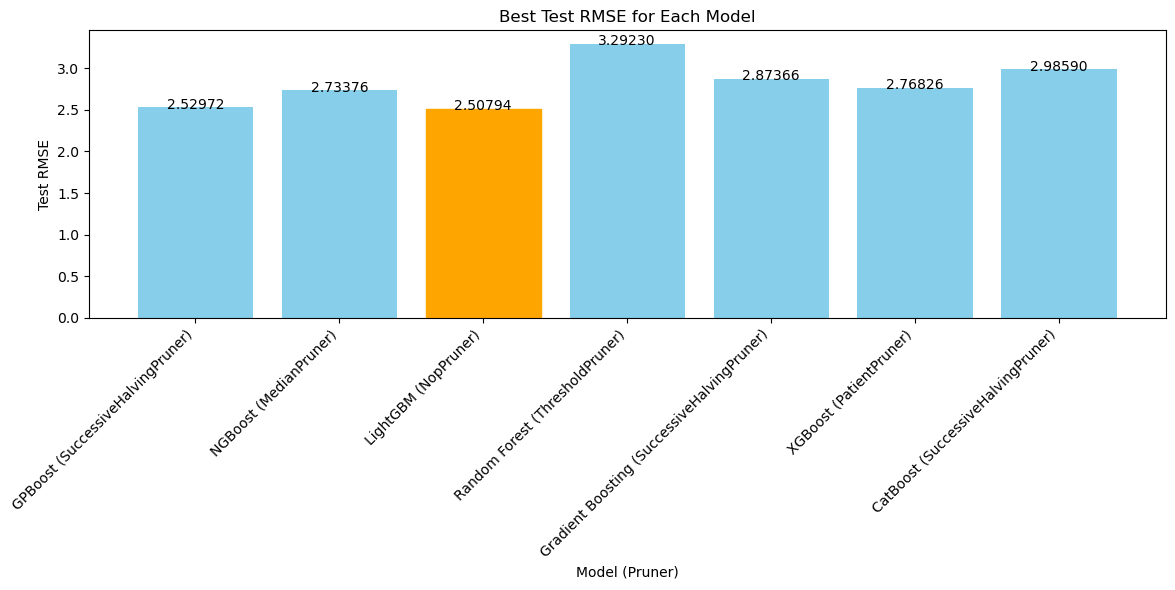

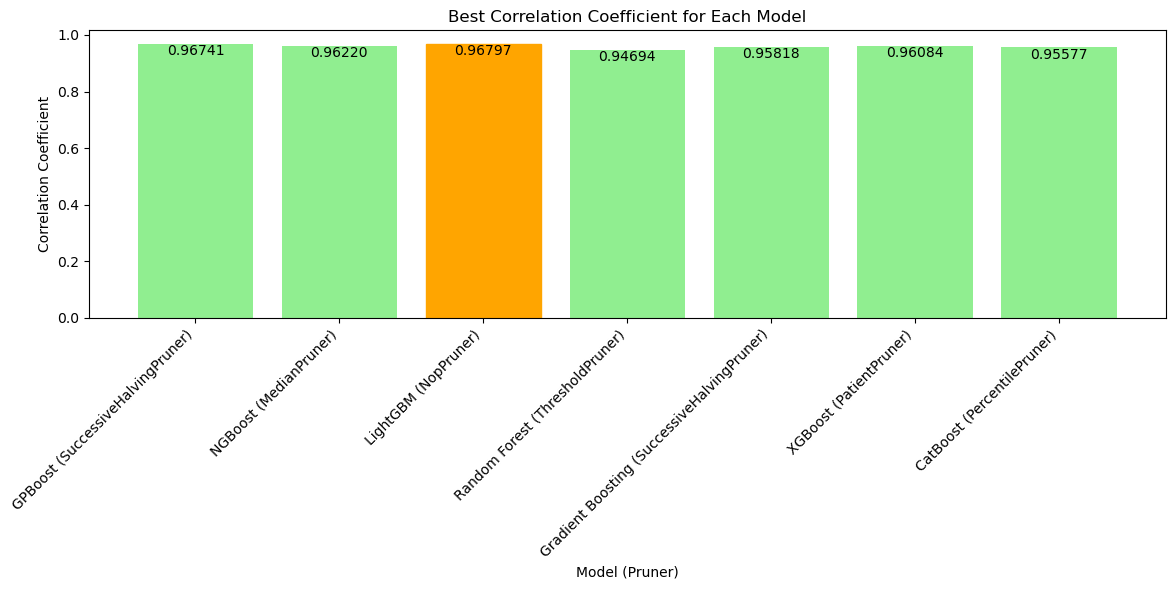

In [14]:
plot_best_scores(best_scores_basesampler)

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

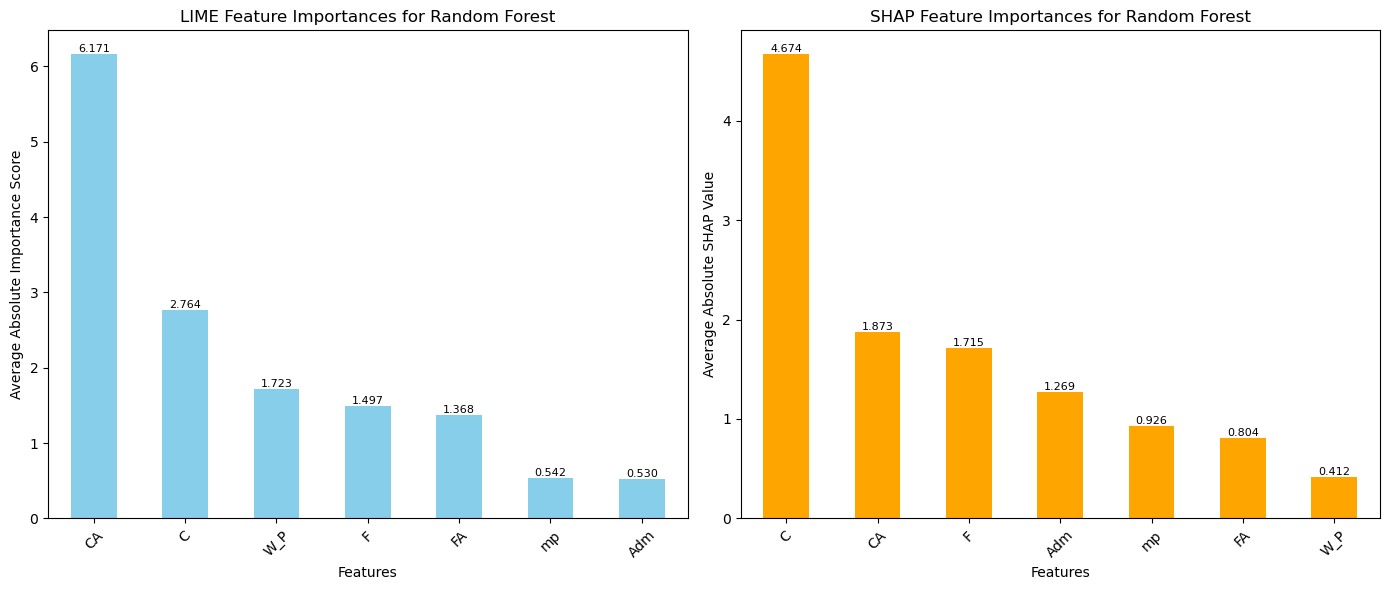

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

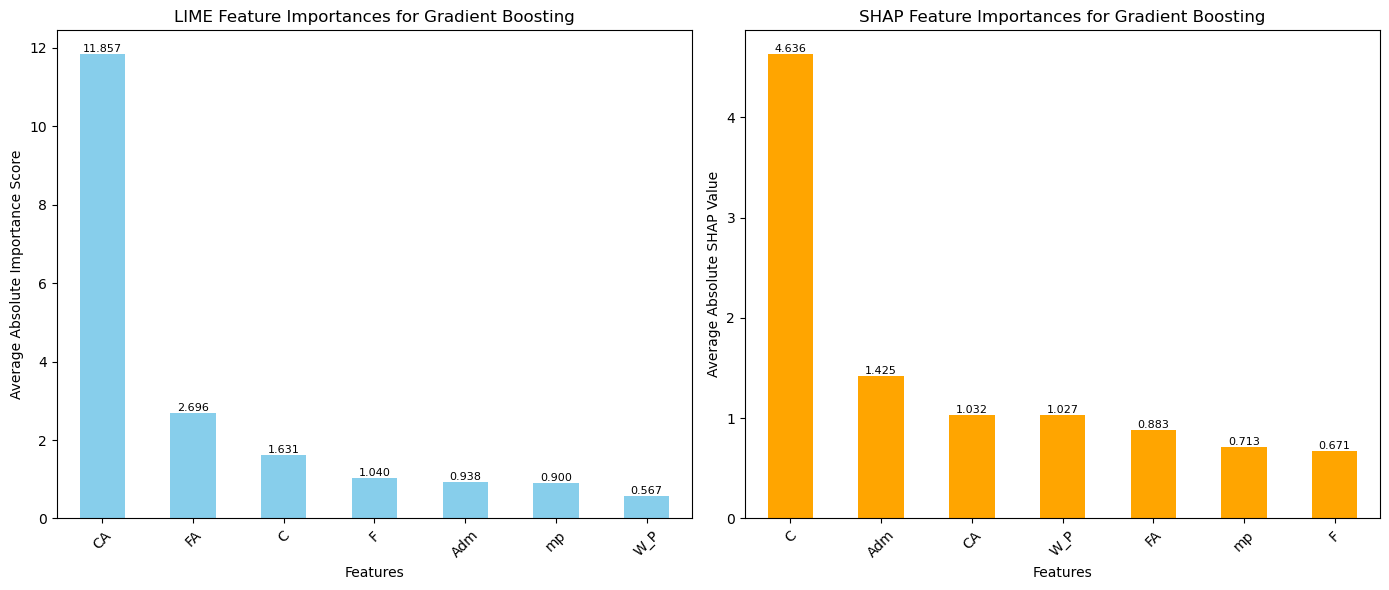

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

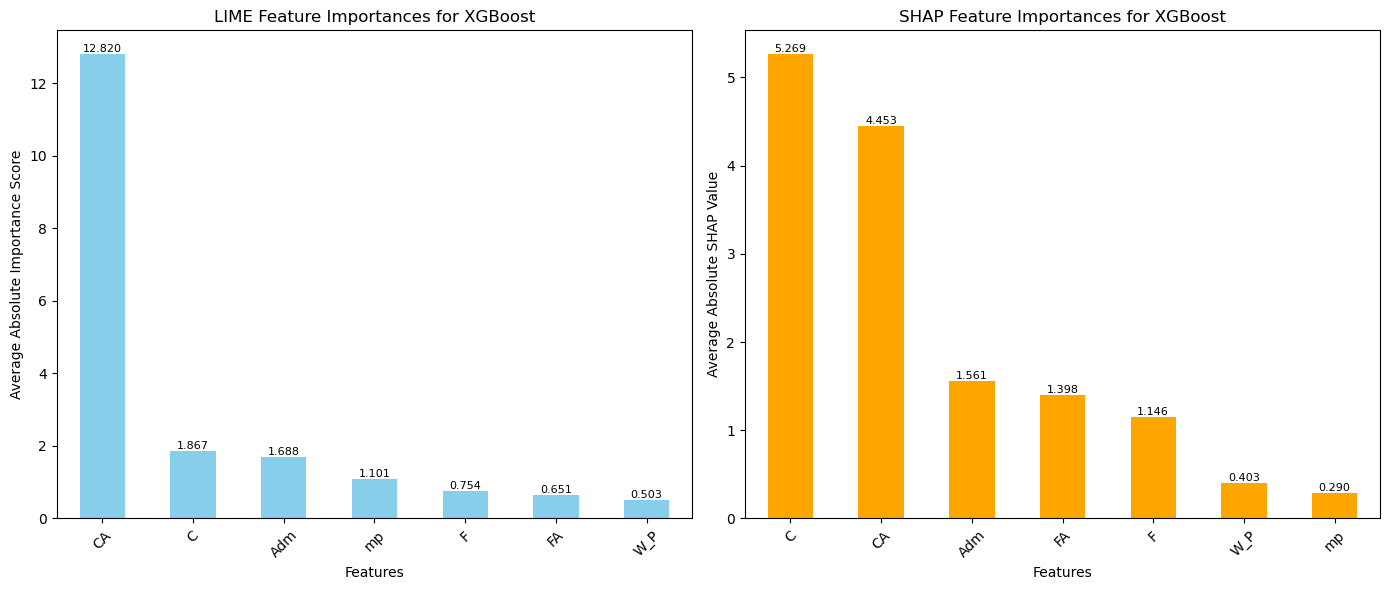

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

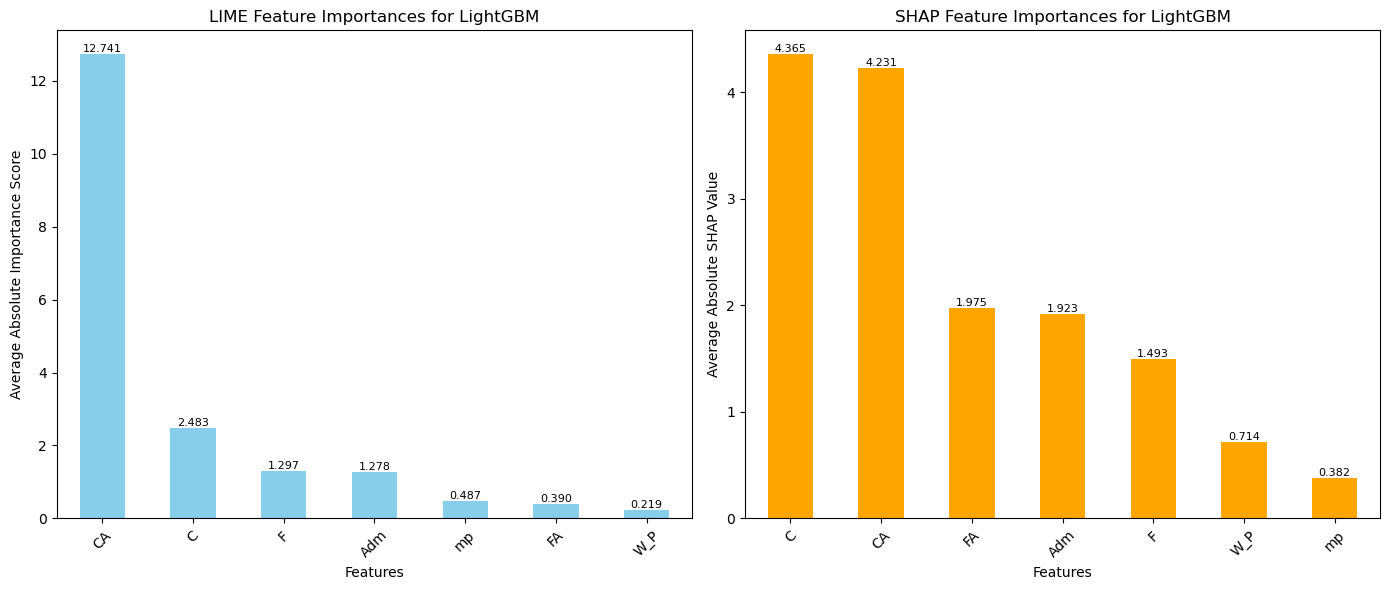

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.1. Current value: lambda_l2=0.1


Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

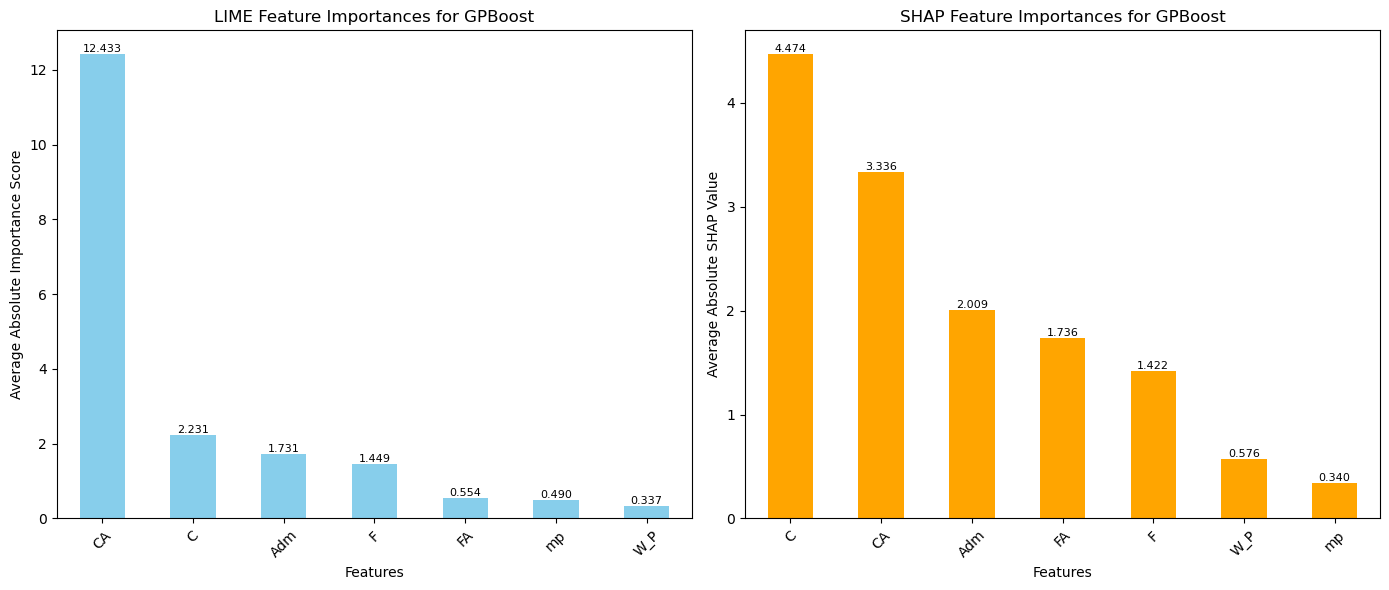

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

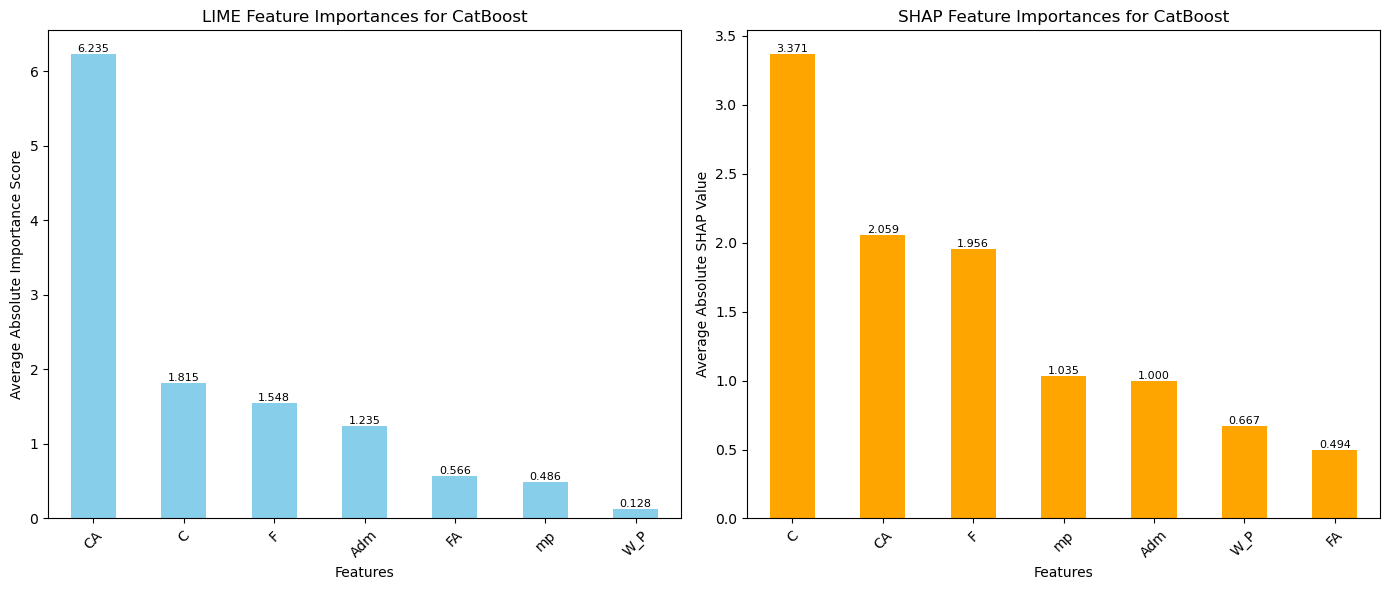

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

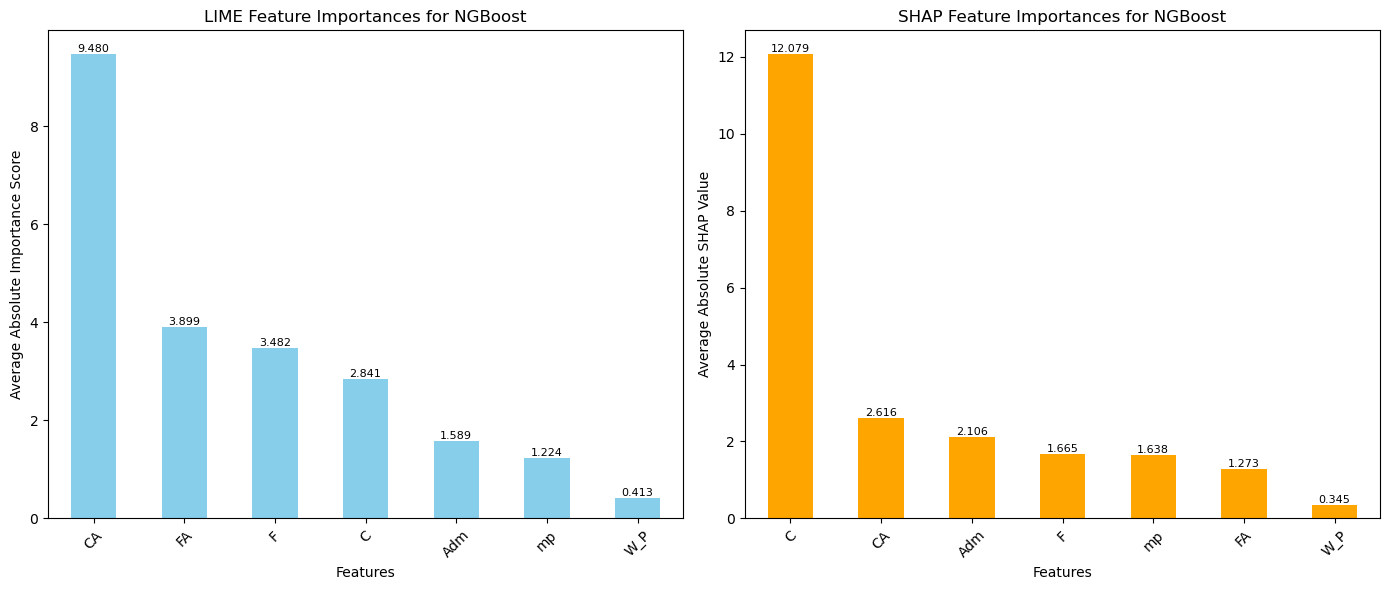

In [15]:
generate_interpretml_explanations_summary_pruners(best_scores_basesampler, X_train, y_train, x_test, feature_names)

# **GridSampler using optuna**

In [16]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def hyperparameter_tuning_grid(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space):
        # Suggest hyperparameters
        params = {key: trial.suggest_categorical(key, values) for key, values in param_space.items()}

        # Create a new instance of the model
        model = model_class()
        model.set_params(**params)

        # Ensure the input arrays are writable
        X_train_copy = np.array(X_train, copy=True)
        y_train_copy = np.array(y_train, copy=True)
        X_test_copy = np.array(X_test, copy=True)
        y_test_copy = np.array(y_test, copy=True)

        # Train model
        model.fit(X_train_copy, y_train_copy)

        # Predict
        y_pred = model.predict(X_test_copy)

        # Calculate MSE
        mse = mean_squared_error(y_test_copy, y_pred)

        return mse

    models = {
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'verbose': [-1]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0],
            'verbose': [-1]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'iterations': [100, 200, 300, 400, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128],
            'verbose': [0]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7],
            'verbose': [0]
        })
    }

    pruners = [
        optuna.pruners.MedianPruner(),
        optuna.pruners.NopPruner(),
        optuna.pruners.PatientPruner(optuna.pruners.MedianPruner(), patience=3),
        optuna.pruners.PercentilePruner(25.0),
        optuna.pruners.SuccessiveHalvingPruner(),
        optuna.pruners.HyperbandPruner(),
        optuna.pruners.ThresholdPruner(lower=0.1),
        optuna.pruners.WilcoxonPruner()
    ]

    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        for pruner in pruners:
            pruner_name = pruner.__class__.__name__
            print(f"Running Optuna for {model_name} with {pruner_name}...")
            try:
                # Use the GridSampler and pruner in the study creation
                sampler = GridSampler(param_space)
                study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
                study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)

                best_params = study.best_params
                best_model = model_class().set_params(**best_params)
                best_model.fit(X_train, y_train)
                y_pred = best_model.predict(X_test)

                # Calculate MSE
                mse = mean_squared_error(y_test, y_pred)

                # Calculate RMSE
                rmse = np.sqrt(mse)

                # Calculate correlation coefficient
                numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
                denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
                corr_coef = numerator / denominator if denominator != 0 else 0.0

                best_scores[(model_name, pruner_name)] = {
                    'best_score': mse,
                    'best_params': best_params,
                    'test_mse': mse,
                    'test_rmse': rmse,
                    'test_corr_coef': corr_coef,
                    'pruner': pruner_name
                }
                print(f"Best MSE for {model_name} with {pruner_name}: {mse} with params: {best_params}")
                print(f"Best RMSE for {model_name} with {pruner_name}: {rmse}")
                print(f"Correlation Coefficient for {model_name} with {pruner_name}: {corr_coef}")
            except Exception as e:
                print(f"Failed to run Optuna for {model_name} with {pruner_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name, best_pruner_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[(best_model_name, best_pruner_name)]
        print(f"\nBest model on test data: {best_model_name} with {best_pruner_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
        print(f"Pruner Used: {best_model_info['pruner']}")
    else:
        print("No valid model configurations found.")

    return best_scores

# Example usage
best_scores_grid_sampler = hyperparameter_tuning_grid(X_train, y_train, X_test, y_test)

Running Optuna for Random Forest with MedianPruner...
Best MSE for Random Forest with MedianPruner: 11.728888291595101 with params: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 2}
Best RMSE for Random Forest with MedianPruner: 3.424746456541725
Correlation Coefficient for Random Forest with MedianPruner: 0.9431025419019259
Running Optuna for Random Forest with NopPruner...
Best MSE for Random Forest with NopPruner: 11.620702952440261 with params: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 2}
Best RMSE for Random Forest with NopPruner: 3.408915216376063
Correlation Coefficient for Random Forest with NopPruner: 0.9421786579529535
Running Optuna for Random Forest with PatientPruner...
Best MSE for Random Forest with PatientPruner: 11.213317364165567 with params: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 2}
Best RMSE

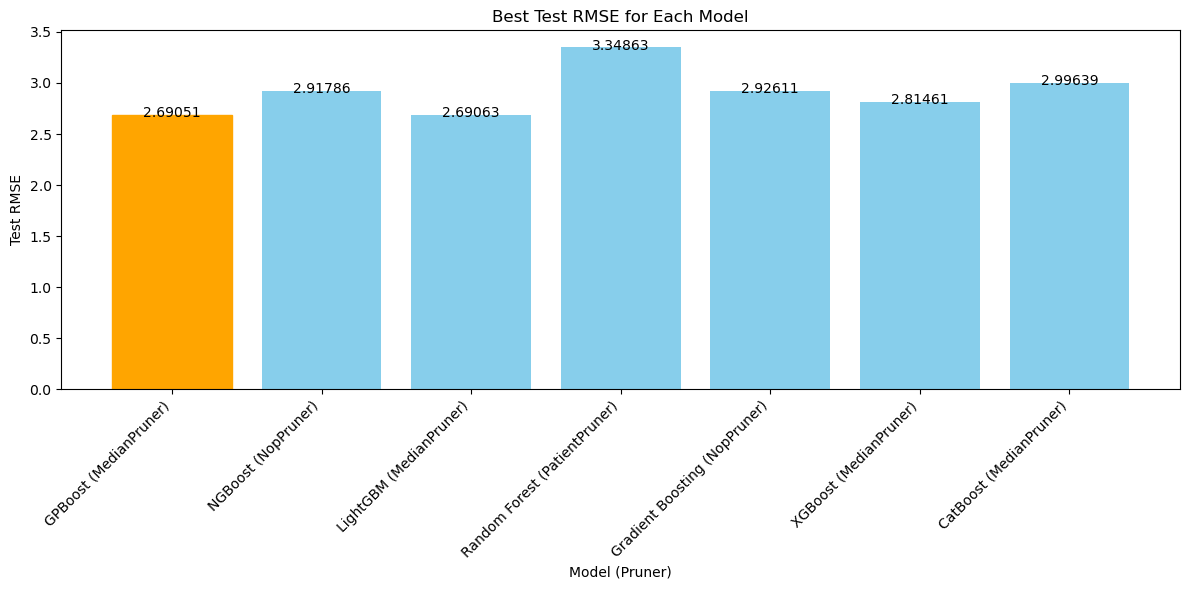

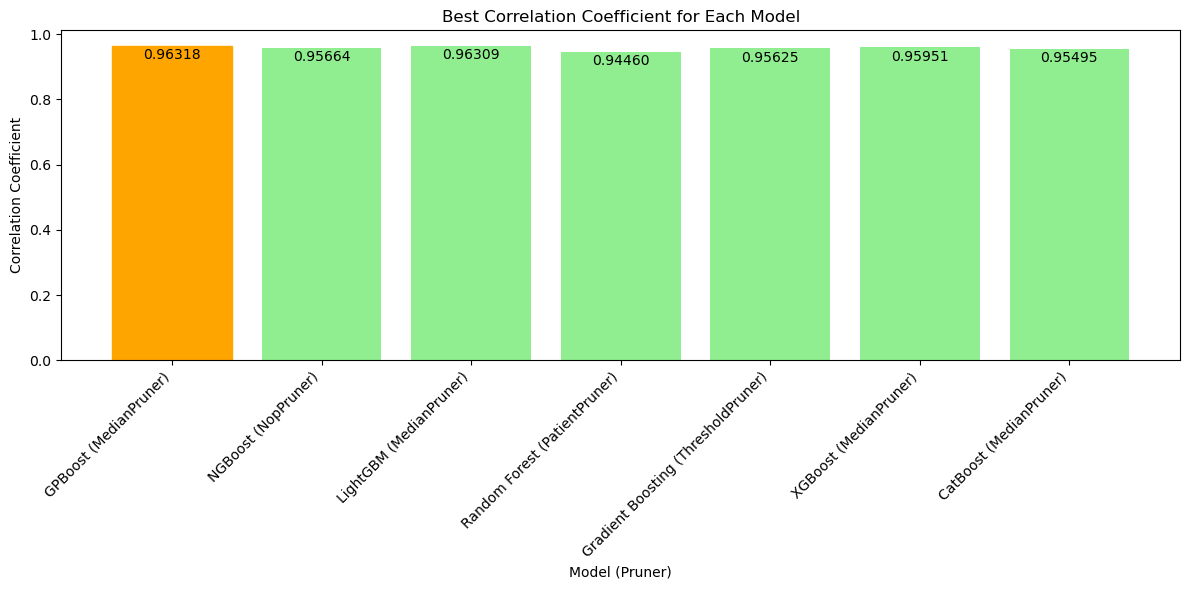

In [17]:
plot_best_scores(best_scores_grid_sampler)

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

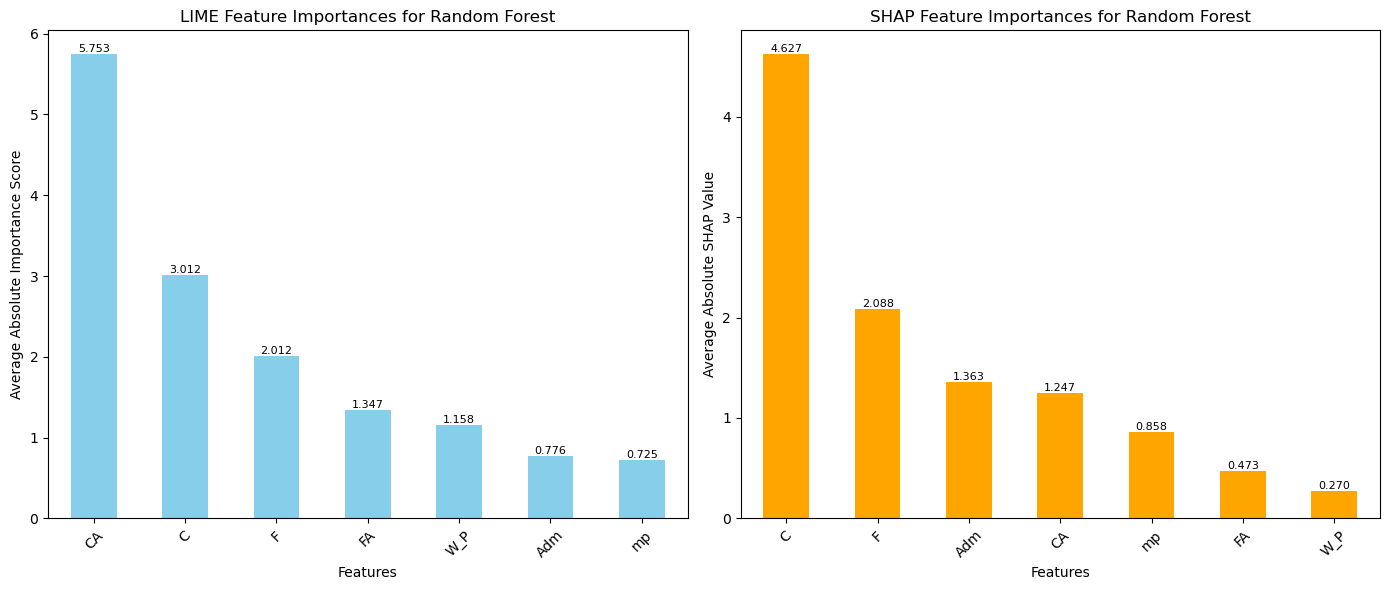

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

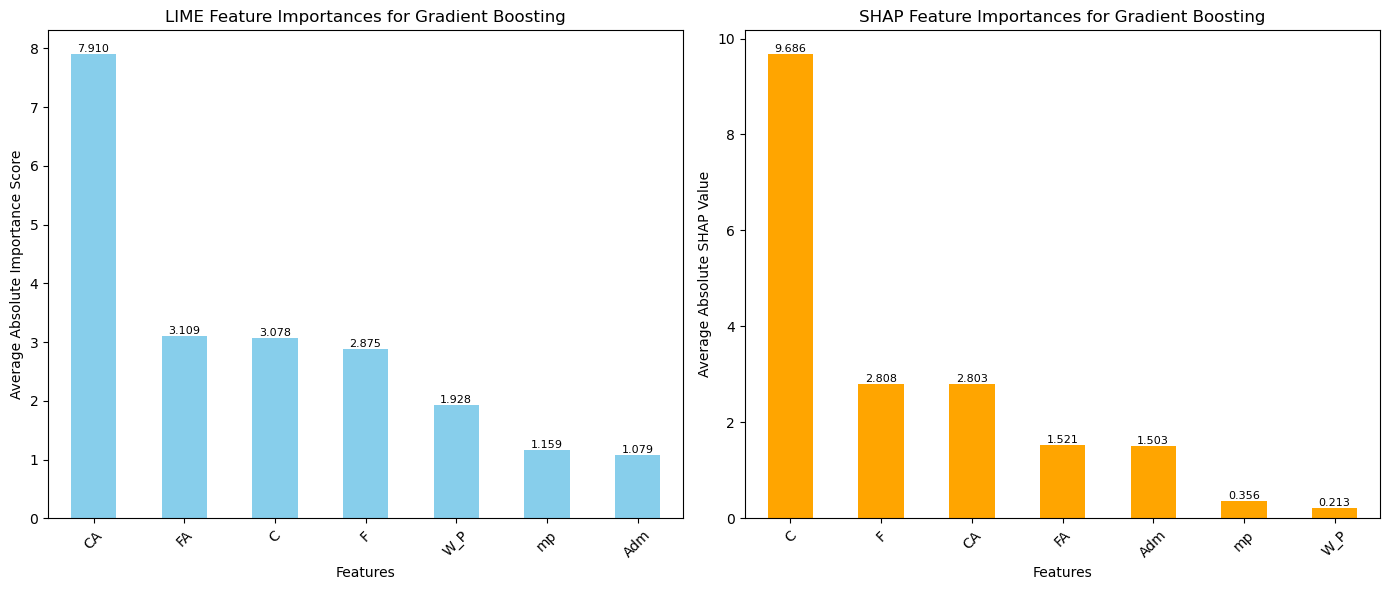

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

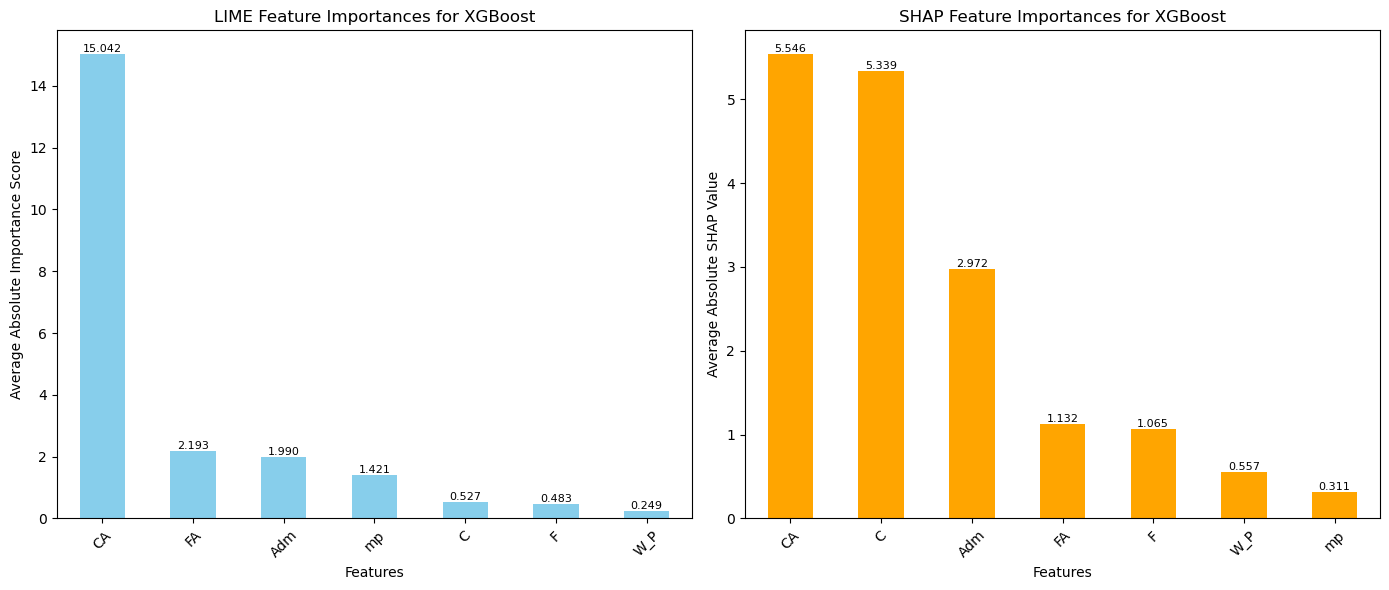

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

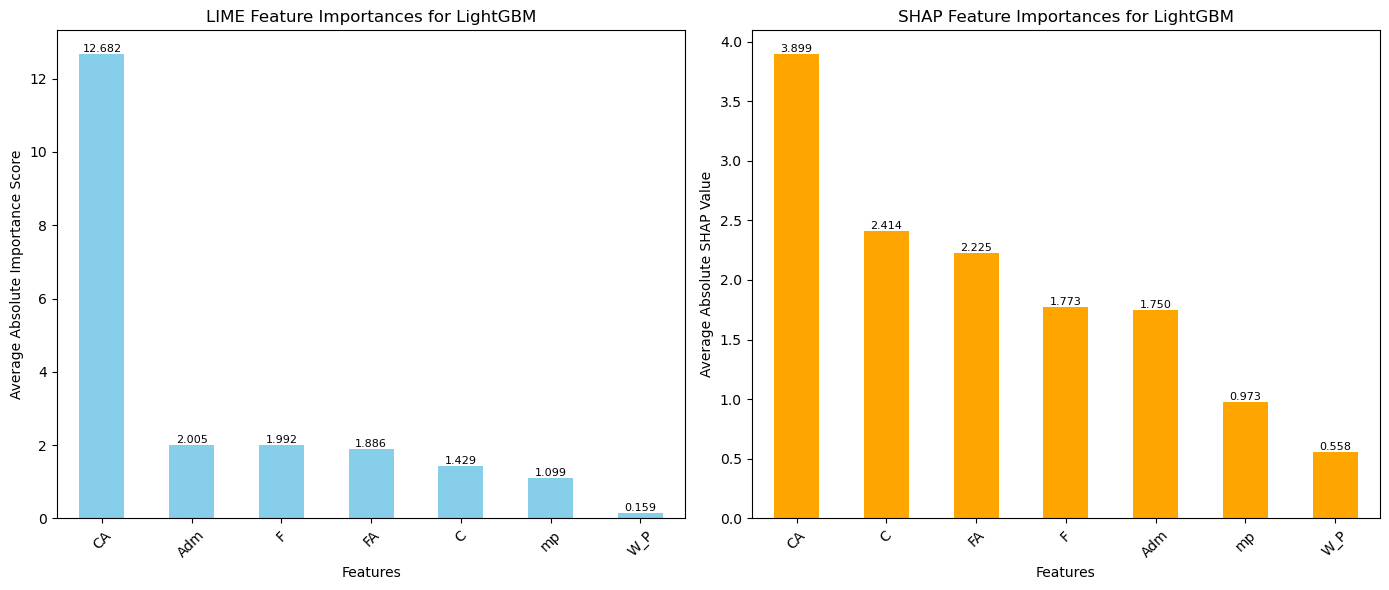

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.1. Current value: lambda_l2=0.1


Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

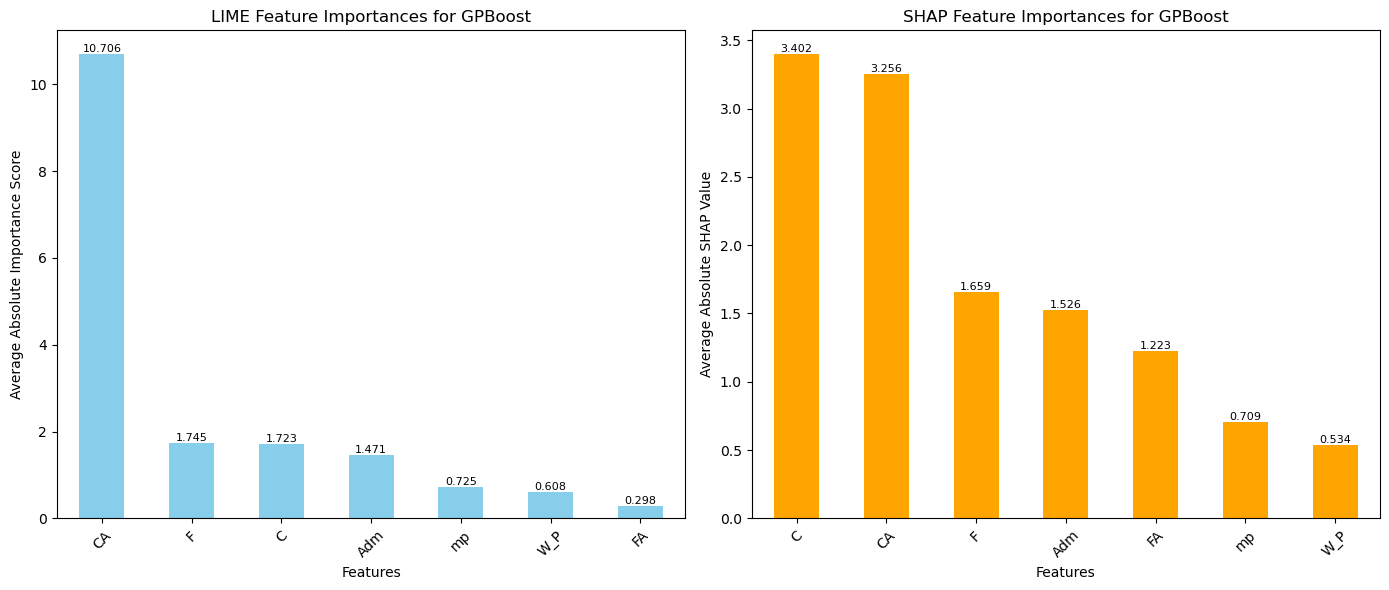

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

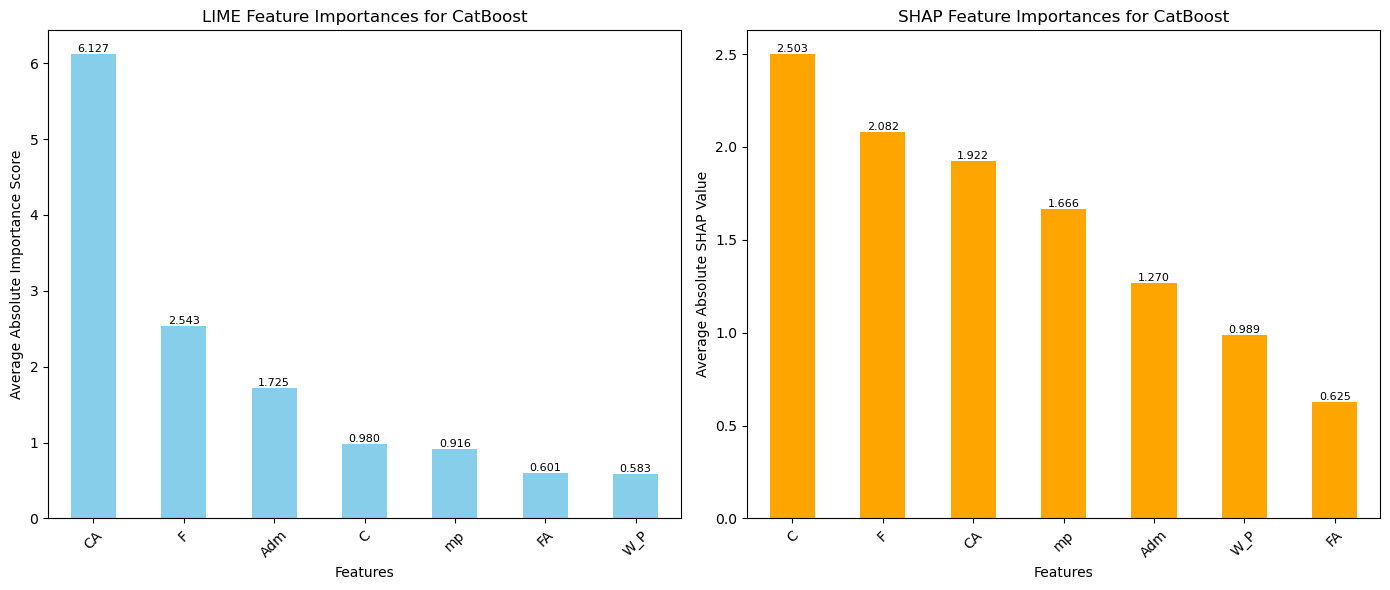

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

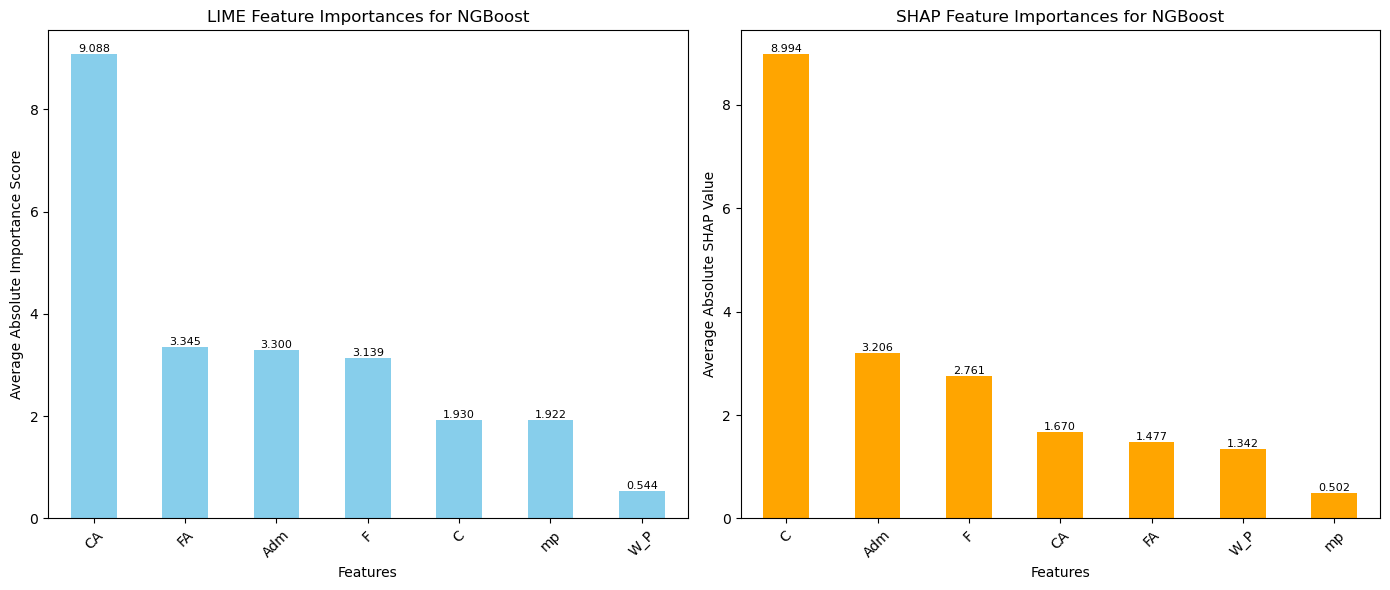

In [18]:
generate_interpretml_explanations_summary_pruners(best_scores_grid_sampler, X_train, y_train, x_test, feature_names)

# **RandomSampler using optuna**

In [19]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def hyperparameter_tuning_ran(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space):
        # Suggest hyperparameters
        params = {key: trial.suggest_categorical(key, values) if isinstance(values, list) else trial.suggest_float(key, *values) for key, values in param_space.items()}

        # Create a new instance of the model
        model = model_class()
        model.set_params(**params)

        # Ensure the input arrays are writable
        X_train_copy = np.array(X_train, copy=True)
        y_train_copy = np.array(y_train, copy=True)
        X_test_copy = np.array(X_test, copy=True)
        y_test_copy = np.array(y_test, copy=True)

        # Train model
        model.fit(X_train_copy, y_train_copy)

        # Predict
        y_pred = model.predict(X_test_copy)

        # Calculate MSE
        mse = mean_squared_error(y_test_copy, y_pred)

        return mse

    models = {
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'verbose': [-1]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0],
            'verbose': [-1]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'iterations': [100, 200, 300, 400, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128],
            'verbose': [0]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7],
            'verbose': [0]
        })
    }
    pruners = [
        optuna.pruners.MedianPruner(),
        optuna.pruners.NopPruner(),
        optuna.pruners.PatientPruner(optuna.pruners.MedianPruner(), patience=3),
        optuna.pruners.PercentilePruner(25.0),
        optuna.pruners.SuccessiveHalvingPruner(),
        optuna.pruners.HyperbandPruner(),
        optuna.pruners.ThresholdPruner(lower=0.1),
        optuna.pruners.WilcoxonPruner()
    ]

    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        for pruner in pruners:
            pruner_name = pruner.__class__.__name__
            print(f"Running Optuna for {model_name} with {pruner_name}...")
            try:
                # Use the RandomSampler and pruner in the study creation
                sampler = RandomSampler()
                study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
                study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)

                best_params = study.best_params
                best_model = model_class().set_params(**best_params)
                best_model.fit(X_train, y_train)
                y_pred = best_model.predict(X_test)

                # Calculate MSE
                mse = mean_squared_error(y_test, y_pred)

                # Calculate RMSE
                rmse = np.sqrt(mse)

                # Calculate correlation coefficient
                numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
                denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
                corr_coef = numerator / denominator if denominator != 0 else 0.0

                best_scores[(model_name, pruner_name)] = {
                    'best_score': mse,
                    'best_params': best_params,
                    'test_mse': mse,
                    'test_rmse': rmse,
                    'test_corr_coef': corr_coef,
                    'pruner': pruner_name
                }
                print(f"Best MSE for {model_name} with {pruner_name}: {mse} with params: {best_params}")
                print(f"Best RMSE for {model_name} with {pruner_name}: {rmse}")
                print(f"Correlation Coefficient for {model_name} with {pruner_name}: {corr_coef}")
            except Exception as e:
                print(f"Failed to run Optuna for {model_name} with {pruner_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name, best_pruner_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[(best_model_name, best_pruner_name)]
        print(f"\nBest model on test data: {best_model_name} with {best_pruner_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
        print(f"Pruner Used: {best_model_info['pruner']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_random_sampler = hyperparameter_tuning_ran(X_train, y_train, X_test, y_test)

Running Optuna for Random Forest with MedianPruner...
Best MSE for Random Forest with MedianPruner: 11.970922873846963 with params: {'n_estimators': 400, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 2}
Best RMSE for Random Forest with MedianPruner: 3.459902148016178
Correlation Coefficient for Random Forest with MedianPruner: 0.9414486063802738
Running Optuna for Random Forest with NopPruner...
Best MSE for Random Forest with NopPruner: 11.227150899239465 with params: {'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 3}
Best RMSE for Random Forest with NopPruner: 3.350694092160528
Correlation Coefficient for Random Forest with NopPruner: 0.9433971711743501
Running Optuna for Random Forest with PatientPruner...
Best MSE for Random Forest with PatientPruner: 11.676189318926705 with params: {'n_estimators': 500, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}
Best RM

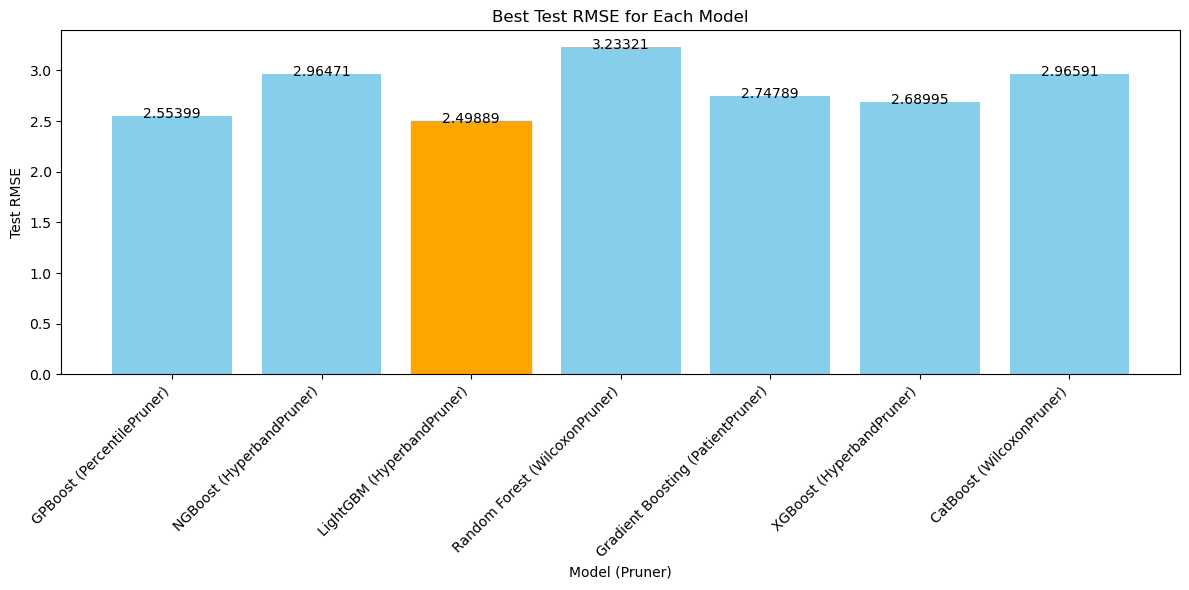

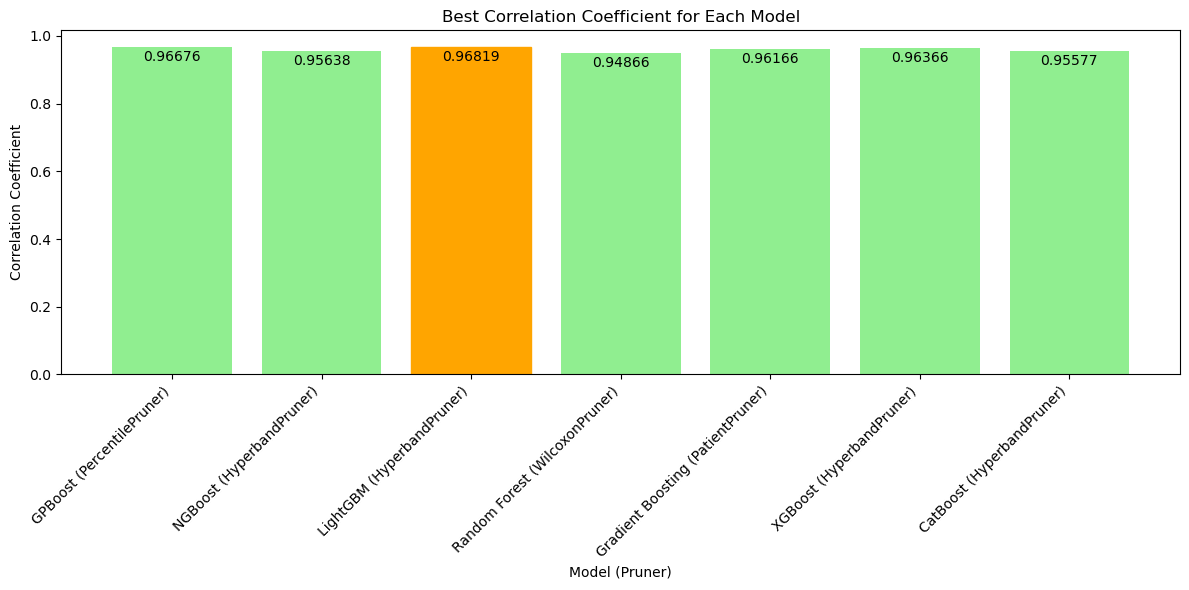

In [20]:
plot_best_scores(best_scores_random_sampler)

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

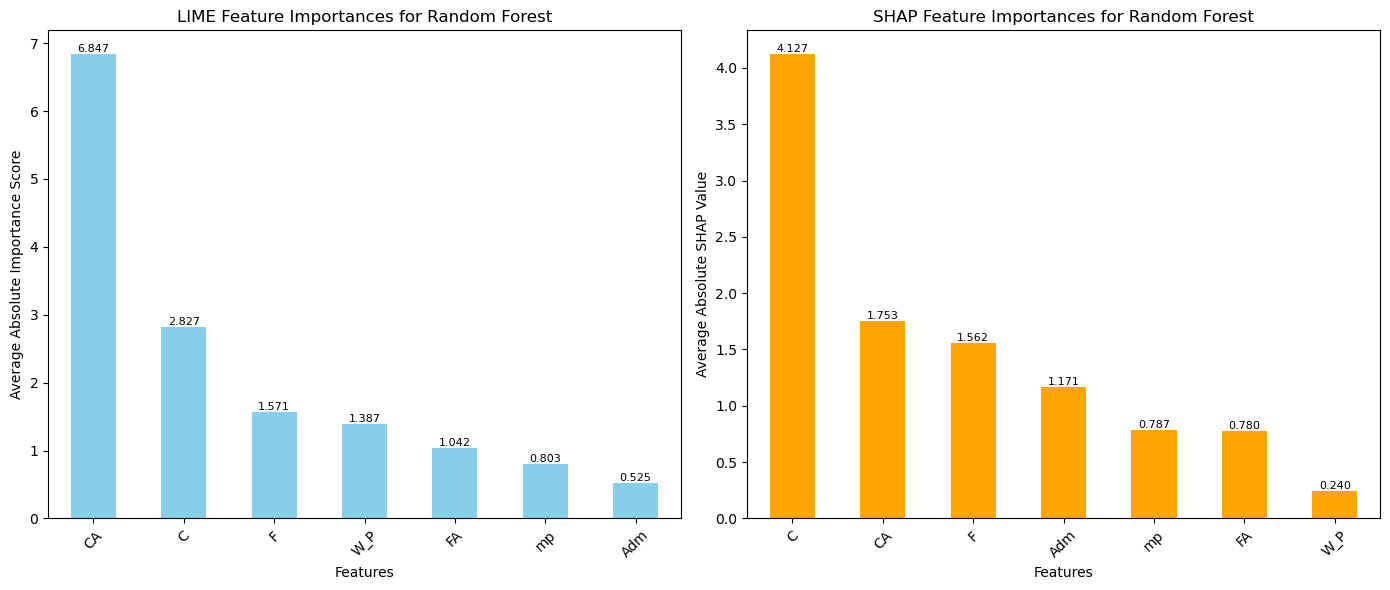

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

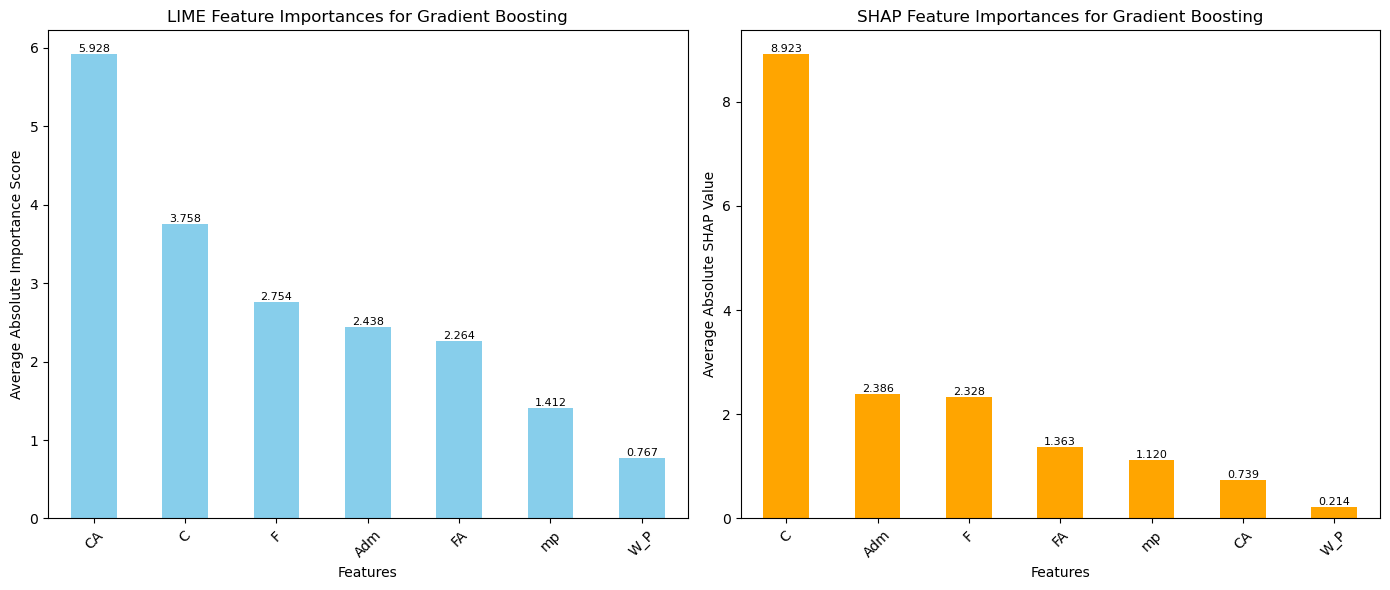

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

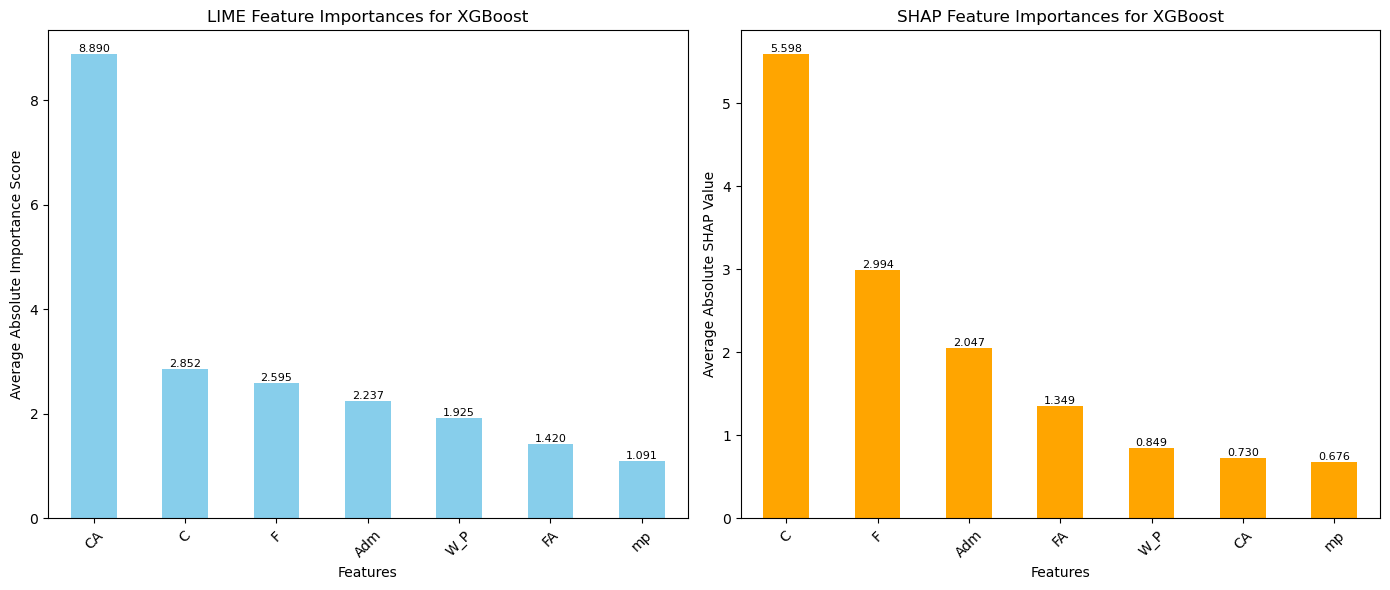

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

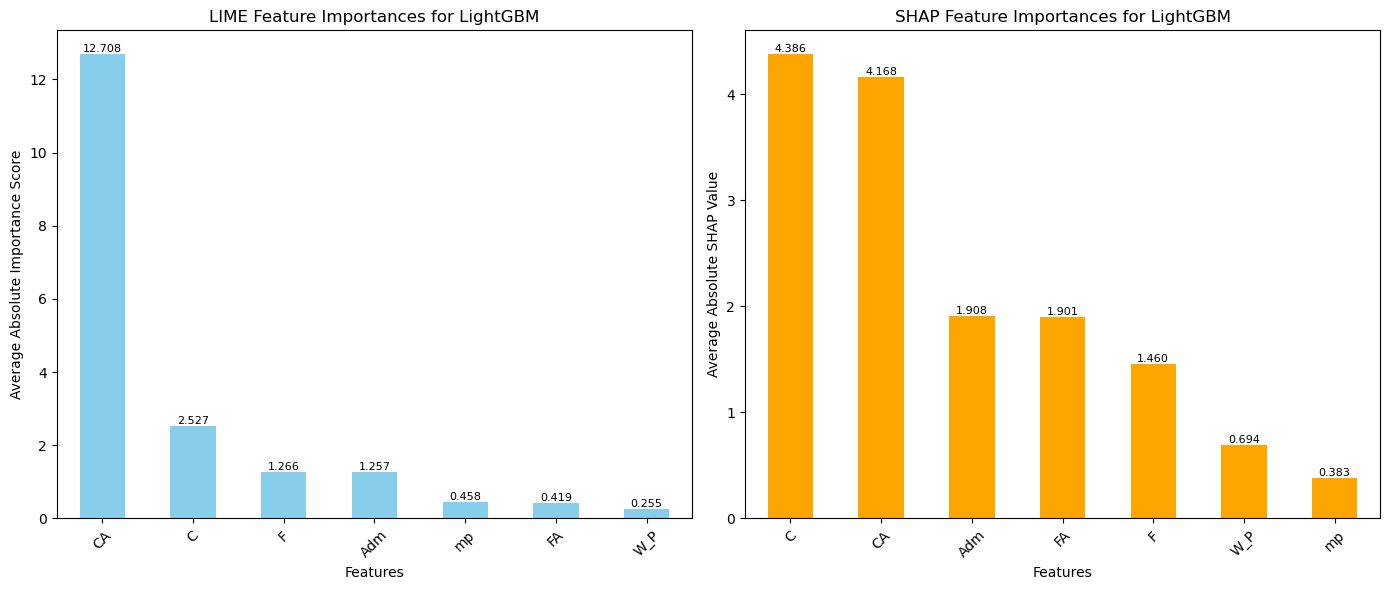

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.5. Current value: lambda_l2=0.5


Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

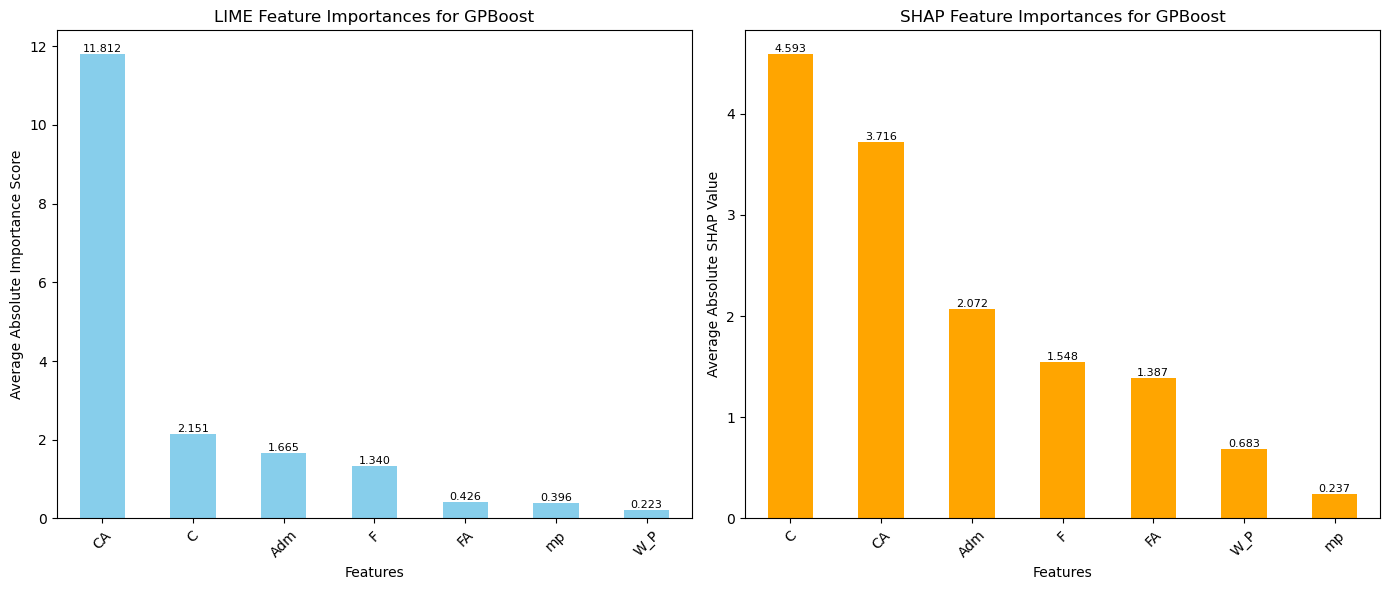

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

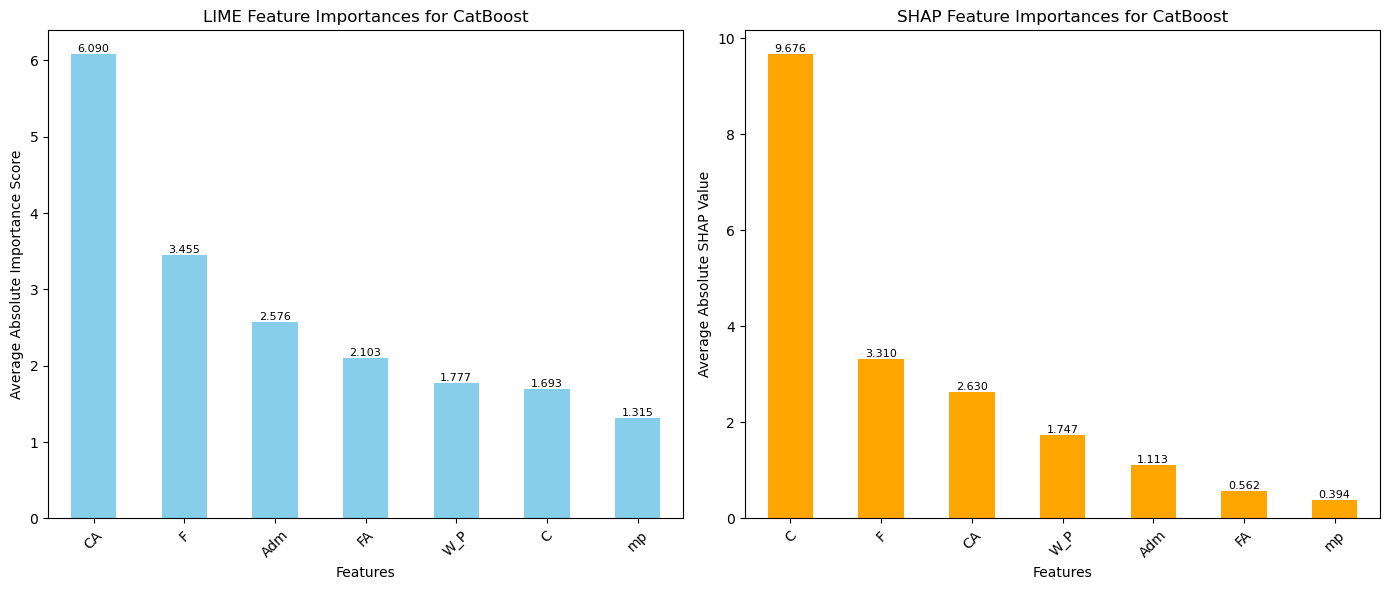

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

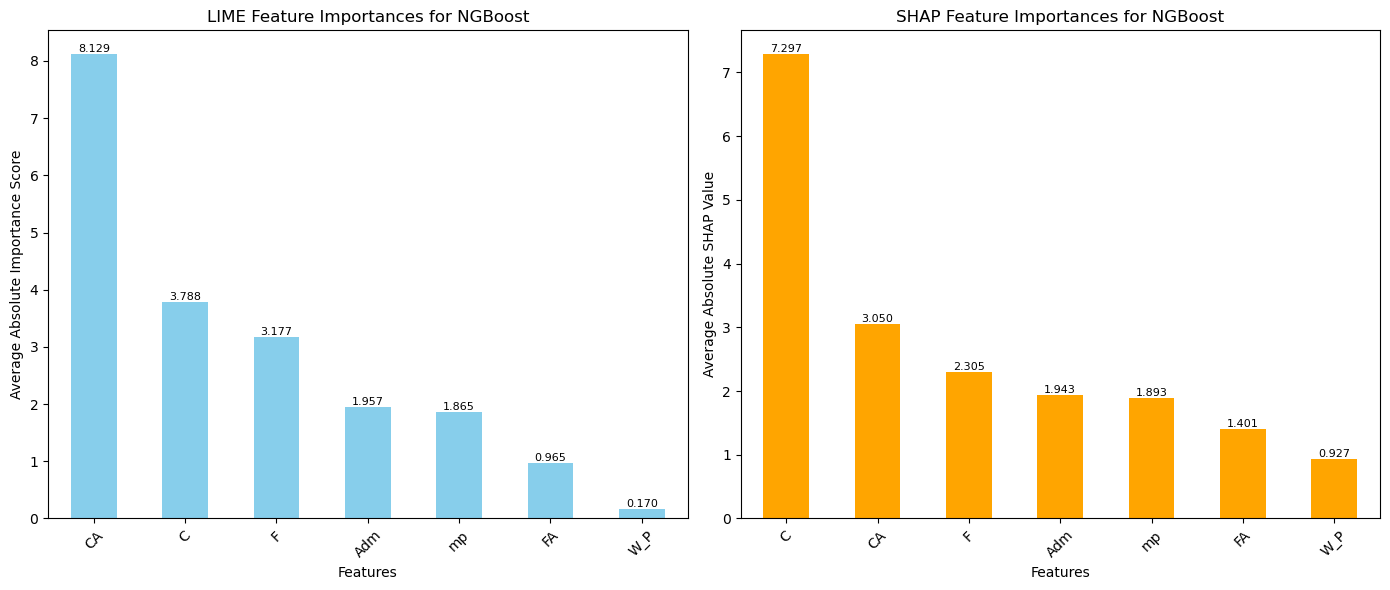

In [21]:
generate_interpretml_explanations_summary_pruners(best_scores_random_sampler, X_train, y_train, x_test, feature_names)

# **TPESampler using optuna**

In [22]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def hyperparameter_tuning_tpe(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space):
        # Suggest hyperparameters
        params = {key: trial.suggest_categorical(key, values) if isinstance(values, list) else trial.suggest_float(key, *values) for key, values in param_space.items()}

        # Create a new instance of the model
        model = model_class()
        model.set_params(**params)

        # Ensure the input arrays are writable
        X_train_copy = np.array(X_train, copy=True)
        y_train_copy = np.array(y_train, copy=True)
        X_test_copy = np.array(X_test, copy=True)
        y_test_copy = np.array(y_test, copy=True)

        # Train model
        model.fit(X_train_copy, y_train_copy)

        # Predict
        y_pred = model.predict(X_test_copy)

        # Calculate MSE
        mse = mean_squared_error(y_test_copy, y_pred)

        return mse

    models = {
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'verbose': [-1]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0],
            'verbose': [-1]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'iterations': [100, 200, 300, 400, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128],
            'verbose': [0]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7],
            'verbose': [0]
        })
    }

    pruners = [
        optuna.pruners.MedianPruner(),
        optuna.pruners.NopPruner(),
        optuna.pruners.PatientPruner(optuna.pruners.MedianPruner(), patience=3),
        optuna.pruners.PercentilePruner(25.0),
        optuna.pruners.SuccessiveHalvingPruner(),
        optuna.pruners.HyperbandPruner(),
        optuna.pruners.ThresholdPruner(lower=0.1),
        optuna.pruners.WilcoxonPruner()
    ]

    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        for pruner in pruners:
            pruner_name = pruner.__class__.__name__
            print(f"Running Optuna for {model_name} with {pruner_name}...")
            try:
                # Use the TPESampler and pruner in the study creation
                sampler = TPESampler()
                study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
                study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)

                best_params = study.best_params
                best_model = model_class().set_params(**best_params)
                best_model.fit(X_train, y_train)
                y_pred = best_model.predict(X_test)

                # Calculate MSE
                mse = mean_squared_error(y_test, y_pred)

                # Calculate RMSE
                rmse = np.sqrt(mse)

                # Calculate correlation coefficient
                numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
                denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
                corr_coef = numerator / denominator if denominator != 0 else 0.0

                best_scores[(model_name, pruner_name)] = {
                    'best_score': mse,
                    'best_params': best_params,
                    'test_mse': mse,
                    'test_rmse': rmse,
                    'test_corr_coef': corr_coef,
                    'pruner': pruner_name
                }
                print(f"Best MSE for {model_name} with {pruner_name}: {mse} with params: {best_params}")
                print(f"Best RMSE for {model_name} with {pruner_name}: {rmse}")
                print(f"Correlation Coefficient for {model_name} with {pruner_name}: {corr_coef}")
            except Exception as e:
                print(f"Failed to run Optuna for {model_name} with {pruner_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name, best_pruner_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[(best_model_name, best_pruner_name)]
        print(f"\nBest model on test data: {best_model_name} with {best_pruner_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
        print(f"Pruner Used: {best_model_info['pruner']}")
    else:
        print("No valid model configurations found.")

    return best_scores


best_scores_tpe_sampler = hyperparameter_tuning_tpe(X_train, y_train, X_test, y_test)

Running Optuna for Random Forest with MedianPruner...
Best MSE for Random Forest with MedianPruner: 10.234477969320523 with params: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 3}
Best RMSE for Random Forest with MedianPruner: 3.1991370663540697
Correlation Coefficient for Random Forest with MedianPruner: 0.9489590166089555
Running Optuna for Random Forest with NopPruner...
Best MSE for Random Forest with NopPruner: 12.123503555019997 with params: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 3}
Best RMSE for Random Forest with NopPruner: 3.481882185689228
Correlation Coefficient for Random Forest with NopPruner: 0.9402213033771454
Running Optuna for Random Forest with PatientPruner...
Best MSE for Random Forest with PatientPruner: 11.884723501756117 with params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}
Best R

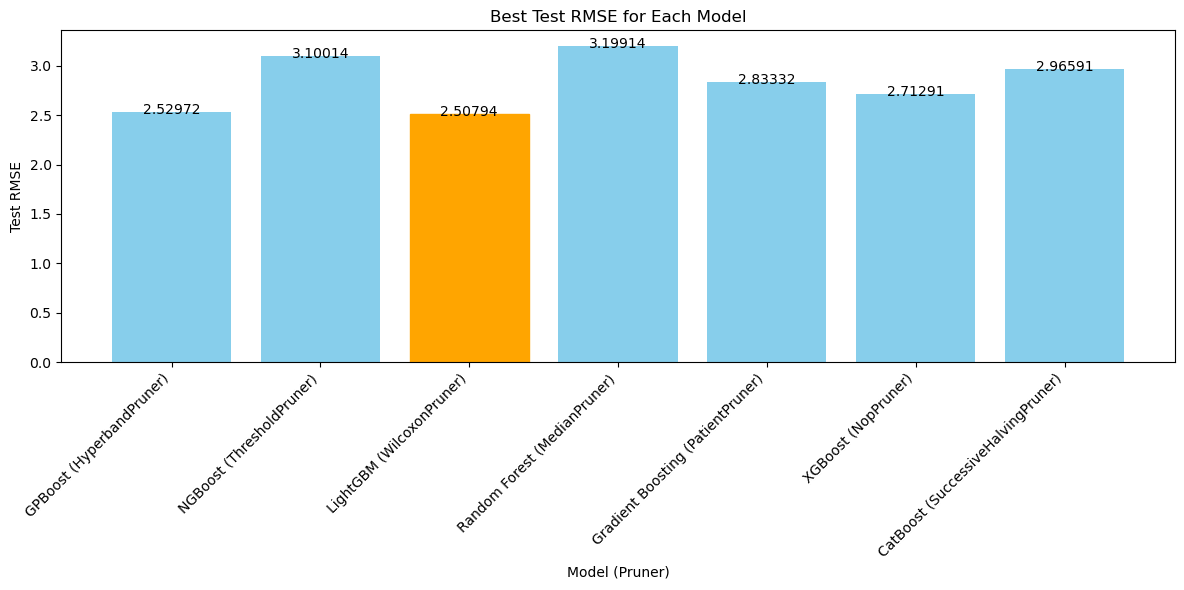

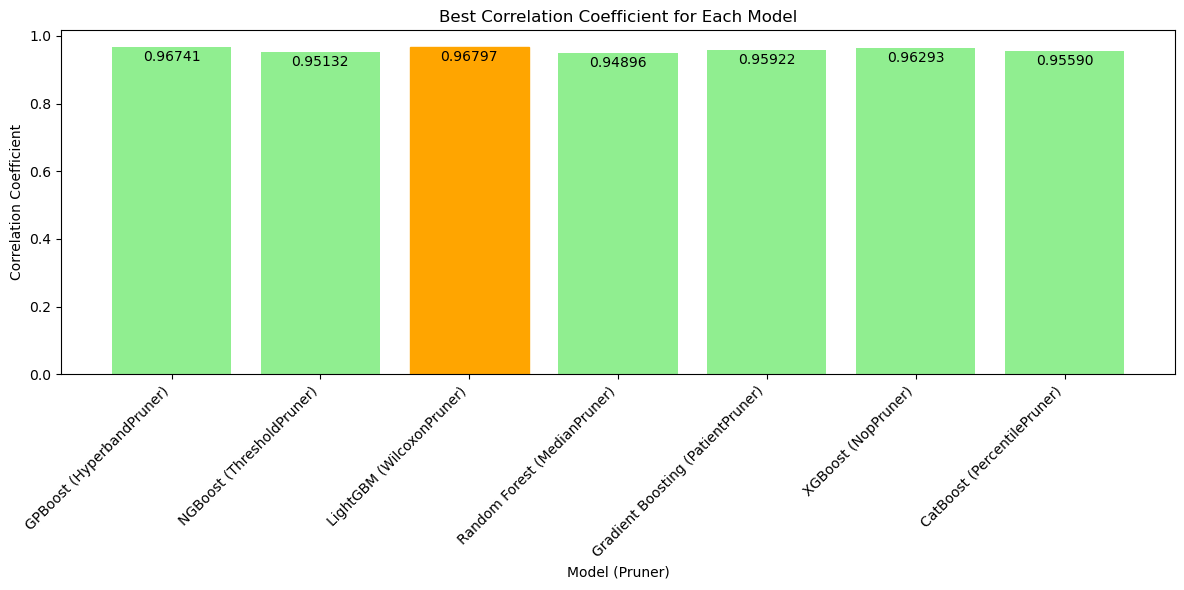

In [23]:
plot_best_scores(best_scores_tpe_sampler)

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

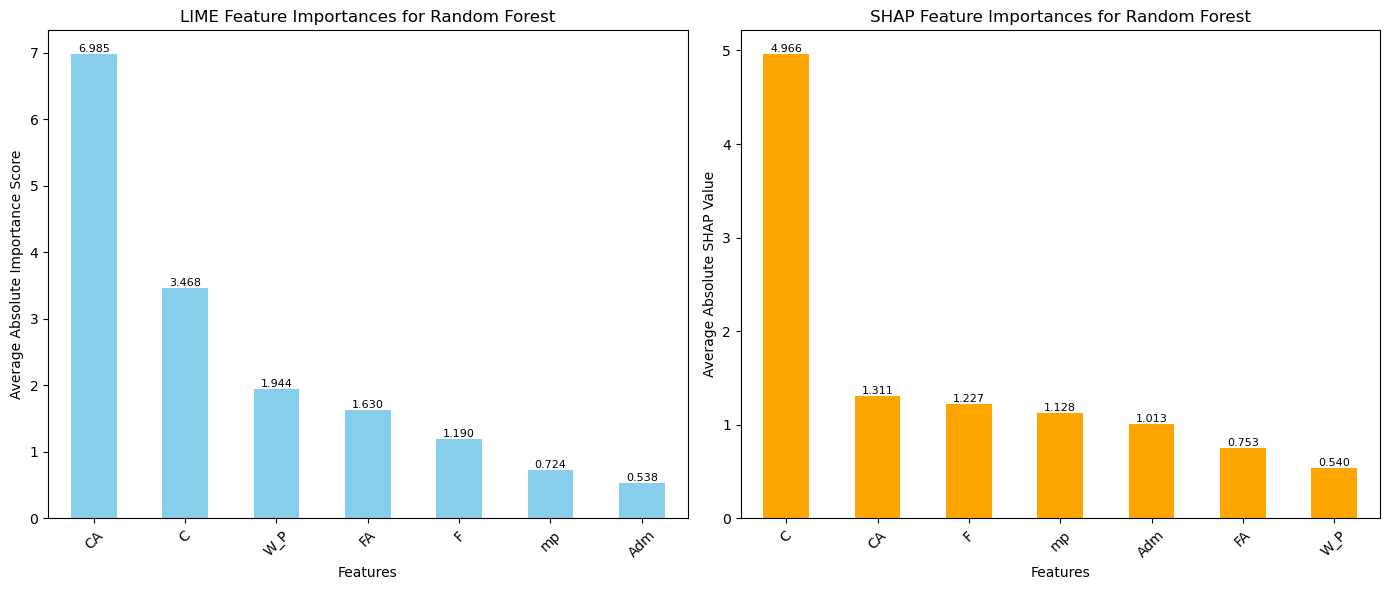

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

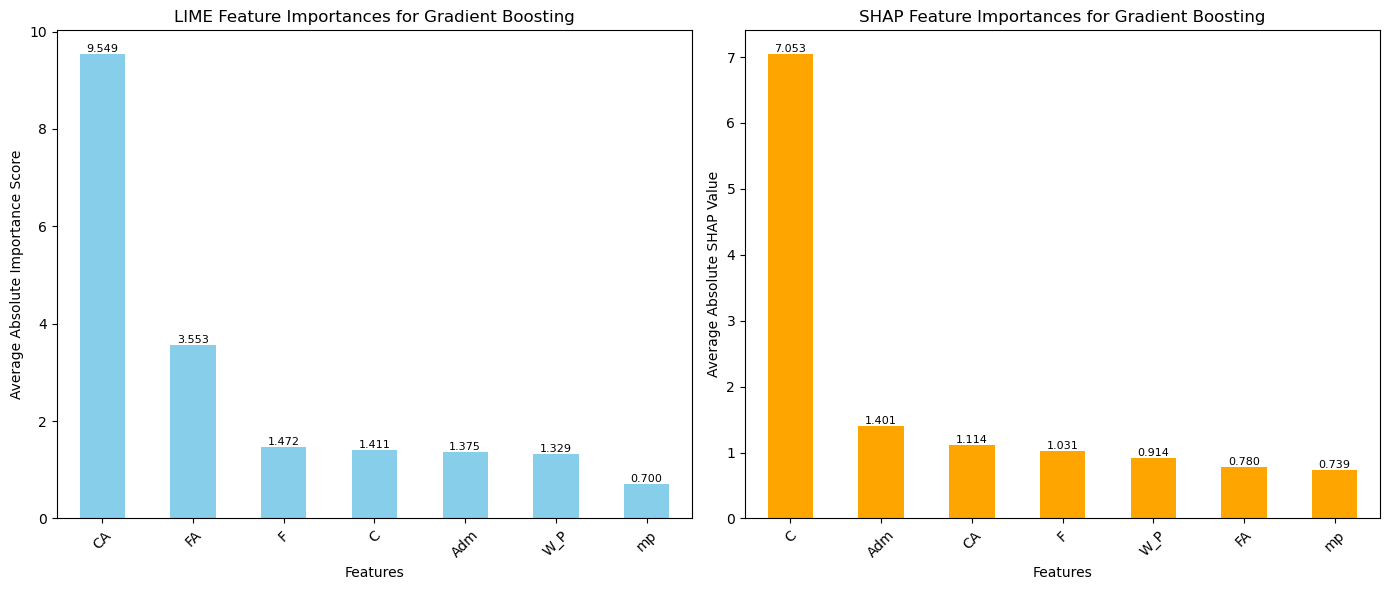

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

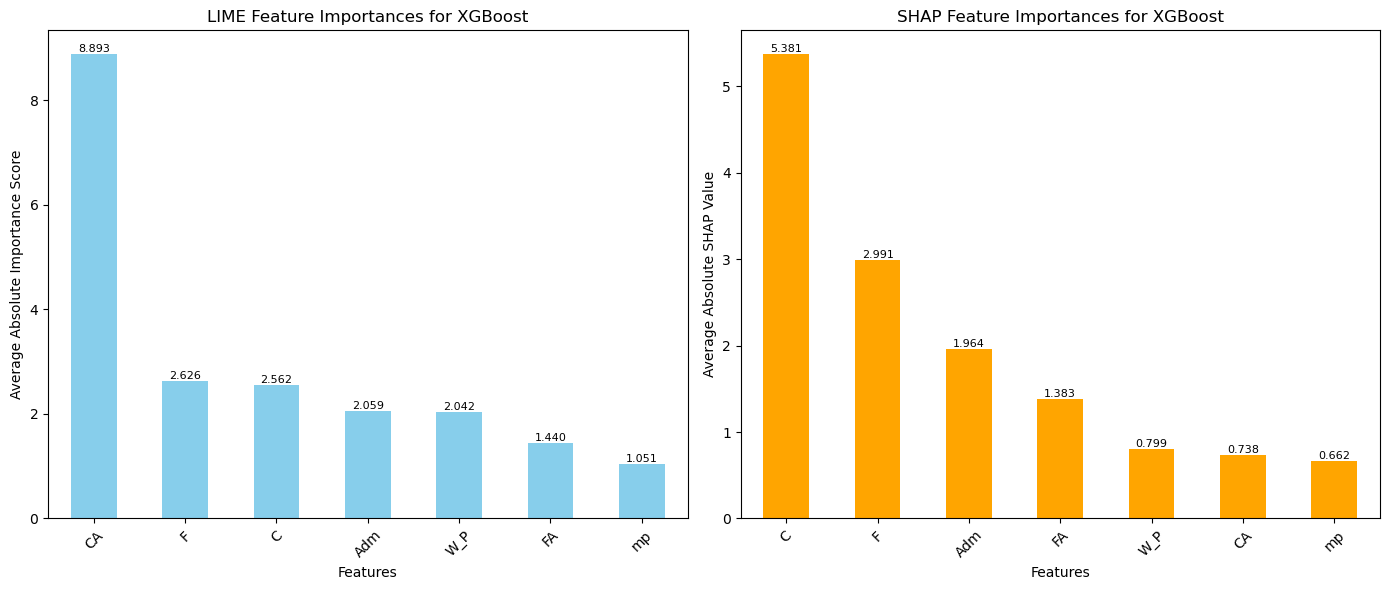

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

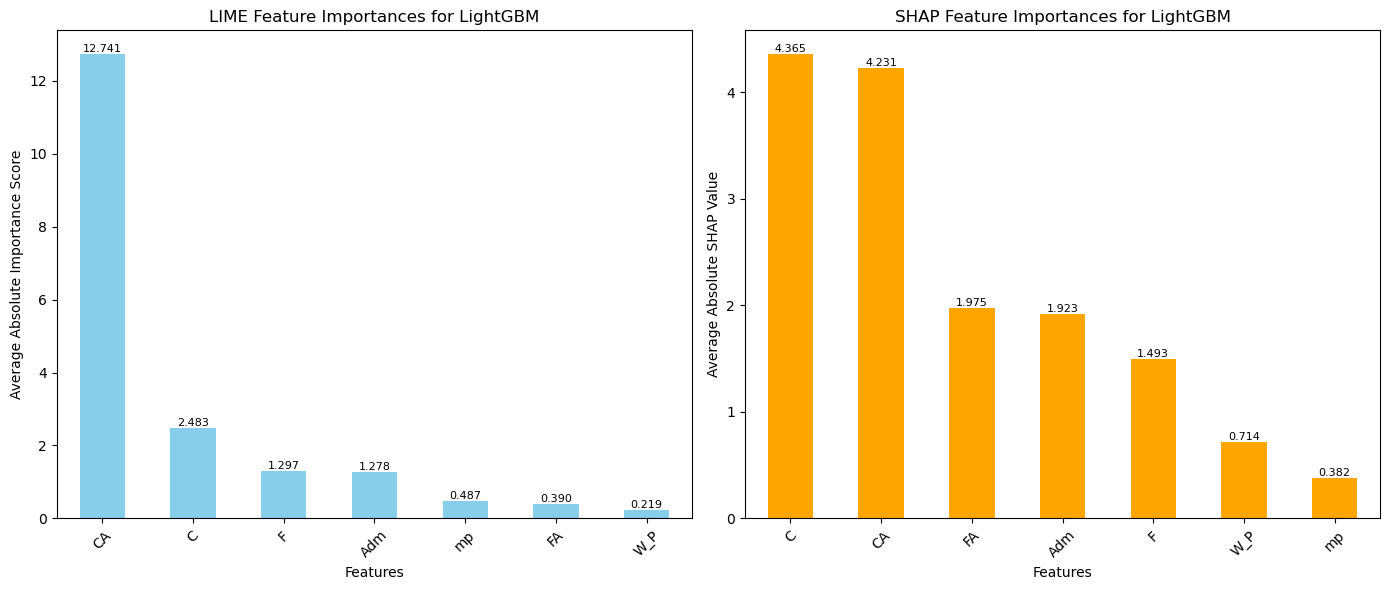

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.1. Current value: lambda_l2=0.1


Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

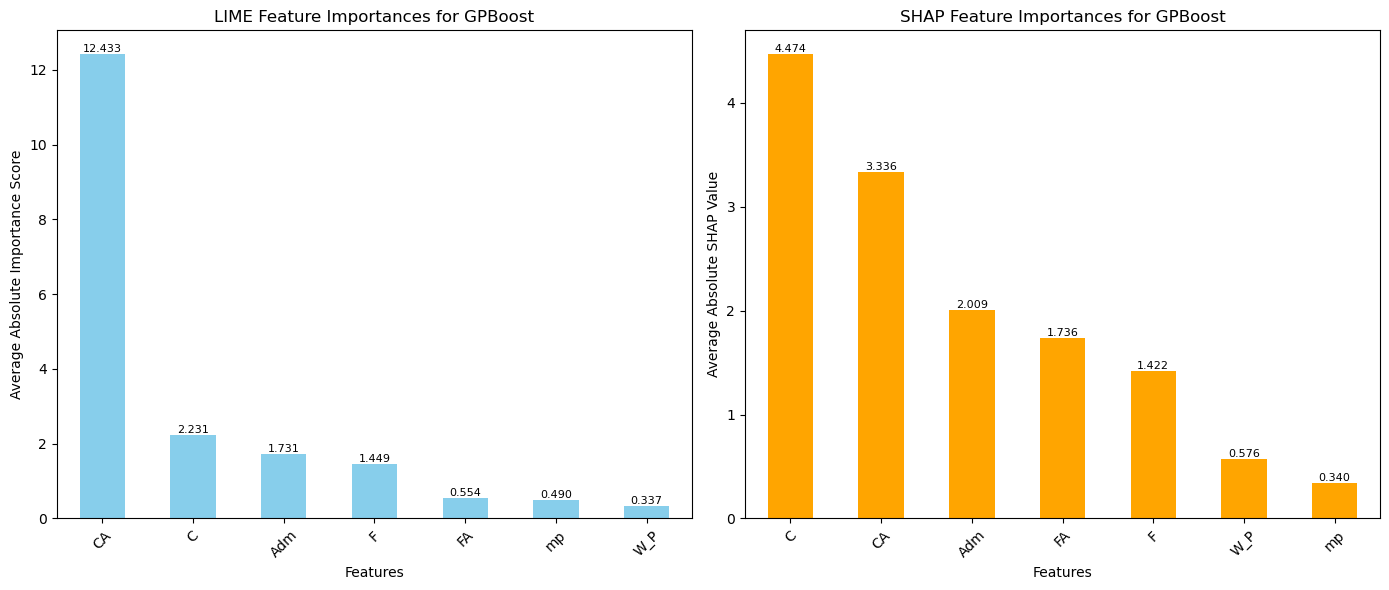

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

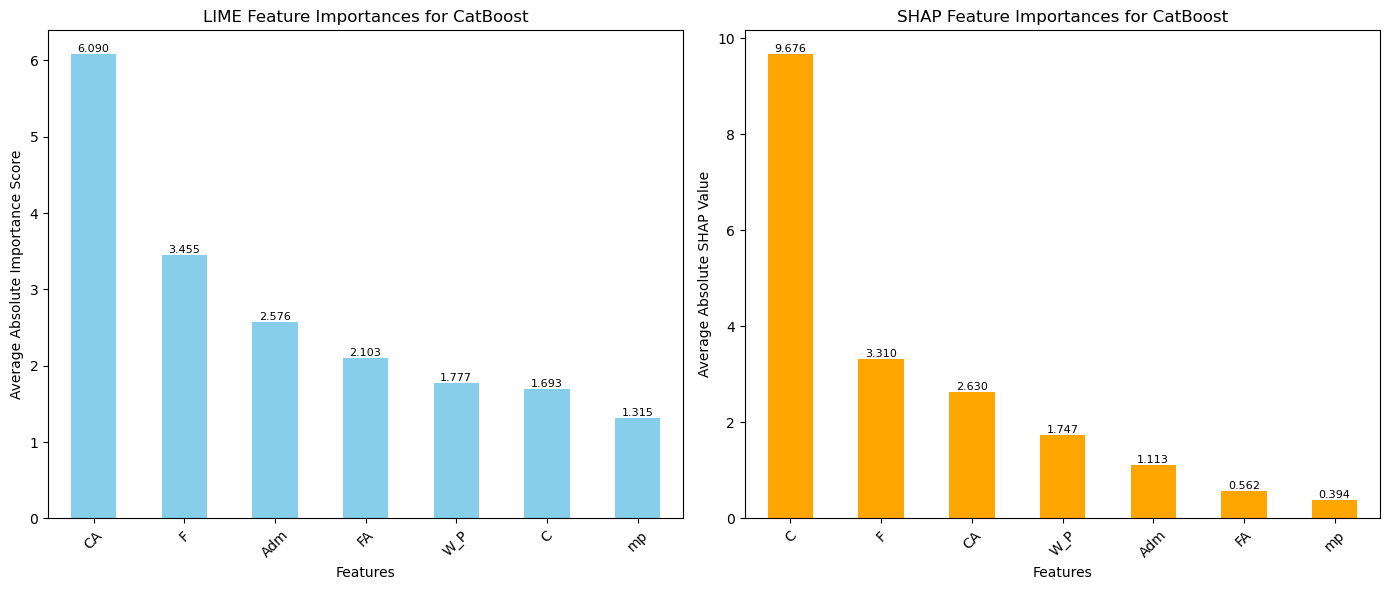

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

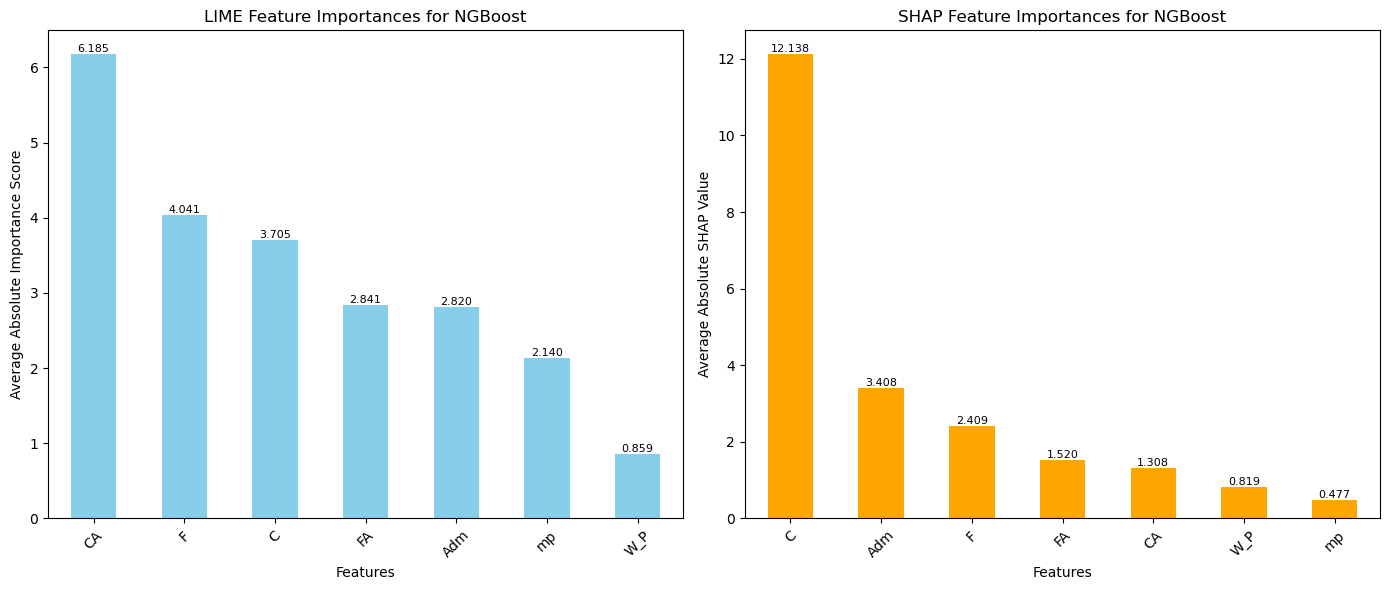

In [24]:
generate_interpretml_explanations_summary_pruners(best_scores_tpe_sampler, X_train, y_train, x_test, feature_names)

# **CmaEsSampler using optuna**

In [25]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def hyperparameter_tuning_cmaes(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space):
        # Suggest hyperparameters
        params = {}
        for key, values in param_space.items():
            if isinstance(values, list):
                params[key] = trial.suggest_categorical(key, values)
            elif isinstance(values, tuple) and all(isinstance(v, int) for v in values):
                params[key] = trial.suggest_int(key, *values)
            else:
                params[key] = trial.suggest_float(key, *values)

        # Create and train the model
        model = model_class().set_params(**params)
        model.fit(X_train, y_train)

        # Predict and calculate MSE
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        return mse

    models = {
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'verbose': [-1]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0],
            'verbose': [-1]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'iterations': [100, 200, 300, 400, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128],
            'verbose': [0]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7],
            'verbose': [0]
        })
    }

    pruners = [
        optuna.pruners.MedianPruner(),
        optuna.pruners.NopPruner(),
        optuna.pruners.PatientPruner(optuna.pruners.MedianPruner(), patience=3),
        optuna.pruners.PercentilePruner(25.0),
        optuna.pruners.SuccessiveHalvingPruner(),
        optuna.pruners.HyperbandPruner(),
        optuna.pruners.ThresholdPruner(lower=0.1),
        optuna.pruners.WilcoxonPruner()
    ]

    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        for pruner in pruners:
            pruner_name = pruner.__class__.__name__
            print(f"Running Optuna for {model_name} with {pruner_name}...")
            try:
                # Set warn_independent_sampling to False to suppress warnings
                sampler = CmaEsSampler(warn_independent_sampling=False)
                study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
                study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)

                best_params = study.best_params
                best_model = model_class().set_params(**best_params)
                best_model.fit(X_train, y_train)
                y_pred = best_model.predict(X_test)

                mse = mean_squared_error(y_test, y_pred)
                rmse = np.sqrt(mse)
                corr_coef = np.corrcoef(y_test, y_pred)[0, 1]

                best_scores[(model_name, pruner_name)] = {
                    'best_score': mse,
                    'best_params': best_params,
                    'test_mse': mse,
                    'test_rmse': rmse,
                    'test_corr_coef': corr_coef,
                    'pruner': pruner_name
                }
                print(f"Best MSE for {model_name} with {pruner_name}: {mse}")
                print(f"Best RMSE for {model_name} with {pruner_name}: {rmse}")
                print(f"Correlation Coefficient for {model_name} with {pruner_name}: {corr_coef}")
            except Exception as e:
                print(f"Failed to run Optuna for {model_name} with {pruner_name}. Error: {e}")

    if best_scores:
        best_model_name, best_pruner_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[(best_model_name, best_pruner_name)]
        print(f"\nBest model on test data: {best_model_name} with {best_pruner_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
        print(f"Pruner Used: {best_model_info['pruner']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_cmaes_sampler = hyperparameter_tuning_cmaes(X_train, y_train, X_test, y_test)

Running Optuna for Random Forest with MedianPruner...
Best MSE for Random Forest with MedianPruner: 11.341752123343763
Best RMSE for Random Forest with MedianPruner: 3.3677517906377488
Correlation Coefficient for Random Forest with MedianPruner: 0.9431750682307065
Running Optuna for Random Forest with NopPruner...
Best MSE for Random Forest with NopPruner: 11.512955344263055
Best RMSE for Random Forest with NopPruner: 3.3930746151924
Correlation Coefficient for Random Forest with NopPruner: 0.9427690435777902
Running Optuna for Random Forest with PatientPruner...
Best MSE for Random Forest with PatientPruner: 11.14658932829107
Best RMSE for Random Forest with PatientPruner: 3.3386508245533957
Correlation Coefficient for Random Forest with PatientPruner: 0.9440839345563327
Running Optuna for Random Forest with PercentilePruner...
Best MSE for Random Forest with PercentilePruner: 12.340387709608478
Best RMSE for Random Forest with PercentilePruner: 3.512888798355063
Correlation Coefficie

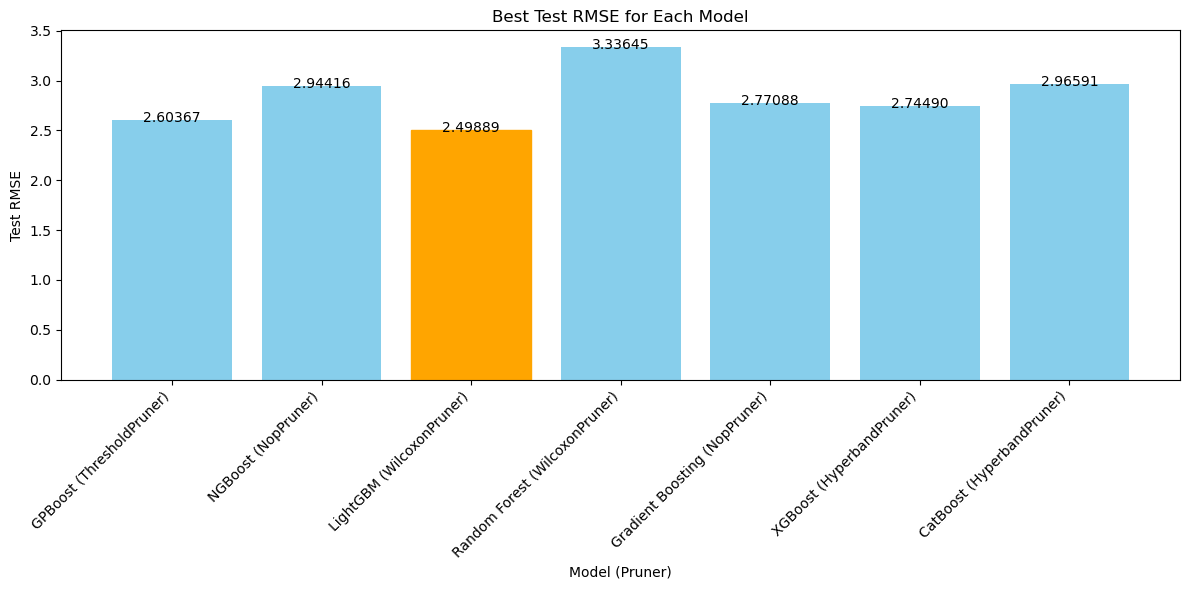

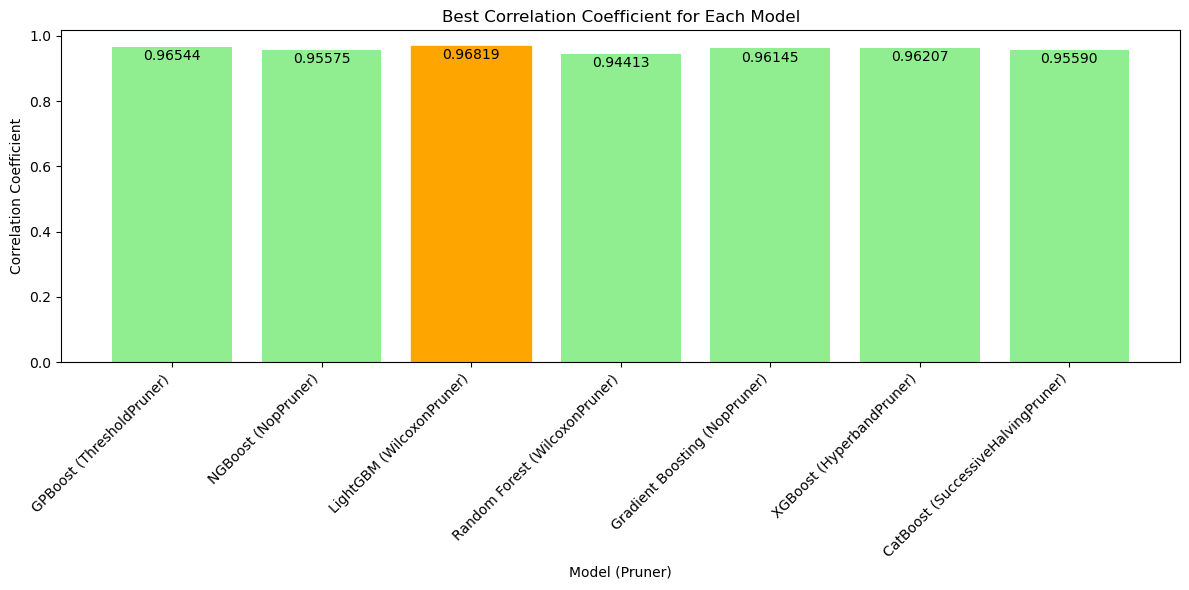

In [26]:
plot_best_scores(best_scores_cmaes_sampler)

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

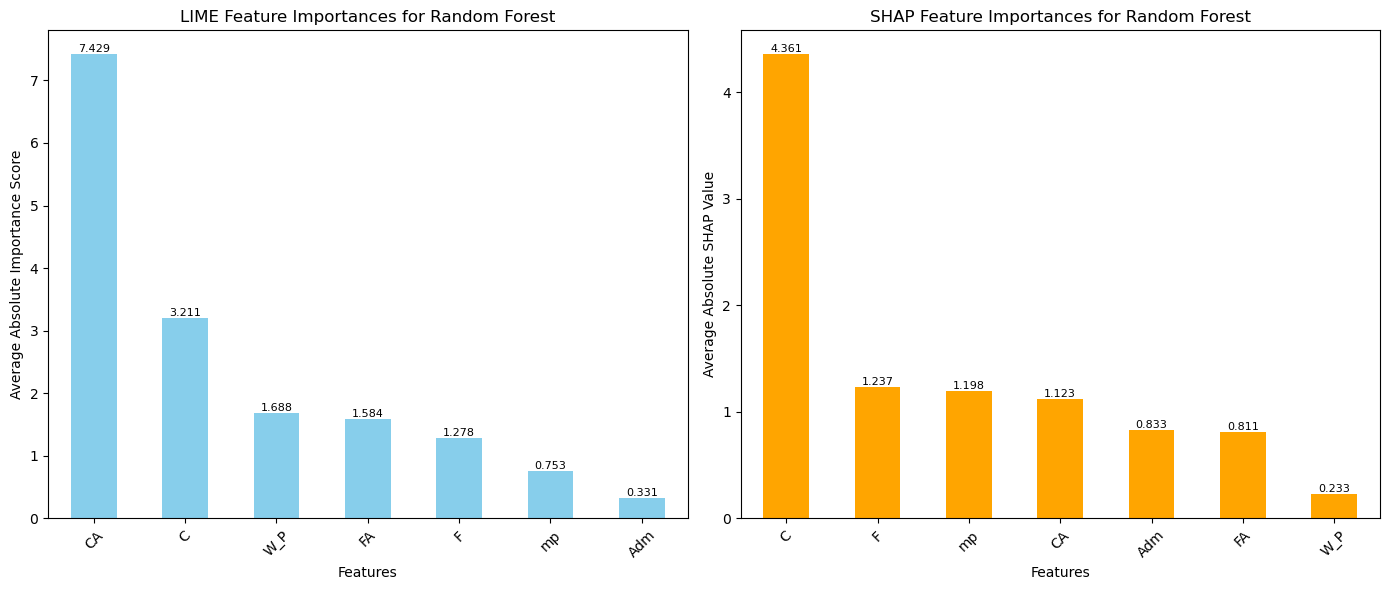

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

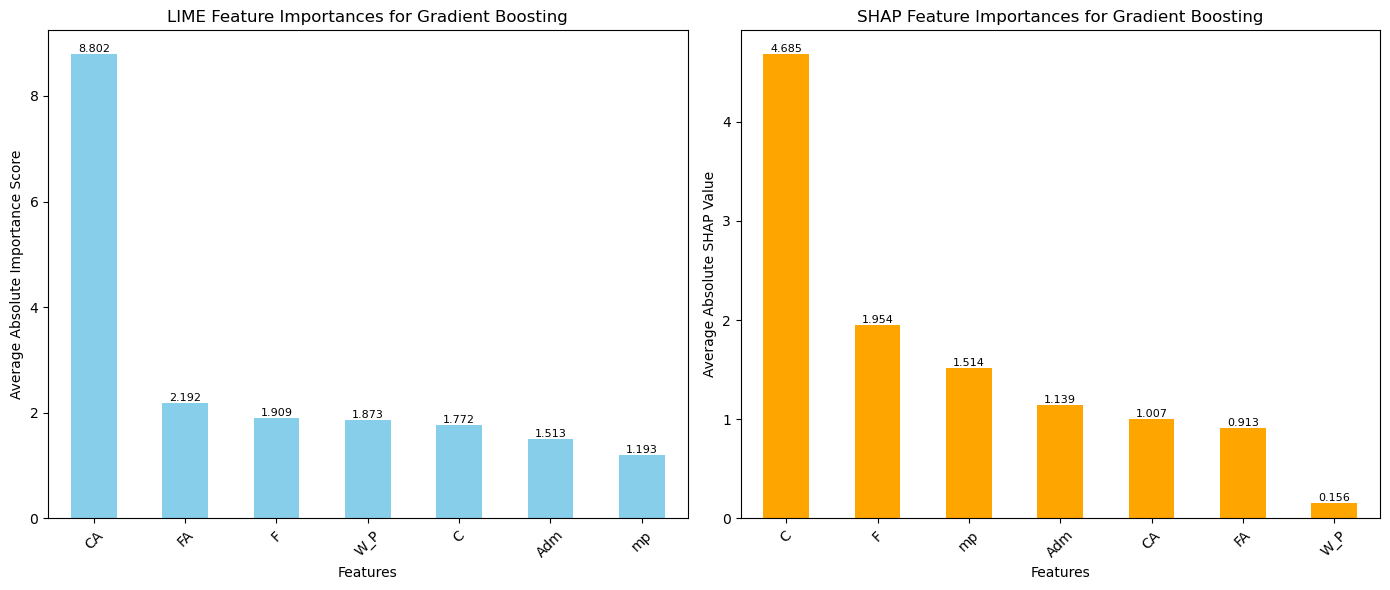

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

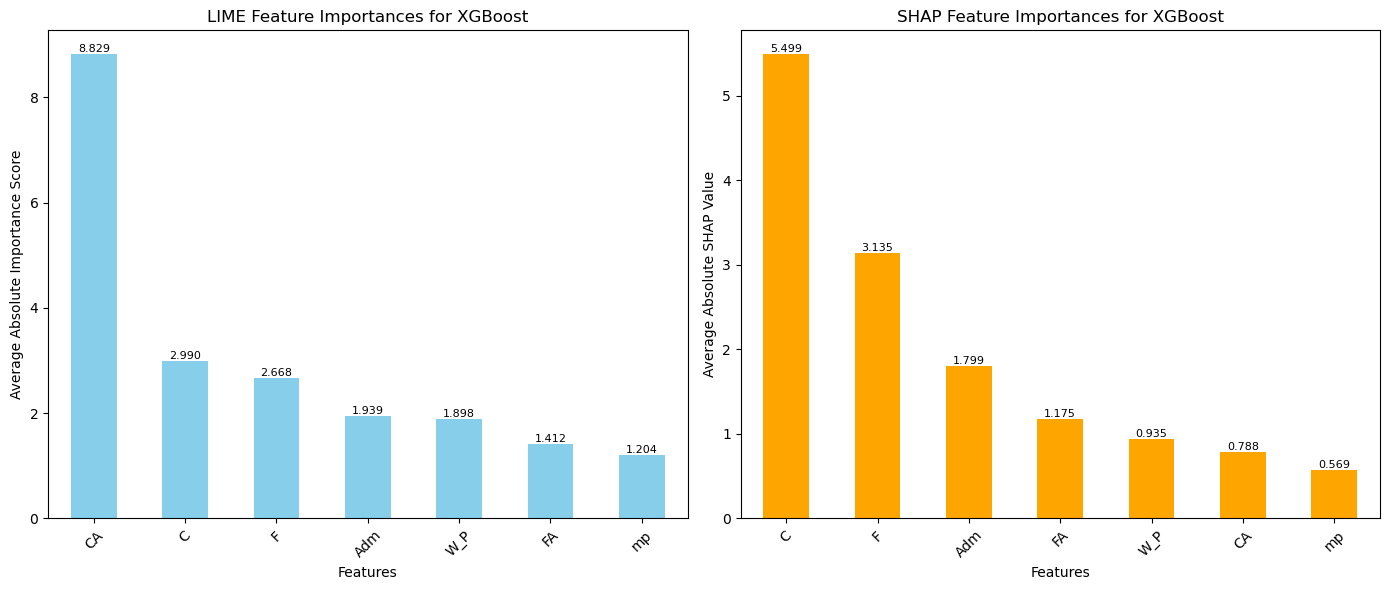

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

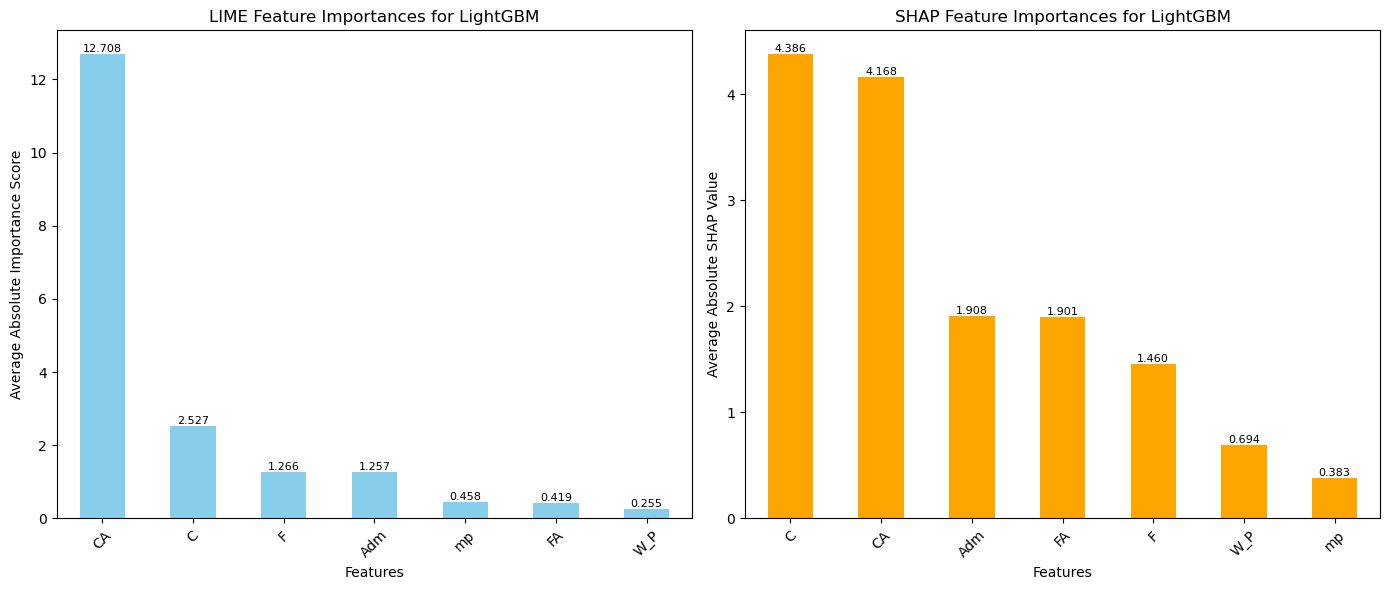

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.1. Current value: lambda_l2=0.1


Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

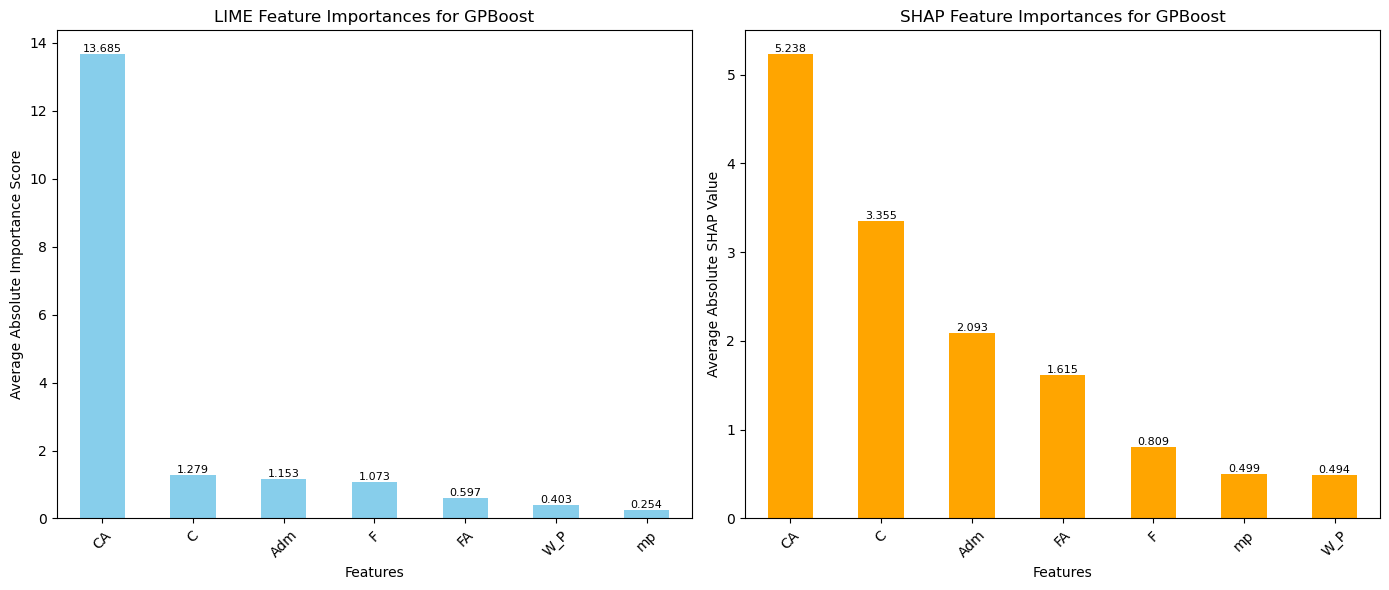

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

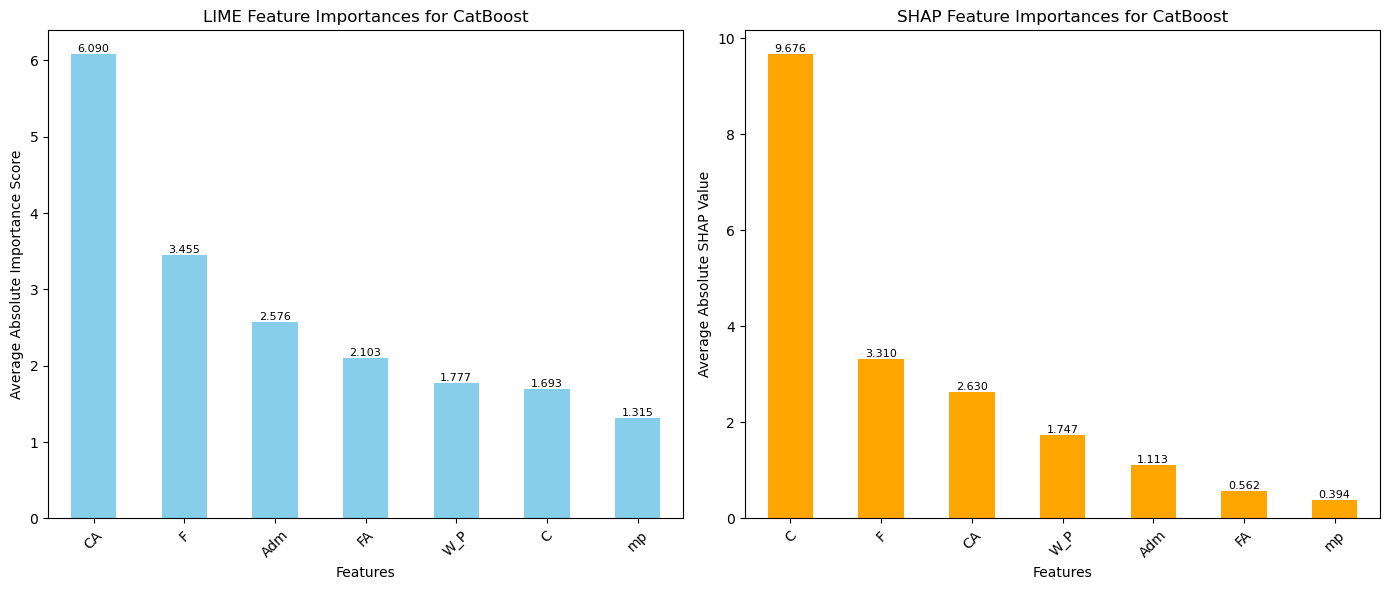

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

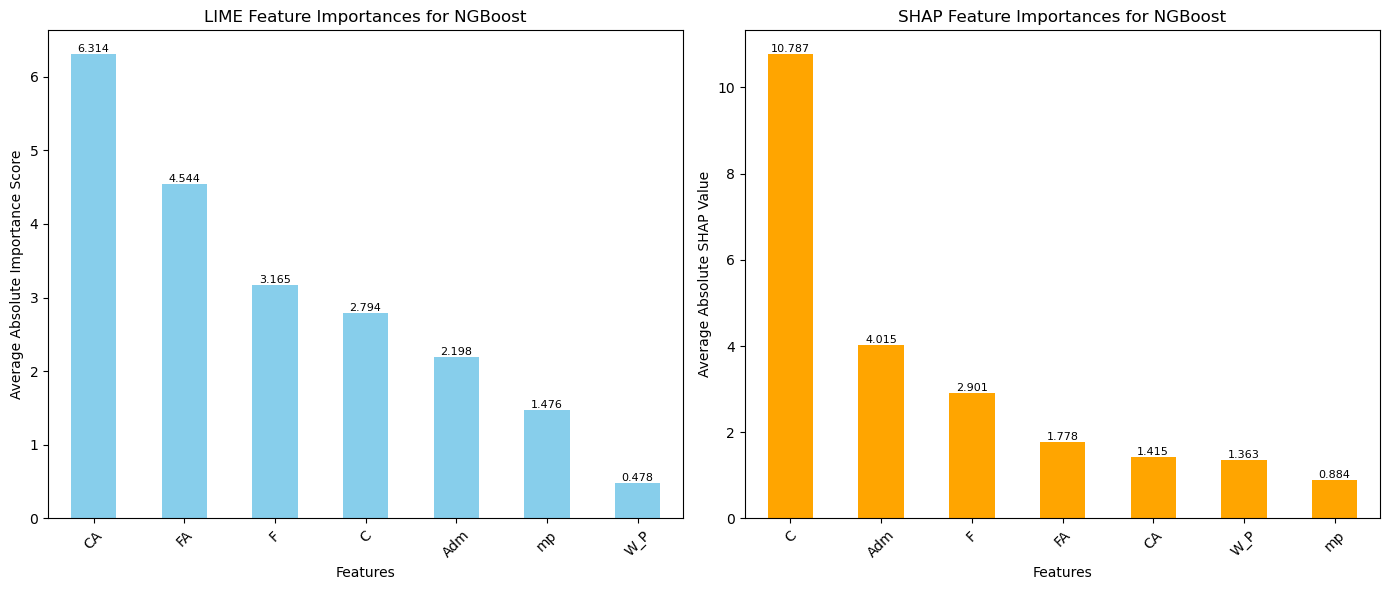

In [27]:
generate_interpretml_explanations_summary_pruners(best_scores_cmaes_sampler, X_train, y_train, x_test, feature_names)

# **GPSampler using optuna**

In [28]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def hyperparameter_tuning_gp(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space):
        # Suggest hyperparameters
        params = {}
        for key, values in param_space.items():
            if isinstance(values, list):
                # Use suggest_categorical for categorical choices
                params[key] = trial.suggest_categorical(key, values)
            elif isinstance(values, tuple) and all(isinstance(v, int) for v in values):
                # Use suggest_int for integer ranges
                params[key] = trial.suggest_int(key, *values)
            else:
                # Use suggest_float for float ranges
                params[key] = trial.suggest_float(key, *values)

        # Create a new instance of the model
        model = model_class()
        model.set_params(**params)

        # Ensure the input arrays are writable
        X_train_copy = np.array(X_train, copy=True)
        y_train_copy = np.array(y_train, copy=True)
        X_test_copy = np.array(X_test, copy=True)
        y_test_copy = np.array(y_test, copy=True)

        # Train model
        model.fit(X_train_copy, y_train_copy)

        # Predict
        y_pred = model.predict(X_test_copy)

        # Calculate MSE
        mse = mean_squared_error(y_test_copy, y_pred)

        return mse

    models = {
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'verbose': [-1]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0],
            'verbose': [-1]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'iterations': [100, 200, 300, 400, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128],
            'verbose': [0]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7],
            'verbose': [0]
        })
    }
    pruners = [
        optuna.pruners.MedianPruner(),
        optuna.pruners.NopPruner(),
        optuna.pruners.PatientPruner(optuna.pruners.MedianPruner(), patience=3),
        optuna.pruners.PercentilePruner(25.0),
        optuna.pruners.SuccessiveHalvingPruner(),
        optuna.pruners.HyperbandPruner(),
        optuna.pruners.ThresholdPruner(lower=0.1),
        optuna.pruners.WilcoxonPruner()
    ]

    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        for pruner in pruners:
            pruner_name = pruner.__class__.__name__
            print(f"Running Optuna for {model_name} with {pruner_name}...")
            try:
                # Use the GPSampler and pruner in the study creation
                sampler = GPSampler()
                study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
                study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)

                best_params = study.best_params
                best_model = model_class().set_params(**best_params)
                best_model.fit(X_train, y_train)
                y_pred = best_model.predict(X_test)

                # Calculate MSE
                mse = mean_squared_error(y_test, y_pred)

                # Calculate RMSE
                rmse = np.sqrt(mse)

                # Calculate correlation coefficient
                numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
                denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
                corr_coef = numerator / denominator if denominator != 0 else 0.0

                best_scores[(model_name, pruner_name)] = {
                    'best_score': mse,
                    'best_params': best_params,
                    'test_mse': mse,
                    'test_rmse': rmse,
                    'test_corr_coef': corr_coef,
                    'pruner': pruner_name
                }
                print(f"Best MSE for {model_name} with {pruner_name}: {mse} with params: {best_params}")
                print(f"Best RMSE for {model_name} with {pruner_name}: {rmse}")
                print(f"Correlation Coefficient for {model_name} with {pruner_name}: {corr_coef}")
            except Exception as e:
                print(f"Failed to run Optuna for {model_name} with {pruner_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name, best_pruner_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[(best_model_name, best_pruner_name)]
        print(f"\nBest model on test data: {best_model_name} with {best_pruner_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
        print(f"Pruner Used: {best_model_info['pruner']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_gp_sampler = hyperparameter_tuning_gp(X_train, y_train, X_test, y_test)

Running Optuna for Random Forest with MedianPruner...
Best MSE for Random Forest with MedianPruner: 11.594003567864824 with params: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 3}
Best RMSE for Random Forest with MedianPruner: 3.404996852842132
Correlation Coefficient for Random Forest with MedianPruner: 0.9426991418441775
Running Optuna for Random Forest with NopPruner...
Best MSE for Random Forest with NopPruner: 12.16710677418706 with params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}
Best RMSE for Random Forest with NopPruner: 3.4881380096244845
Correlation Coefficient for Random Forest with NopPruner: 0.9380623771734903
Running Optuna for Random Forest with PatientPruner...
Best MSE for Random Forest with PatientPruner: 11.71953887458085 with params: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 3}
Best RMSE 

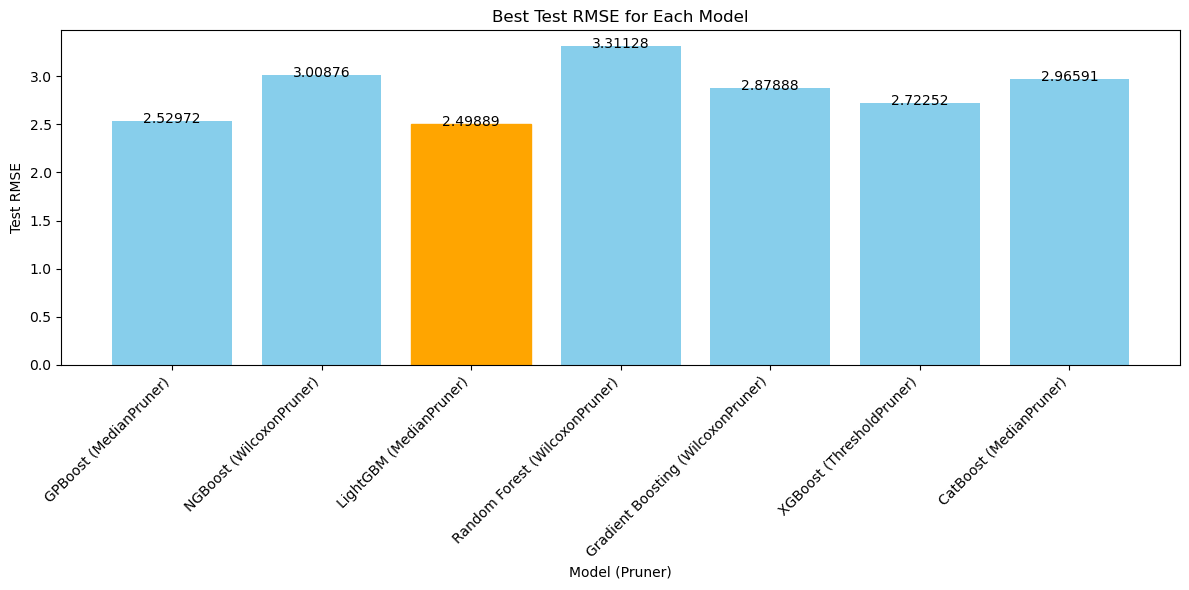

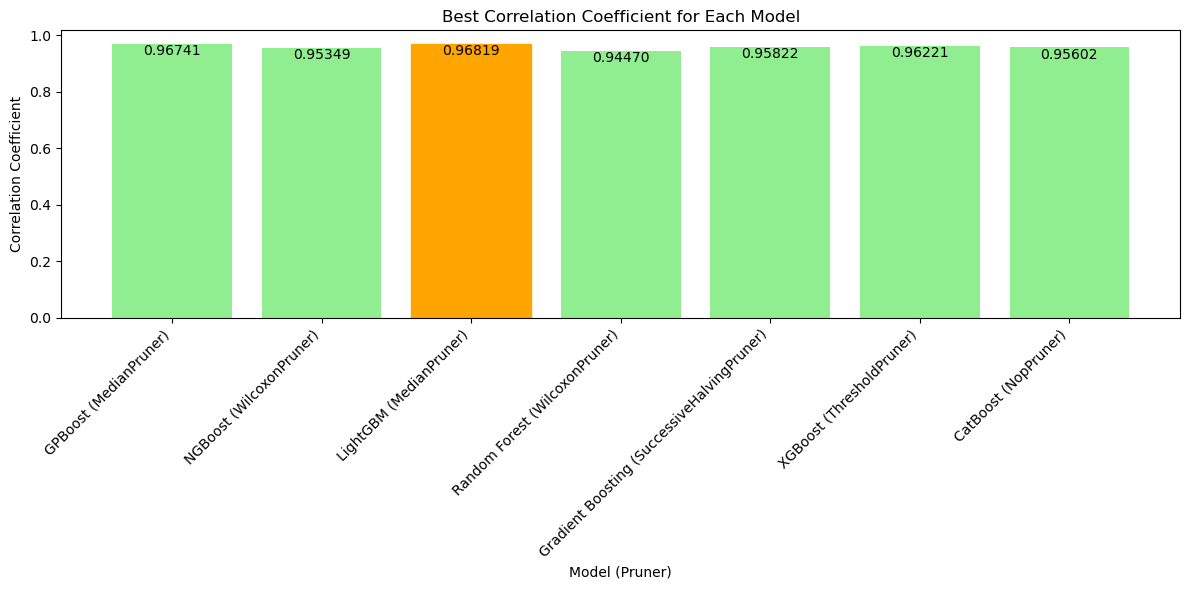

In [29]:
plot_best_scores(best_scores_gp_sampler)

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

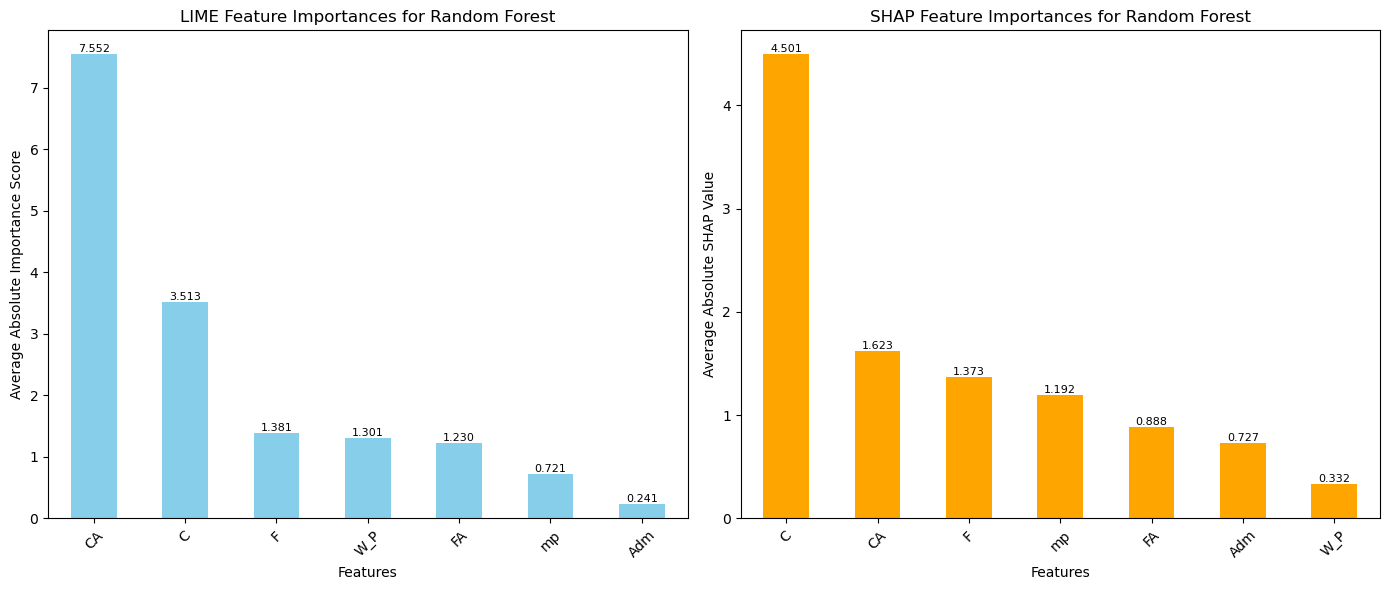

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

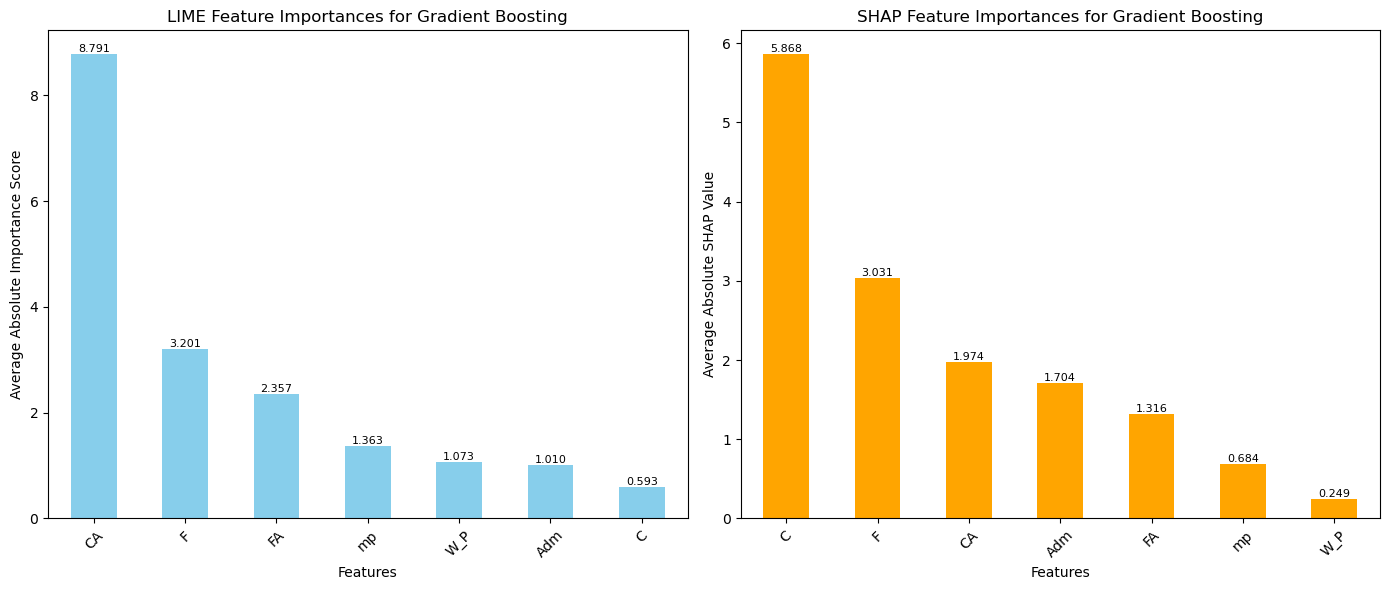

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

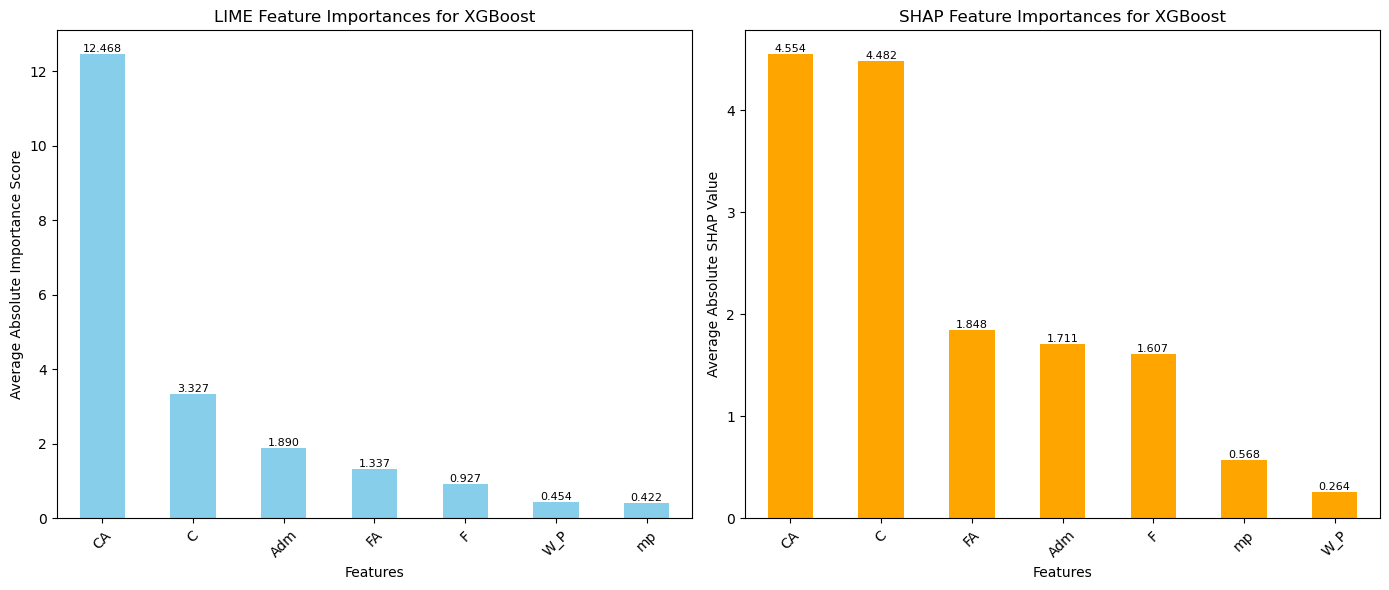

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

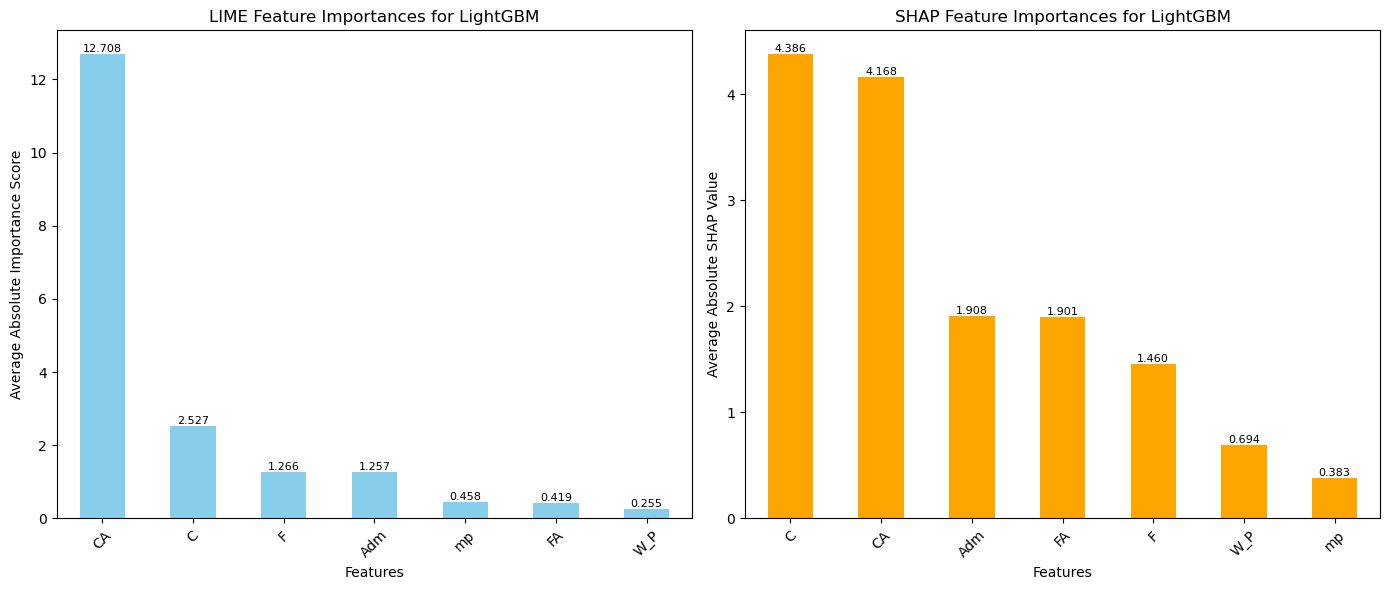

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.1. Current value: lambda_l2=0.1


Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

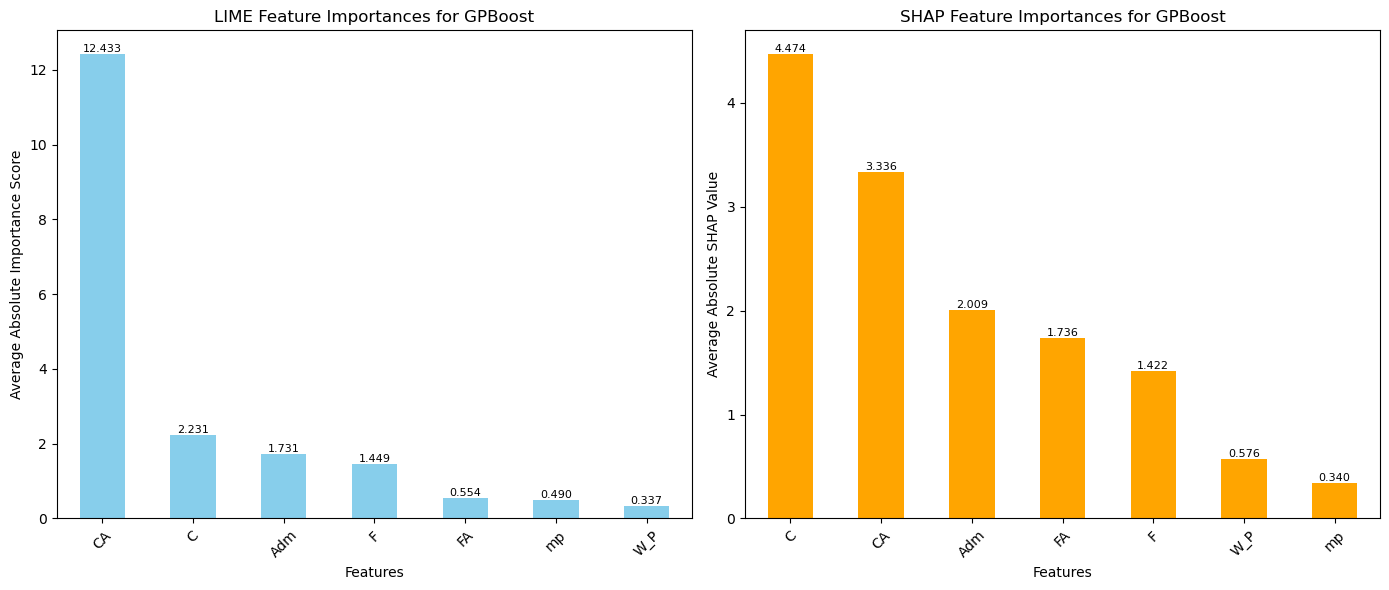

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

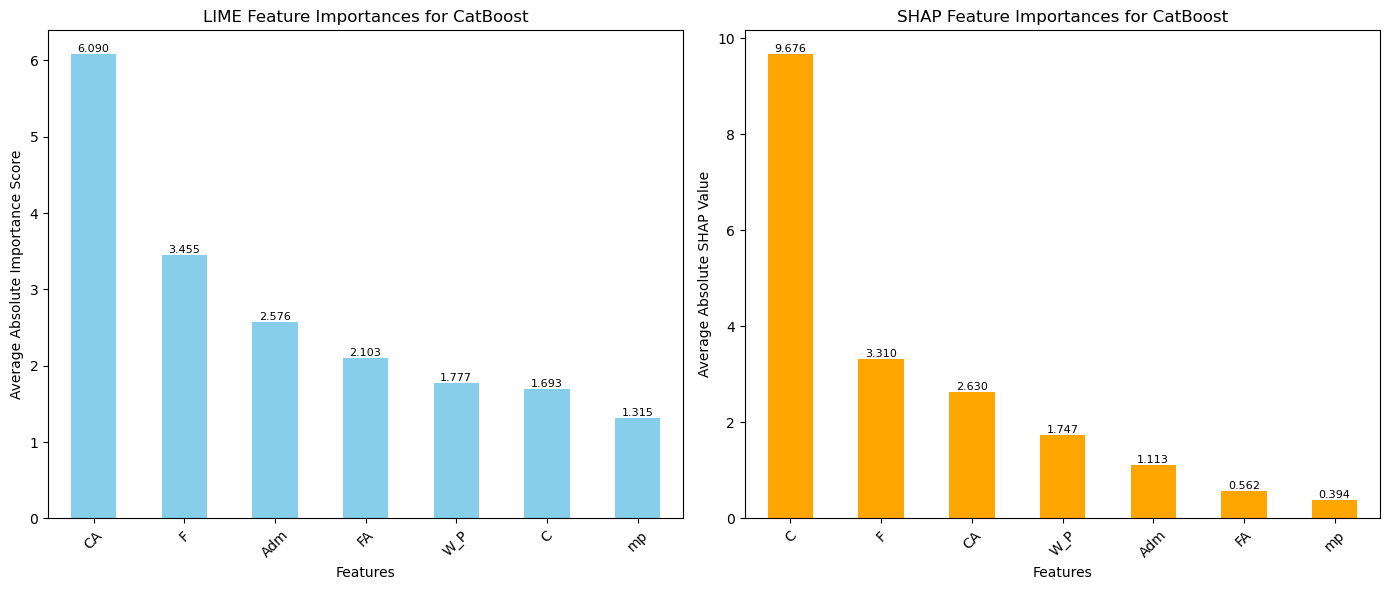

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

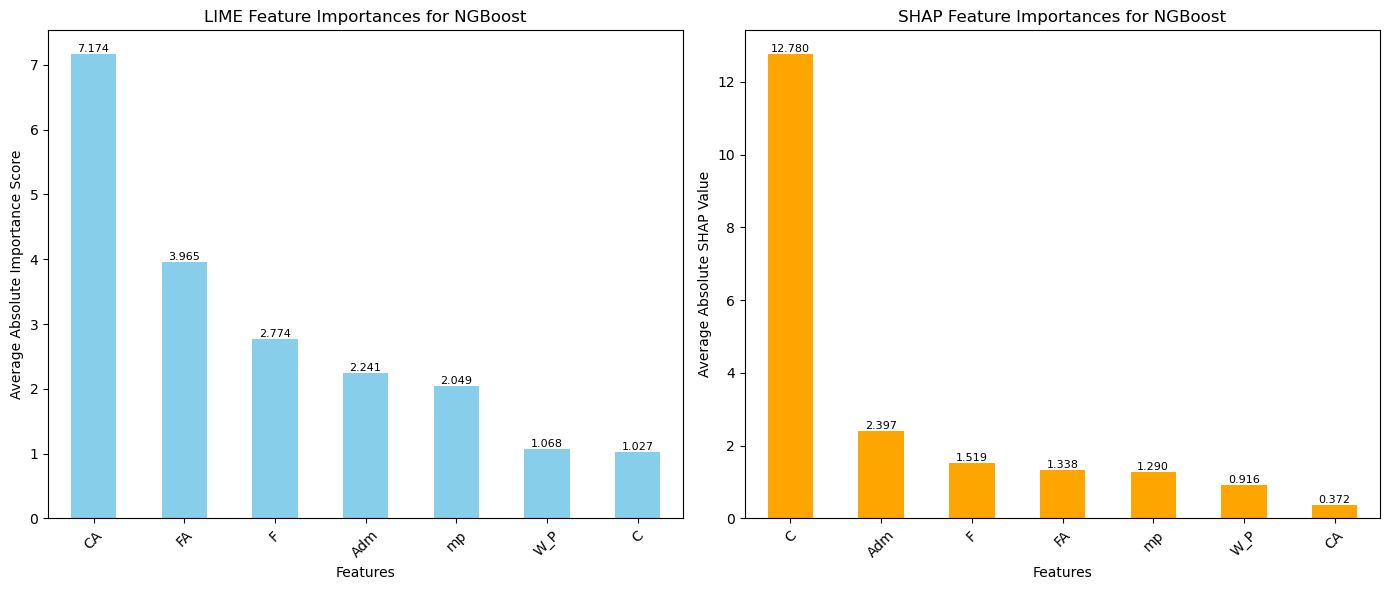

In [30]:
generate_interpretml_explanations_summary_pruners(best_scores_gp_sampler, X_train, y_train, x_test, feature_names)

# **PartialFixedSampler using optuna**

In [31]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def hyperparameter_tuning_partial(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space, fixed_params):
        # Suggest hyperparameters
        params = {}
        for key, values in param_space.items():
            if key in fixed_params:
                params[key] = fixed_params[key]
            else:
                if isinstance(values, list):
                    params[key] = trial.suggest_categorical(key, values)
                else:
                    params[key] = trial.suggest_float(key, *values)

        # Create a new instance of the model
        model = model_class()
        model.set_params(**params)

        # Ensure the input arrays are writable
        X_train_copy = np.array(X_train, copy=True)
        y_train_copy = np.array(y_train, copy=True)
        X_test_copy = np.array(X_test, copy=True)
        y_test_copy = np.array(y_test, copy=True)

        # Train model
        model.fit(X_train_copy, y_train_copy)

        # Predict
        y_pred = model.predict(X_test_copy)

        # Calculate MSE
        mse = mean_squared_error(y_test_copy, y_pred)

        return mse

    models = {
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'verbose': [-1]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0],
            'verbose': [-1]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'iterations': [100, 200, 300, 400, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128],
            'verbose': [0]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7],
            'verbose': [0]
        })
    }

    pruners = [
        optuna.pruners.MedianPruner(),
        optuna.pruners.NopPruner(),
        optuna.pruners.PatientPruner(optuna.pruners.MedianPruner(), patience=3),
        optuna.pruners.PercentilePruner(25.0),
        optuna.pruners.SuccessiveHalvingPruner(),
        optuna.pruners.HyperbandPruner(),
        optuna.pruners.ThresholdPruner(lower=0.1),
        optuna.pruners.WilcoxonPruner()
    ]

    # Define fixed parameters
    fixed_params = {
        'n_estimators': 200,  # Example of a fixed parameter
        # Add more fixed parameters as needed
    }

    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        for pruner in pruners:
            pruner_name = pruner.__class__.__name__
            print(f"Running Optuna for {model_name} with {pruner_name}...")
            try:
                # Use the PartialFixedSampler and pruner in the study creation
                sampler = PartialFixedSampler(fixed_params=fixed_params, base_sampler=TPESampler())
                study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
                study.optimize(lambda trial: objective(trial, model_name, model_class, param_space, fixed_params), n_trials=50)

                best_params = study.best_params
                best_model = model_class().set_params(**best_params)
                best_model.fit(X_train, y_train)
                y_pred = best_model.predict(X_test)

                # Calculate MSE
                mse = mean_squared_error(y_test, y_pred)

                # Calculate RMSE
                rmse = np.sqrt(mse)

                # Calculate correlation coefficient
                numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
                denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
                corr_coef = numerator / denominator if denominator != 0 else 0.0

                best_scores[(model_name, pruner_name)] = {
                    'best_score': mse,
                    'best_params': best_params,
                    'test_mse': mse,
                    'test_rmse': rmse,
                    'test_corr_coef': corr_coef,
                    'pruner': pruner_name
                }
                print(f"Best MSE for {model_name} with {pruner_name}: {mse} with params: {best_params}")
                print(f"Best RMSE for {model_name} with {pruner_name}: {rmse}")
                print(f"Correlation Coefficient for {model_name} with {pruner_name}: {corr_coef}")
            except Exception as e:
                print(f"Failed to run Optuna for {model_name} with {pruner_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name, best_pruner_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[(best_model_name, best_pruner_name)]
        print(f"\nBest model on test data: {best_model_name} with {best_pruner_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
        print(f"Pruner Used: {best_model_info['pruner']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_partial_fixed_sampler = hyperparameter_tuning_partial(X_train, y_train, X_test, y_test)

Running Optuna for Random Forest with MedianPruner...
Best MSE for Random Forest with MedianPruner: 11.736659896002507 with params: {'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 3}
Best RMSE for Random Forest with MedianPruner: 3.425880893434929
Correlation Coefficient for Random Forest with MedianPruner: 0.9402376106076948
Running Optuna for Random Forest with NopPruner...
Best MSE for Random Forest with NopPruner: 11.533793395618408 with params: {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}
Best RMSE for Random Forest with NopPruner: 3.3961439008997263
Correlation Coefficient for Random Forest with NopPruner: 0.9414335814650169
Running Optuna for Random Forest with PatientPruner...
Best MSE for Random Forest with PatientPruner: 10.861501052926437 with params: {'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 2}
Best RMSE for Random Forest with PatientPruner: 3.295679148965572
Cor

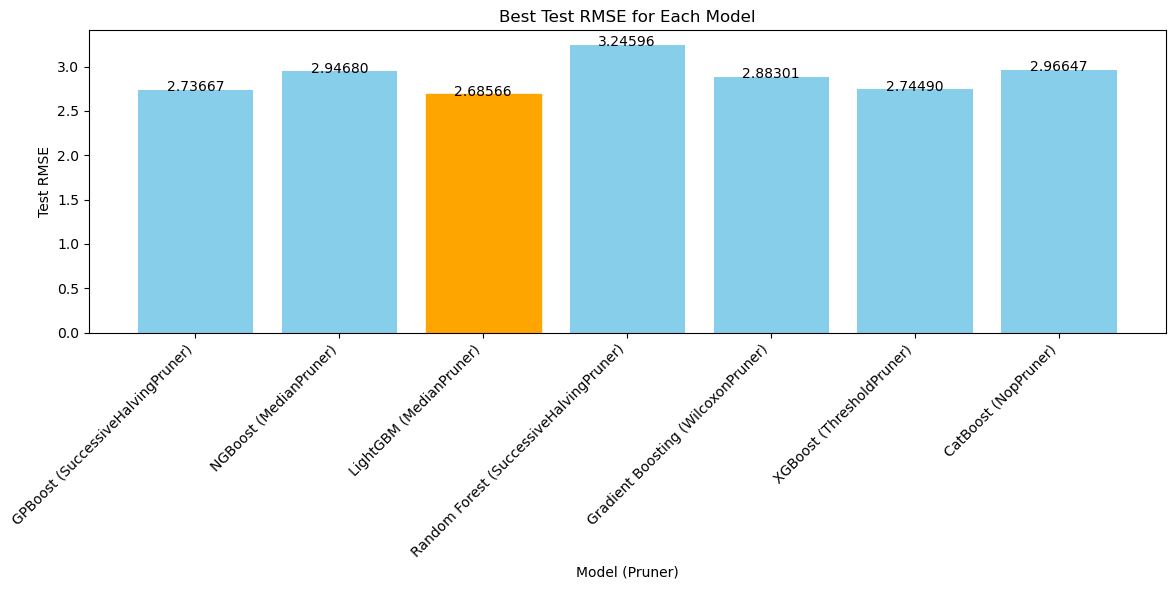

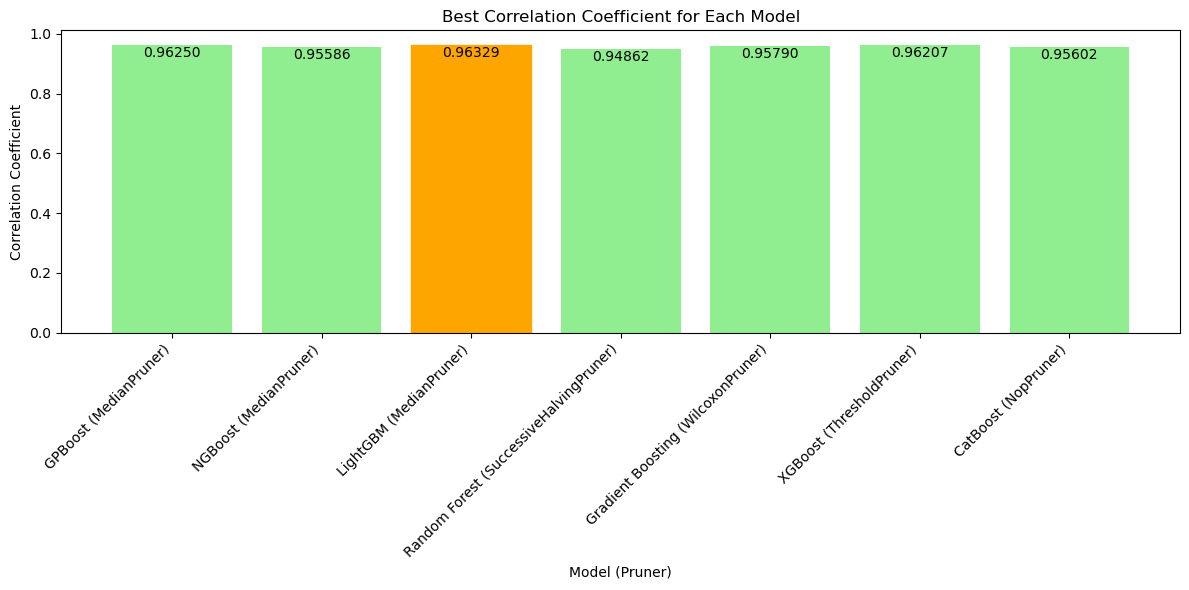

In [32]:
plot_best_scores(best_scores_partial_fixed_sampler)

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

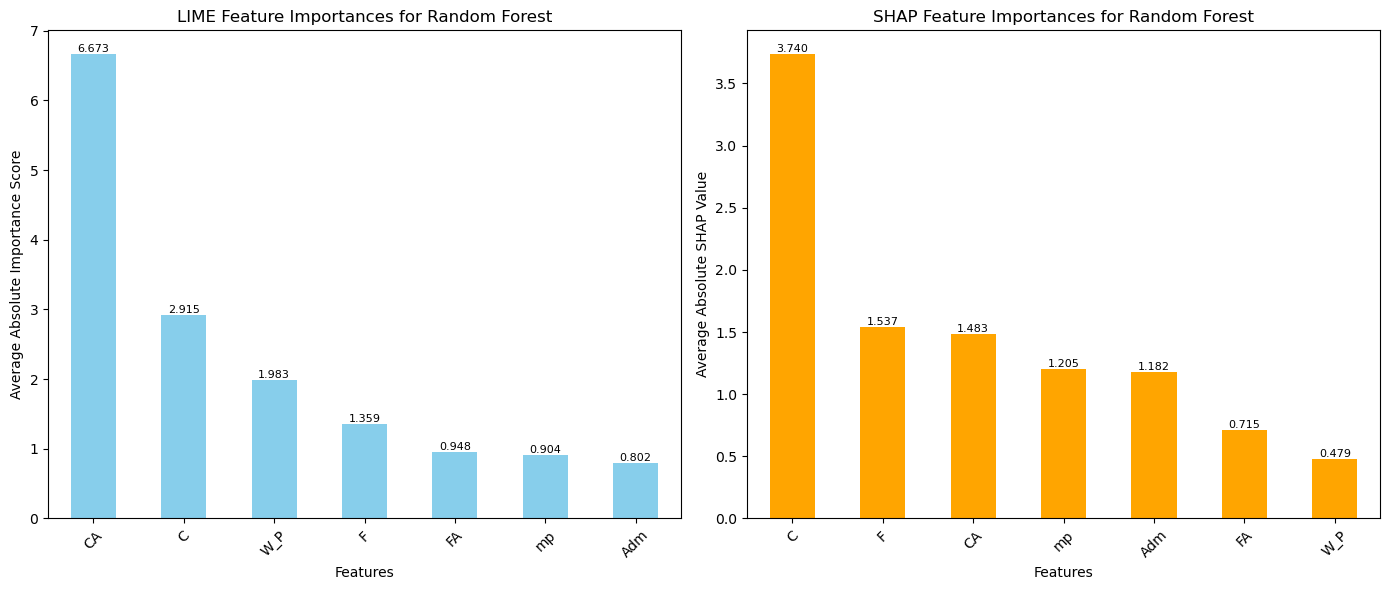

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

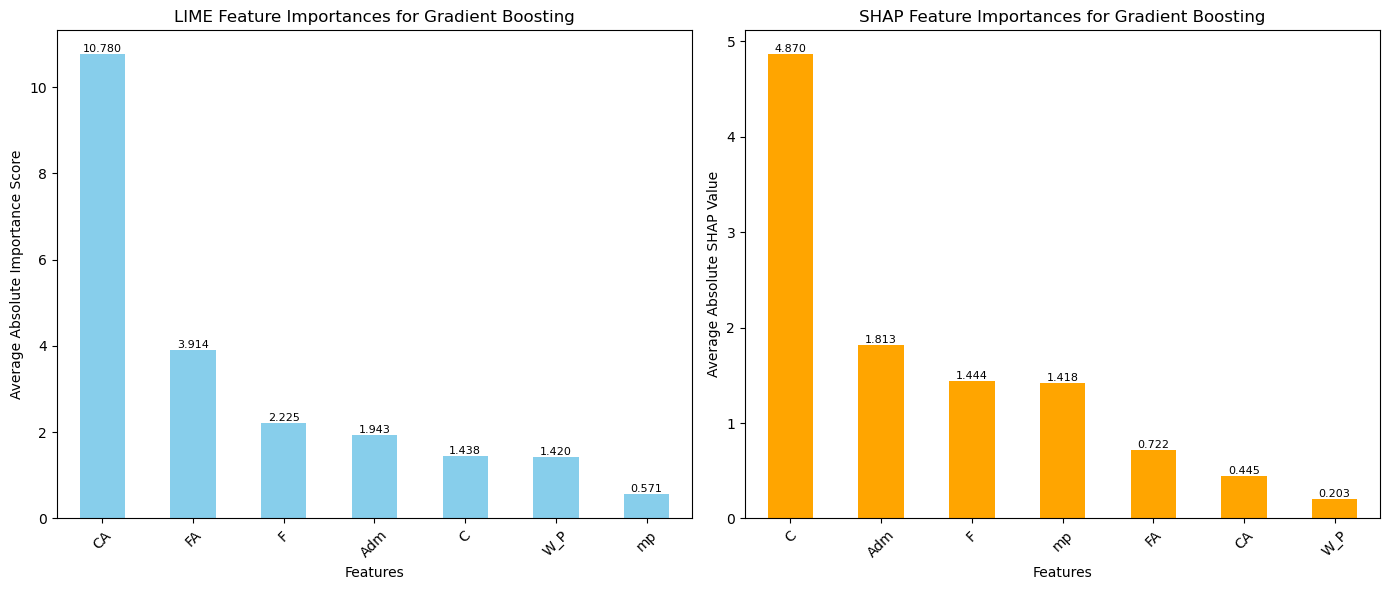

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

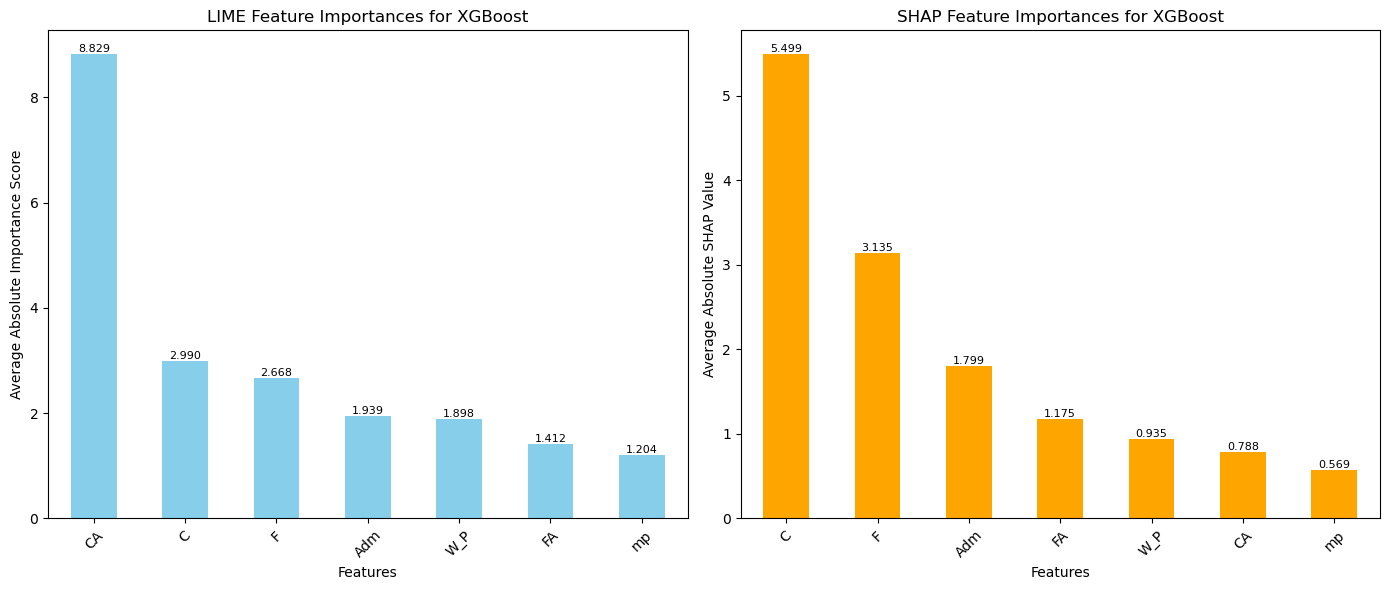

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

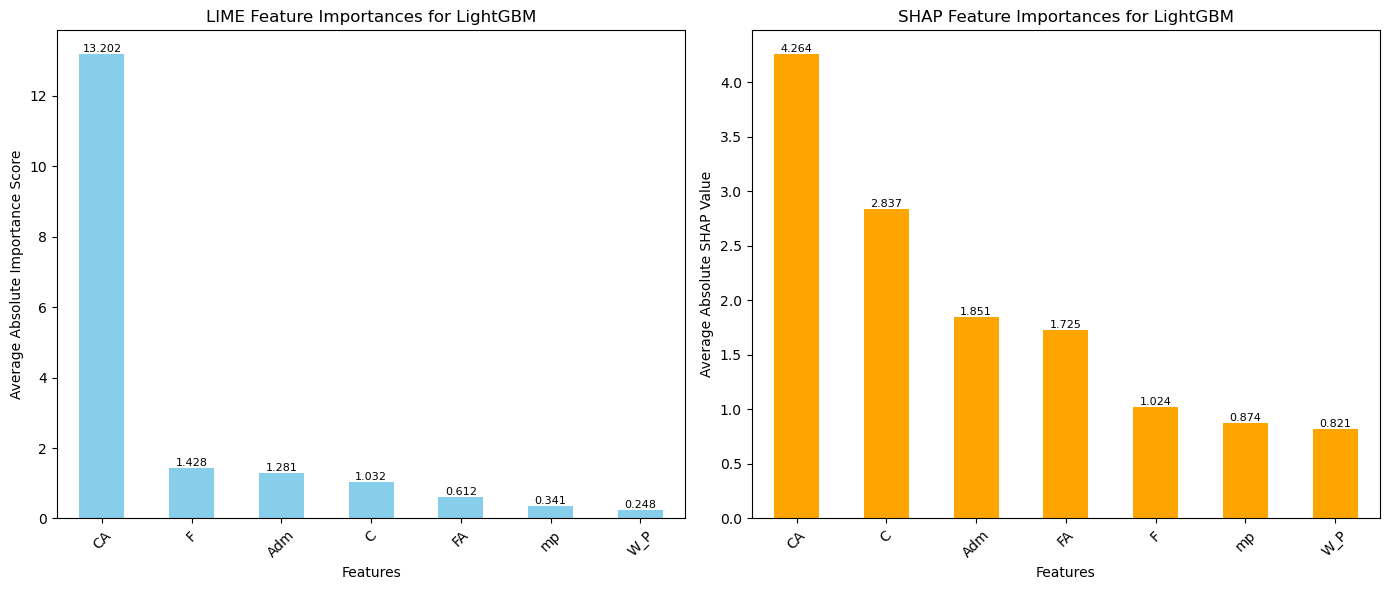

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=1.0. Current value: lambda_l2=1.0


Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

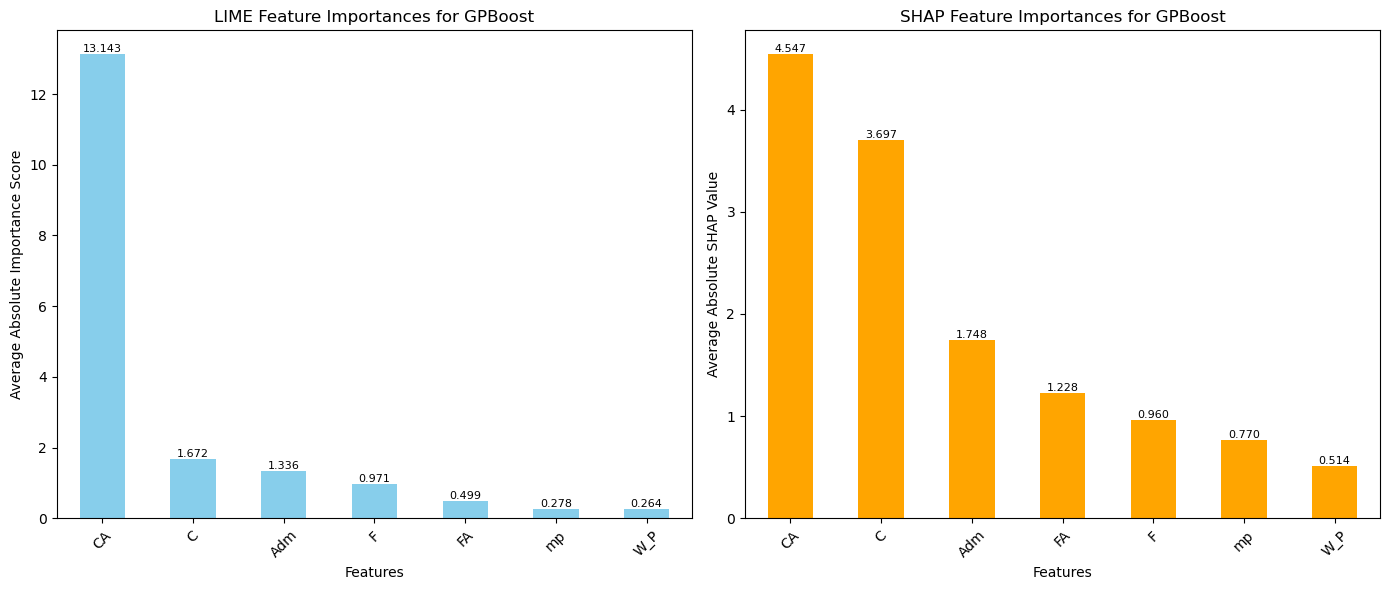

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

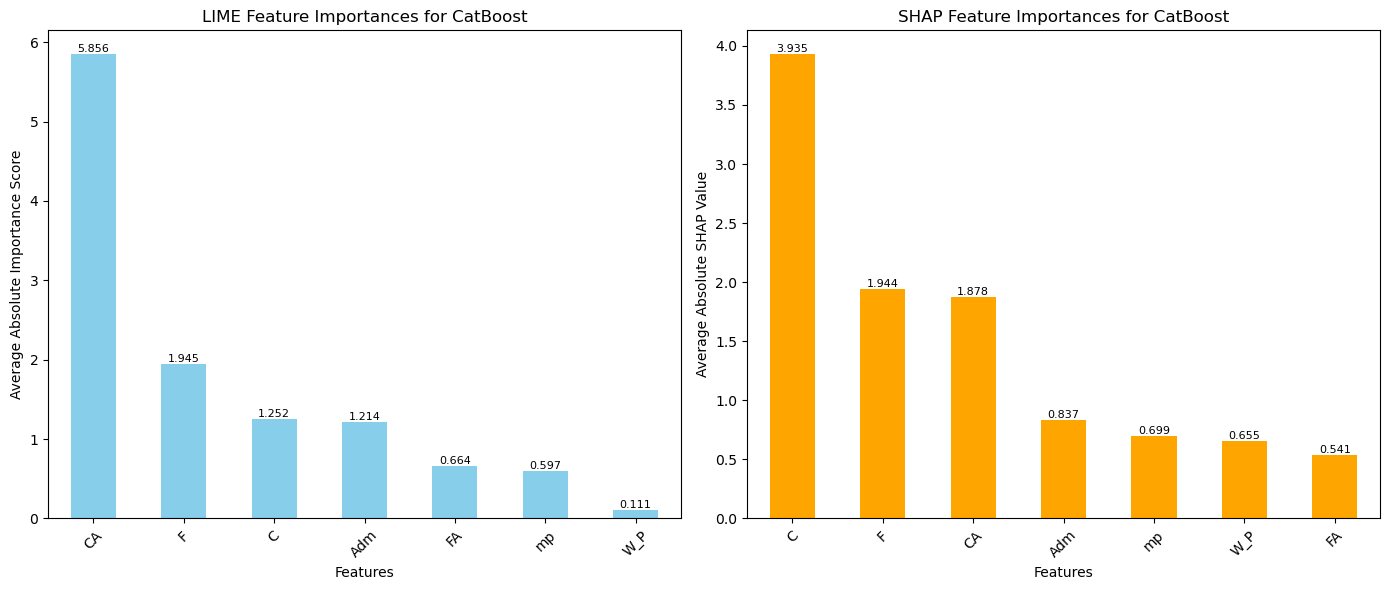

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

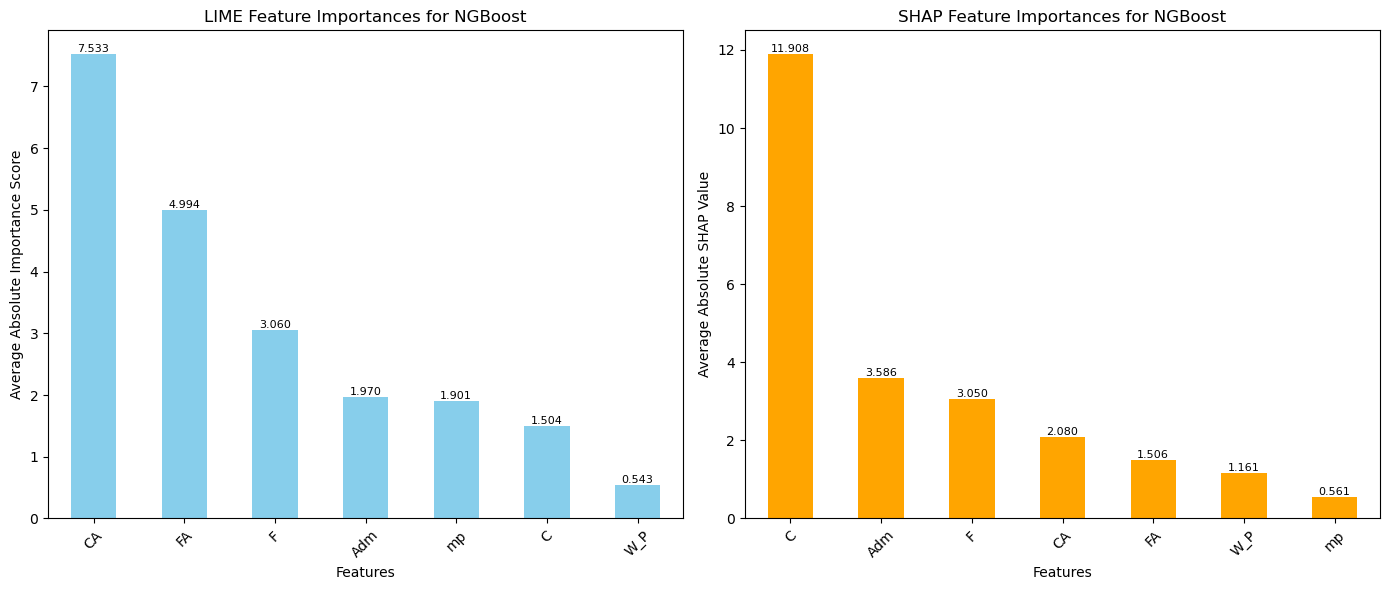

In [33]:
generate_interpretml_explanations_summary_pruners(best_scores_partial_fixed_sampler, X_train, y_train, x_test, feature_names)

# **NSGAIISampler using optuna**

In [34]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def hyperparameter_tuning_nsg(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space):
        # Suggest hyperparameters
        params = {}
        for key, values in param_space.items():
            if isinstance(values, list):
                params[key] = trial.suggest_categorical(key, values)
            elif isinstance(values, tuple) and all(isinstance(v, int) for v in values):
                params[key] = trial.suggest_int(key, *values)
            else:
                params[key] = trial.suggest_float(key, *values)

        # Create a new instance of the model
        model = model_class()
        model.set_params(**params)

        # Ensure the input arrays are writable
        X_train_copy = np.array(X_train, copy=True)
        y_train_copy = np.array(y_train, copy=True)
        X_test_copy = np.array(X_test, copy=True)
        y_test_copy = np.array(y_test, copy=True)

        # Train model
        start_time = time.time()
        model.fit(X_train_copy, y_train_copy)
        training_time = time.time() - start_time

        # Predict
        y_pred = model.predict(X_test_copy)

        # Calculate MSE
        mse = mean_squared_error(y_test_copy, y_pred)

        # Return both objectives: MSE and training time
        return mse, training_time

    models = {
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'verbose': [-1]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0],
            'verbose': [-1]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'iterations': [100, 200, 300, 400, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128],
            'verbose': [0]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7],
            'verbose': [0]
        })
    }

    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        print(f"Running Optuna for {model_name} with NSGAIISampler...")
        try:
            # Use the NSGAIISampler in the study creation
            sampler = NSGAIISampler()
            study = optuna.create_study(directions=['minimize', 'minimize'], sampler=sampler)
            study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)
            
            # Retrieve the best trial based on Pareto front (first trial in the sorted list)
            best_trial = sorted(study.best_trials, key=lambda t: t.values)[0]
            best_params = best_trial.params
            best_model = model_class().set_params(**best_params)
            best_model.fit(X_train, y_train)
            y_pred = best_model.predict(X_test)

            # Calculate MSE and RMSE
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)

            # Calculate Correlation Coefficient
            corr_coef = np.corrcoef(y_test, y_pred)[0, 1]

            best_scores[model_name] = {
                'best_score': mse,
                'best_params': best_params,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {best_params}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run Optuna for {model_name}. Error: {e}")

    # Find the model with the best MSE on test data
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores
    
best_scores_nsga_ii_sampler = hyperparameter_tuning_nsg(X_train, y_train, X_test, y_test)

Running Optuna for Random Forest with NSGAIISampler...
Best MSE for Random Forest: 11.775754613626738 with params: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 3}
Best RMSE for Random Forest: 3.4315819403923227
Correlation Coefficient for Random Forest: 0.9401314056061529
Running Optuna for Gradient Boosting with NSGAIISampler...
Best MSE for Gradient Boosting: 8.695624173457093 with params: {'n_estimators': 500, 'learning_rate': 0.15, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 3}
Best RMSE for Gradient Boosting: 2.948834375385822
Correlation Coefficient for Gradient Boosting: 0.9556957202293912
Running Optuna for XGBoost with NSGAIISampler...
Best MSE for XGBoost: 8.292584772127372 with params: {'learning_rate': 0.15, 'max_depth': 5, 'n_estimators': 300, 'min_child_weight': 1, 'gamma': 0.1, 'subsample': 0.6, 'colsample_bytree': 0.7}
Best RMSE for XGBoost: 2.8796848390279397
Correlation Coeff

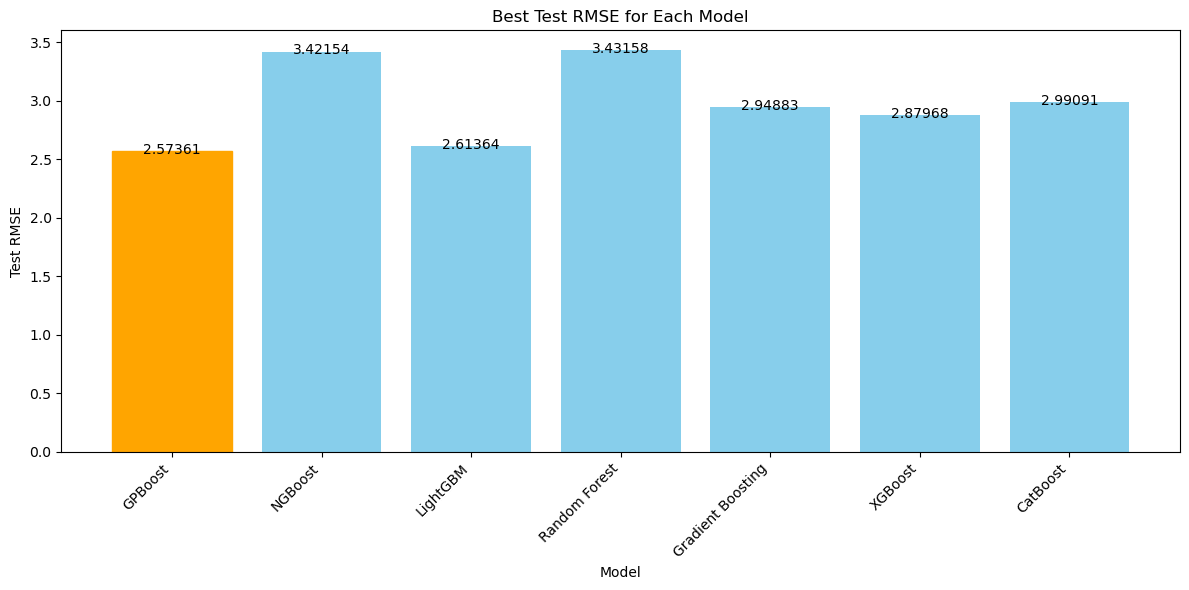

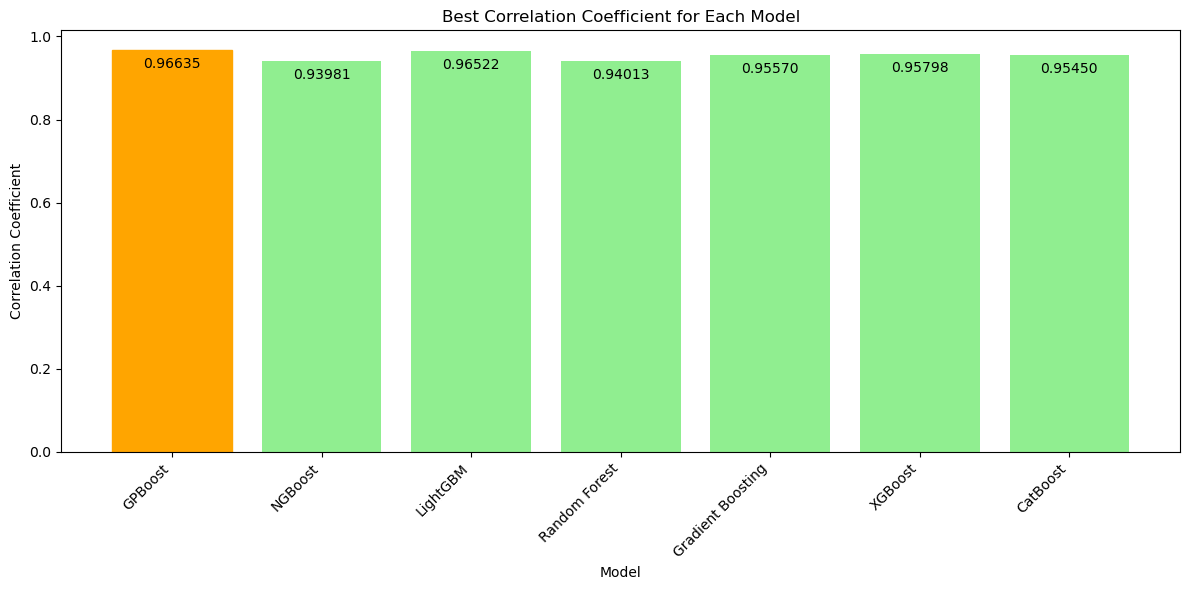

In [35]:
plot_best_scores_without_pruners(best_scores_nsga_ii_sampler)

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

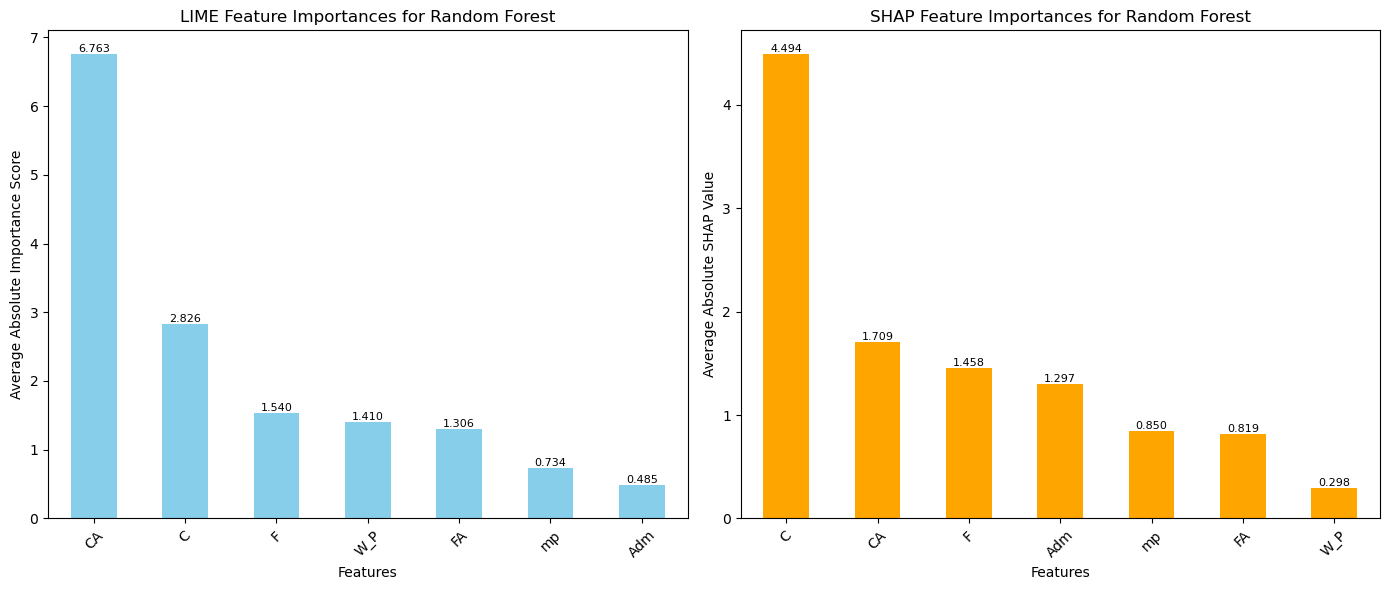

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

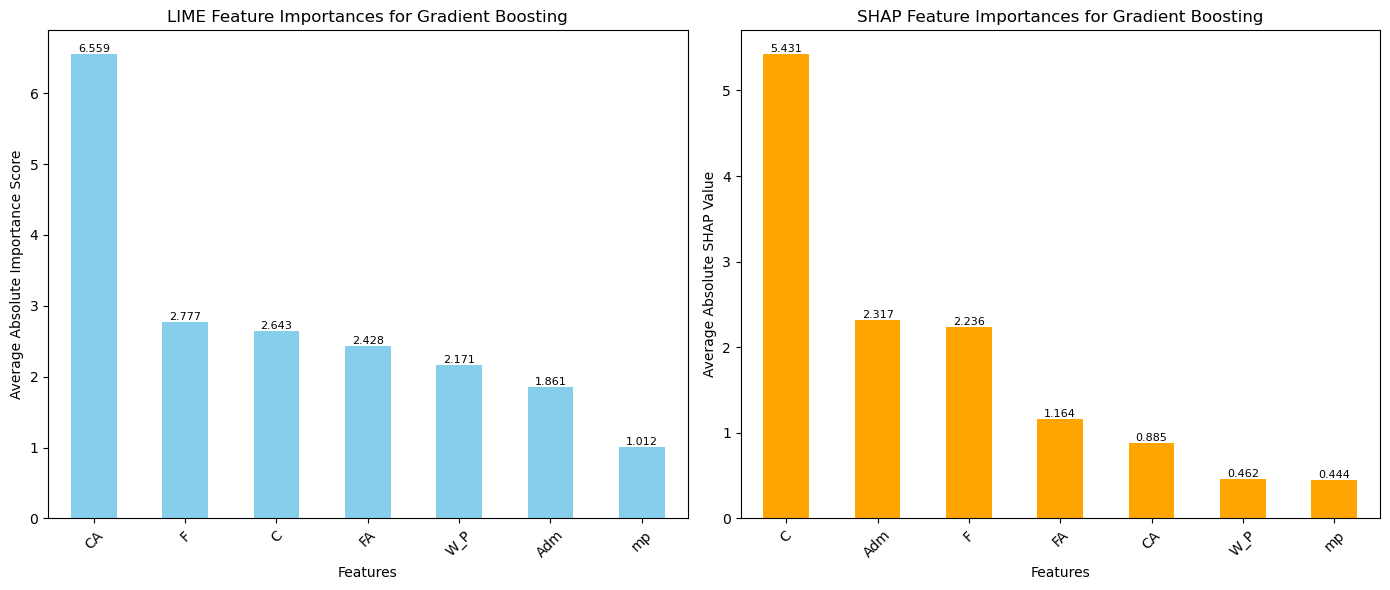

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

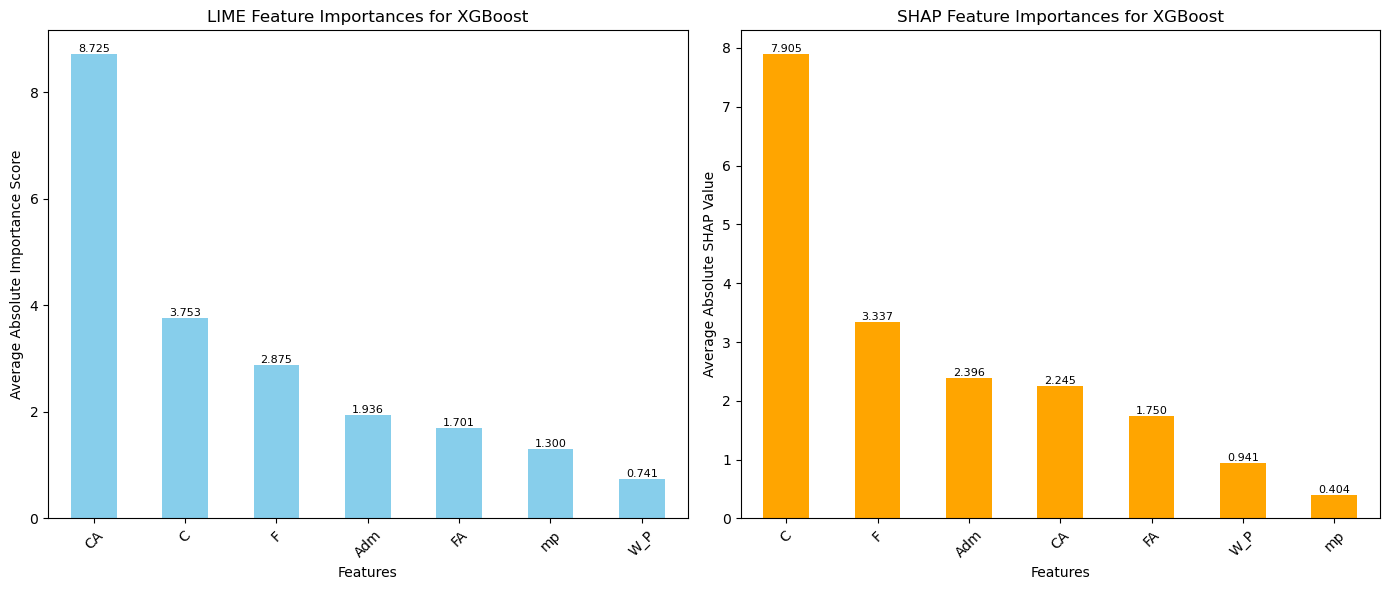

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

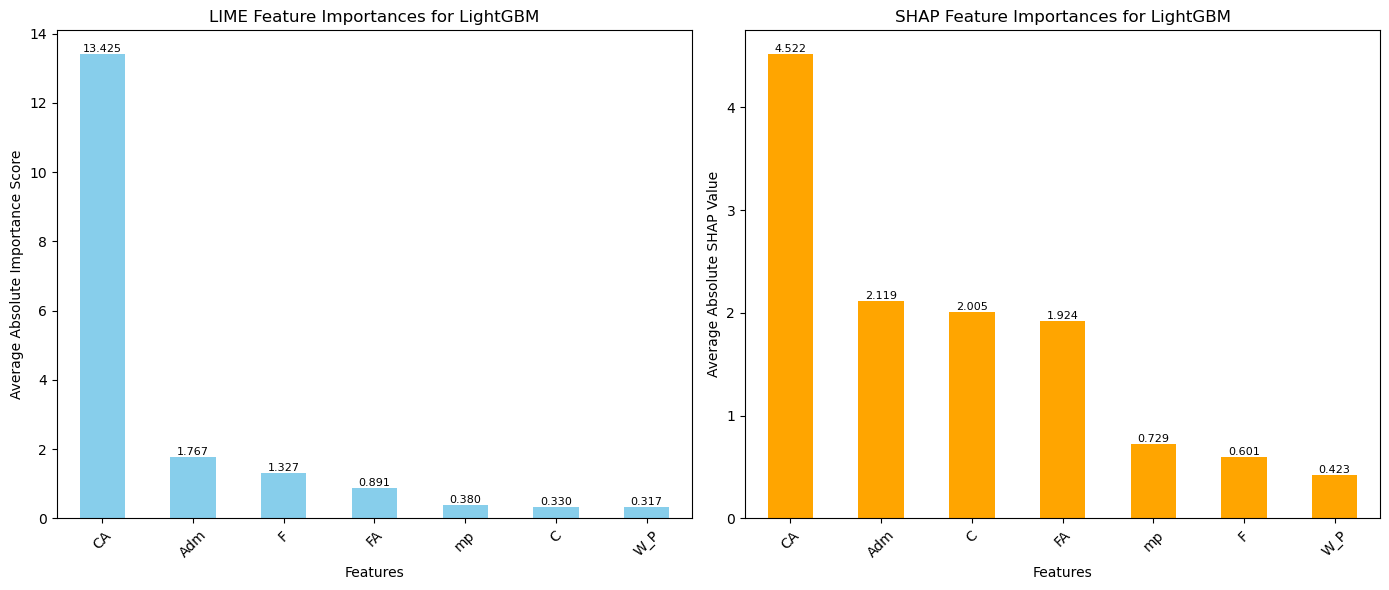

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.5. Current value: lambda_l2=0.5


Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

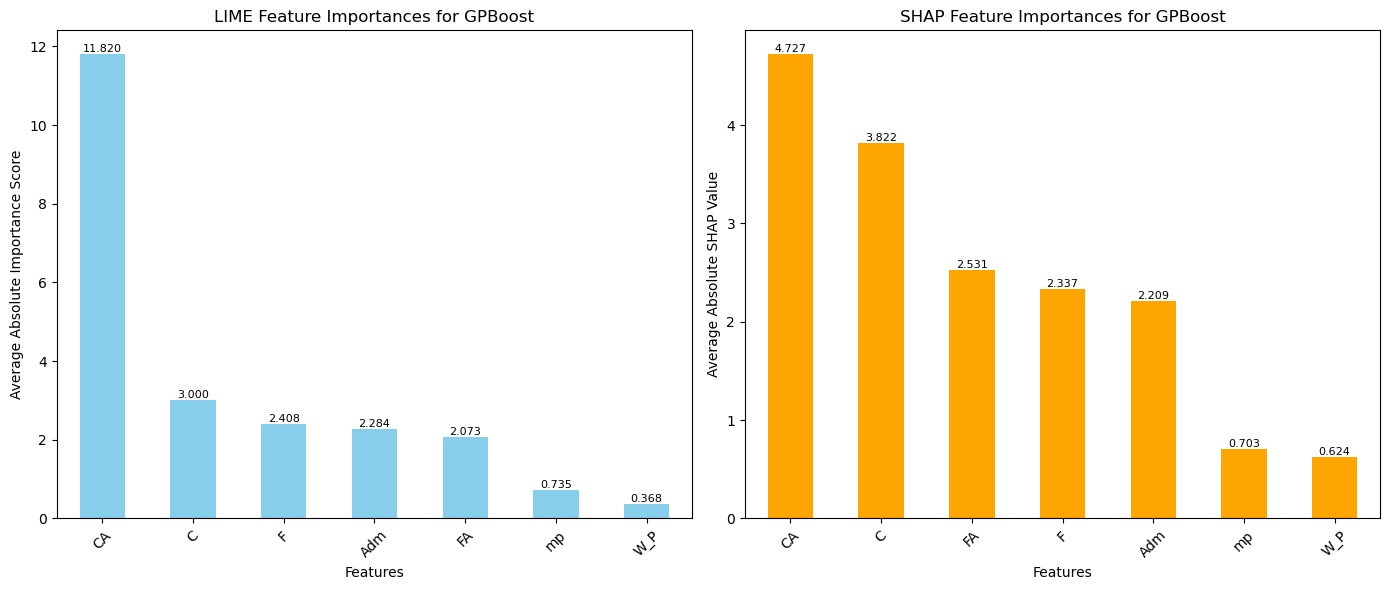

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

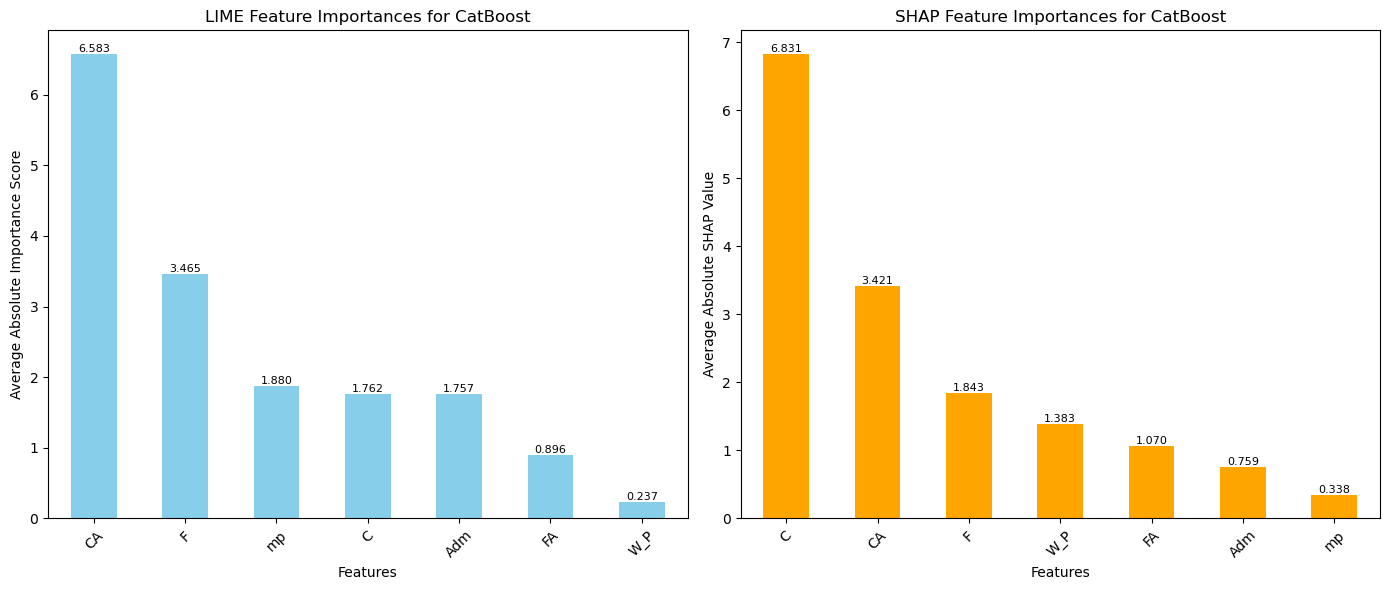

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

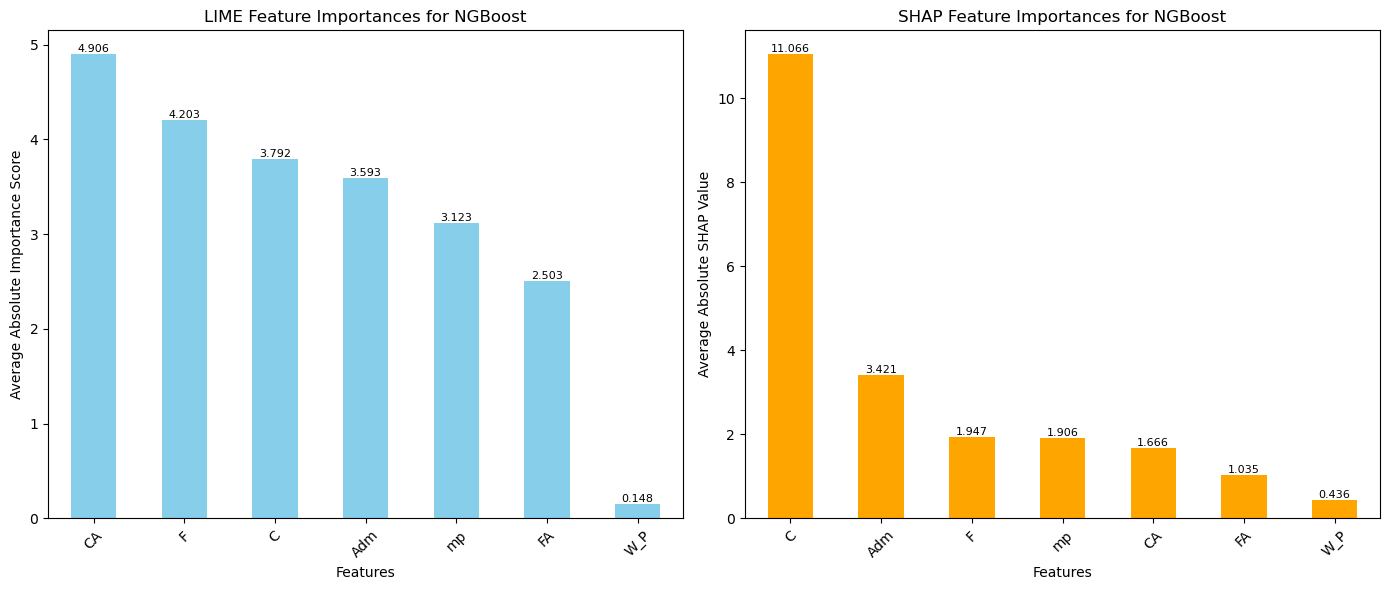

In [36]:
generate_interpretml_explanations_summary(best_scores_nsga_ii_sampler, X_train, y_train, x_test, feature_names)

# **NSGAIIISampler using optuna**

In [37]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def hyperparameter_tuning_nsga(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space):
        # Suggest hyperparameters
        params = {}
        for key, values in param_space.items():
            if isinstance(values, list):
                params[key] = trial.suggest_categorical(key, values)
            else:
                params[key] = trial.suggest_float(key, *values)

        # Create a new instance of the model
        model = model_class()
        model.set_params(**params)

        # Ensure the input arrays are writable
        X_train_copy = np.array(X_train, copy=True)
        y_train_copy = np.array(y_train, copy=True)
        X_test_copy = np.array(X_test, copy=True)
        y_test_copy = np.array(y_test, copy=True)

        # Train model
        start_time = time.time()
        model.fit(X_train_copy, y_train_copy)
        training_time = time.time() - start_time

        # Predict
        y_pred = model.predict(X_test_copy)

        # Calculate MSE
        mse = mean_squared_error(y_test_copy, y_pred)

        # Return both objectives: MSE and training time
        return mse, training_time

    models = {
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'verbose': [-1]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0],
            'verbose': [-1]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'iterations': [100, 200, 300, 400, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128],
            'verbose': [0]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7],
            'verbose': [0]
        })
    }

    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        print(f"Running Optuna for {model_name} with NSGAIIISampler...")
        try:
            # Use the NSGAIIISampler in the study creation
            sampler = NSGAIIISampler()
            study = optuna.create_study(directions=['minimize', 'minimize'], sampler=sampler)
            study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)
            
            best_trial = study.best_trials[0]
            best_params = best_trial.params
            best_model = model_class().set_params(**best_params)
            best_model.fit(X_train, y_train)
            y_pred = best_model.predict(X_test)

            # Calculate MSE and RMSE
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)

            # Calculate Correlation Coefficient
            numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
            denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
            corr_coef = numerator / denominator if denominator != 0 else 0.0

            best_scores[model_name] = {
                'best_score': mse,
                'best_params': best_params,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {best_params}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run Optuna for {model_name}. Error: {e}")

    # Find the model with the best MSE on test data
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_nsga_iii_sampler = hyperparameter_tuning_nsga(X_train, y_train, X_test, y_test)

Running Optuna for Random Forest with NSGAIIISampler...
Best MSE for Random Forest: 23.973805549533168 with params: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 1}
Best RMSE for Random Forest: 4.896305295785095
Correlation Coefficient for Random Forest: 0.8947340614794055
Running Optuna for Gradient Boosting with NSGAIIISampler...
Best MSE for Gradient Boosting: 9.345379800196415 with params: {'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 1}
Best RMSE for Gradient Boosting: 3.0570213934803294
Correlation Coefficient for Gradient Boosting: 0.9523133506949599
Running Optuna for XGBoost with NSGAIIISampler...
Best MSE for XGBoost: 8.939962078021438 with params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'min_child_weight': 5, 'gamma': 0.5, 'subsample': 0.5, 'colsample_bytree': 0.9}
Best RMSE for XGBoost: 2.989976936035032
Correlation Coeffic

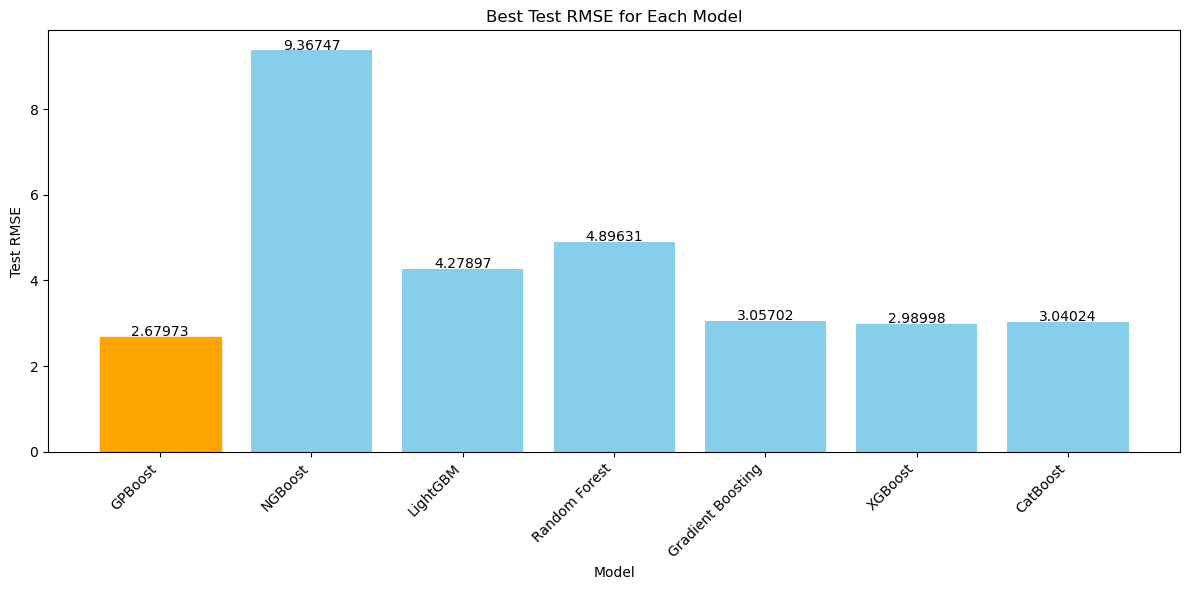

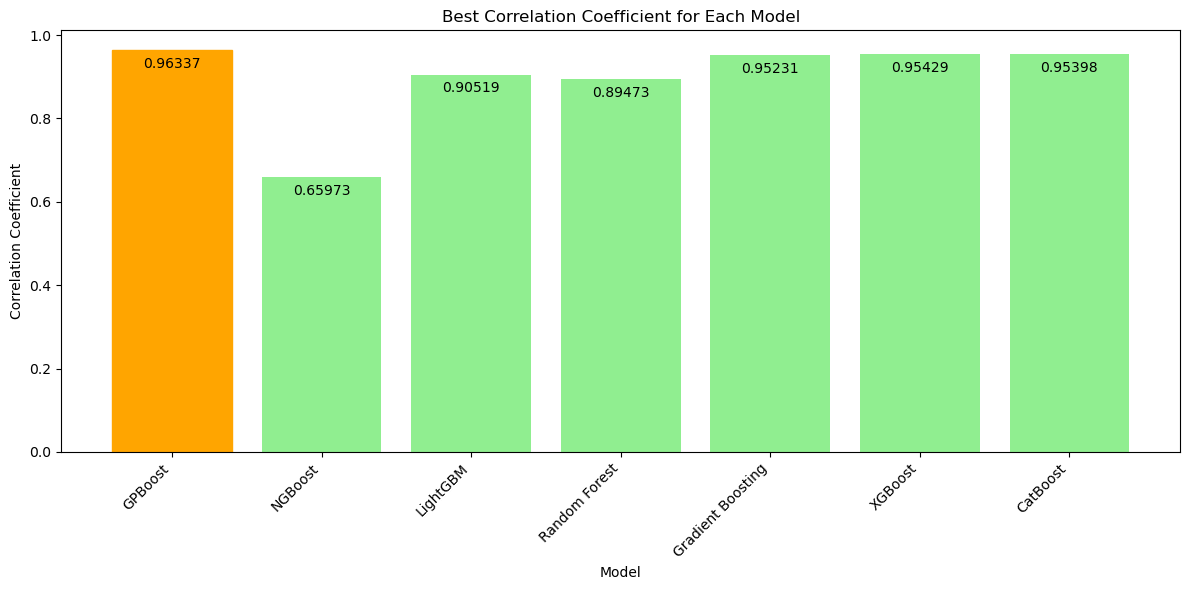

In [38]:
plot_best_scores_without_pruners(best_scores_nsga_iii_sampler)

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

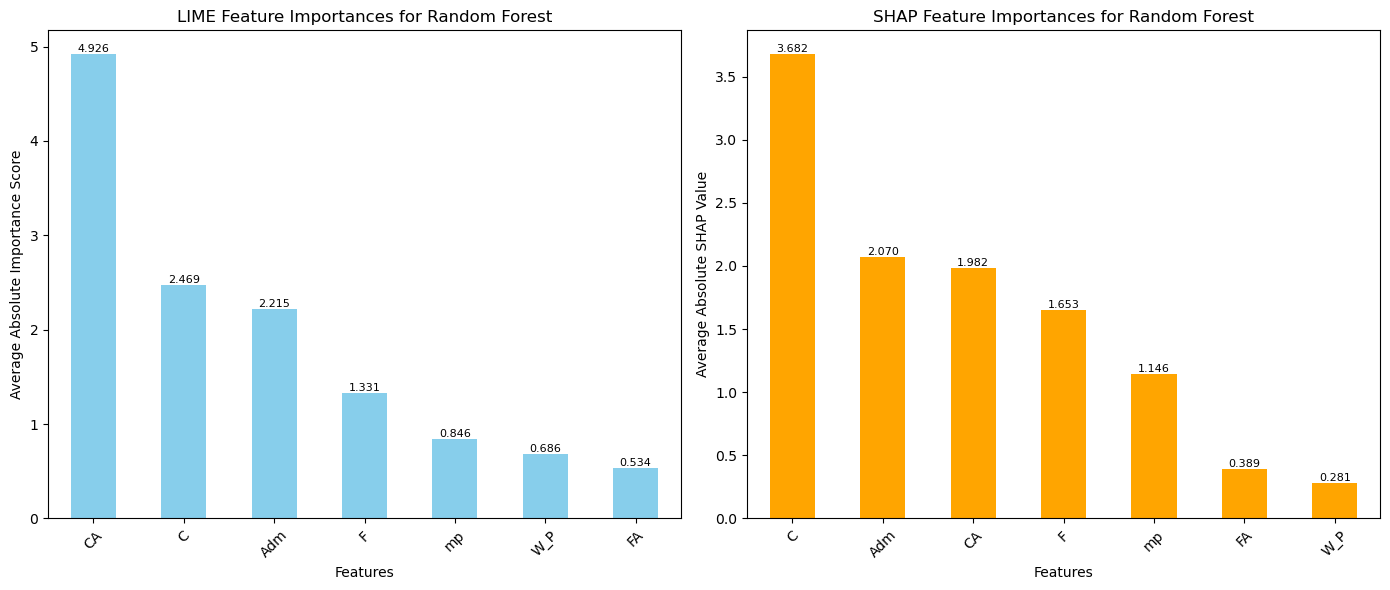

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

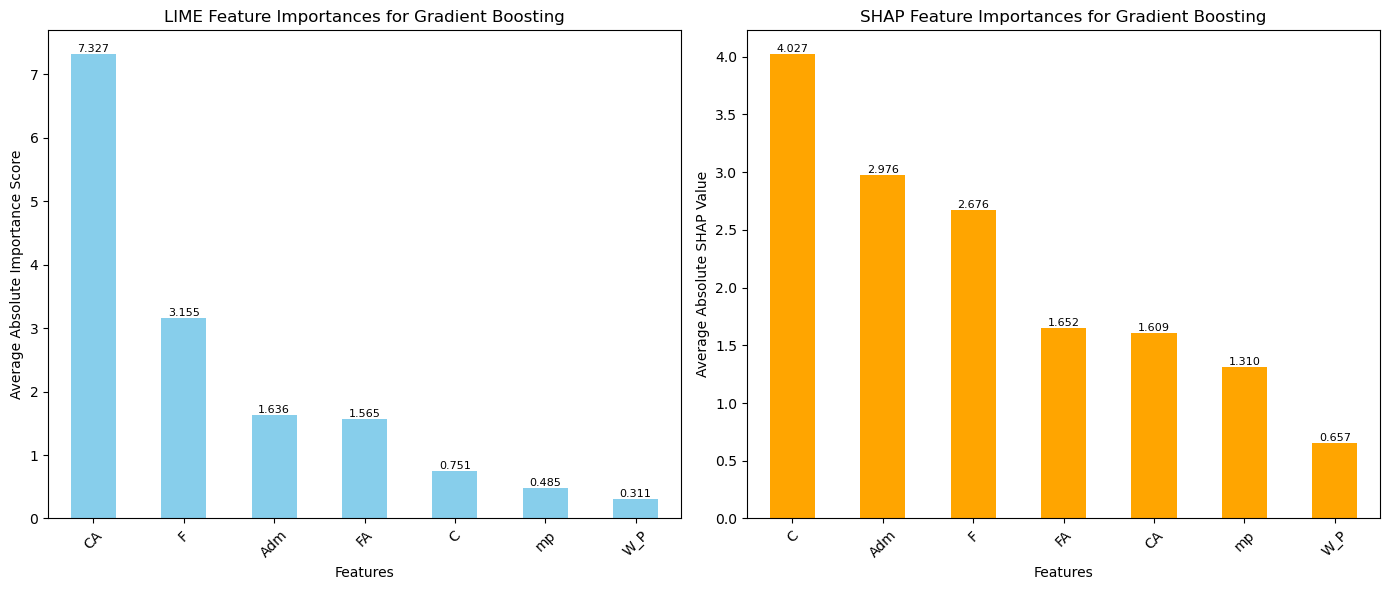

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

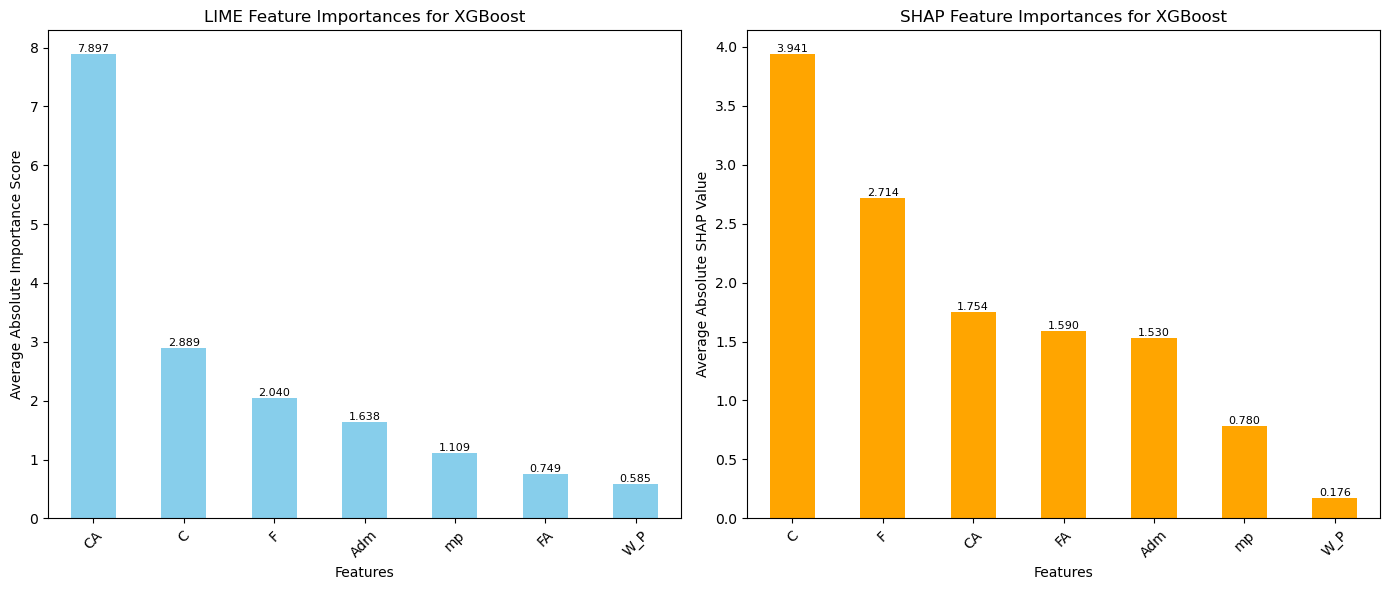

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

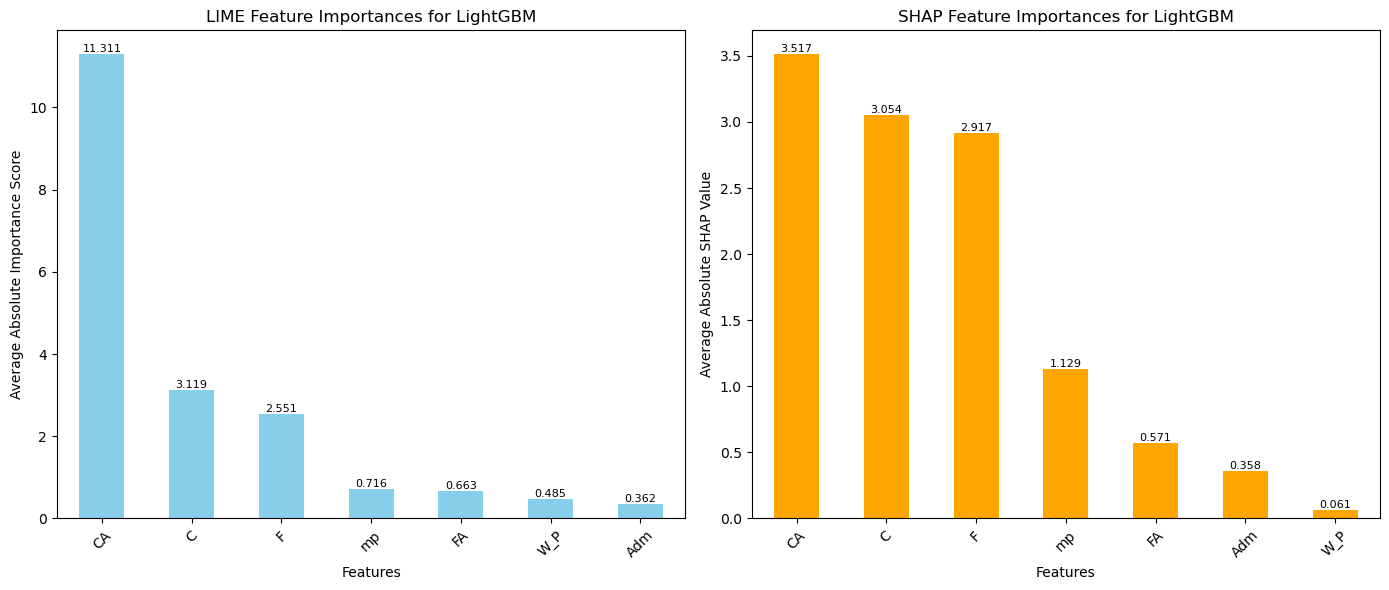

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.5. Current value: lambda_l2=0.5


Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

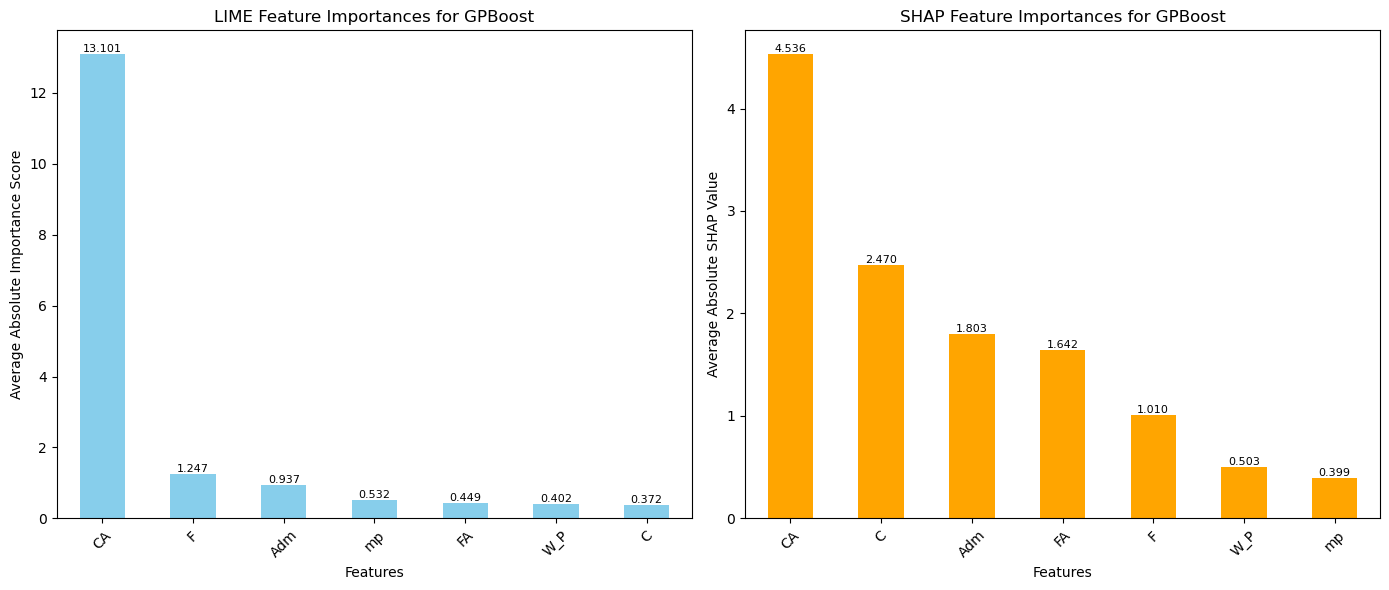

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

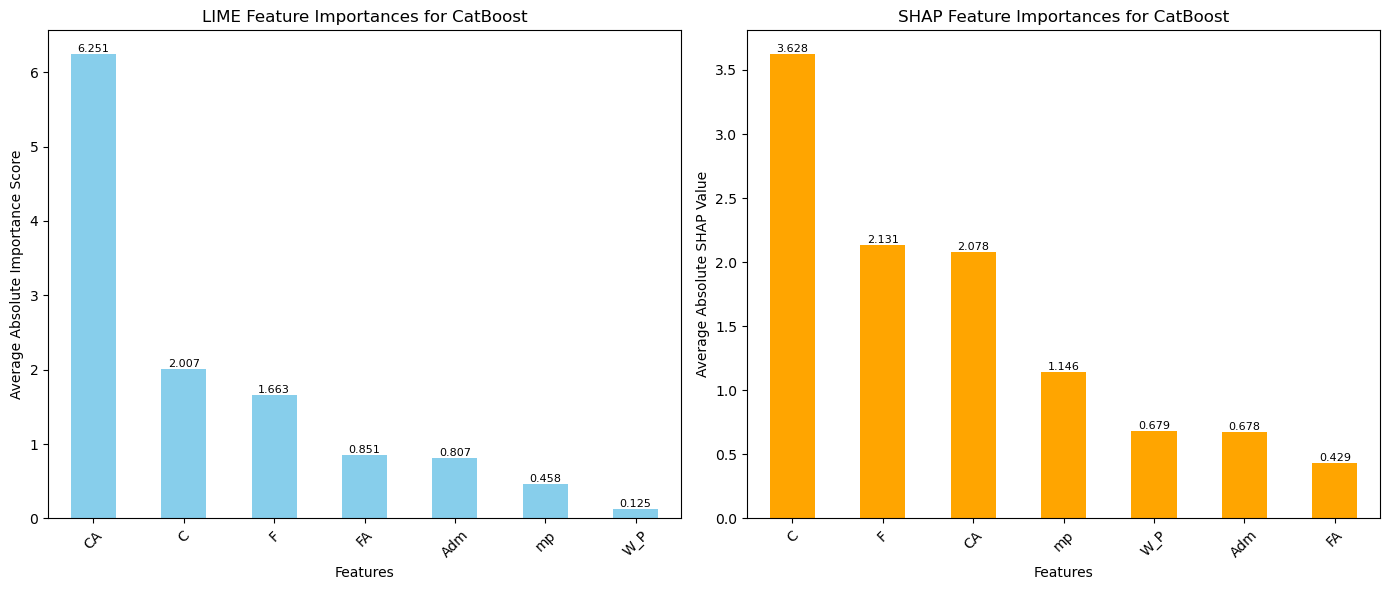

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

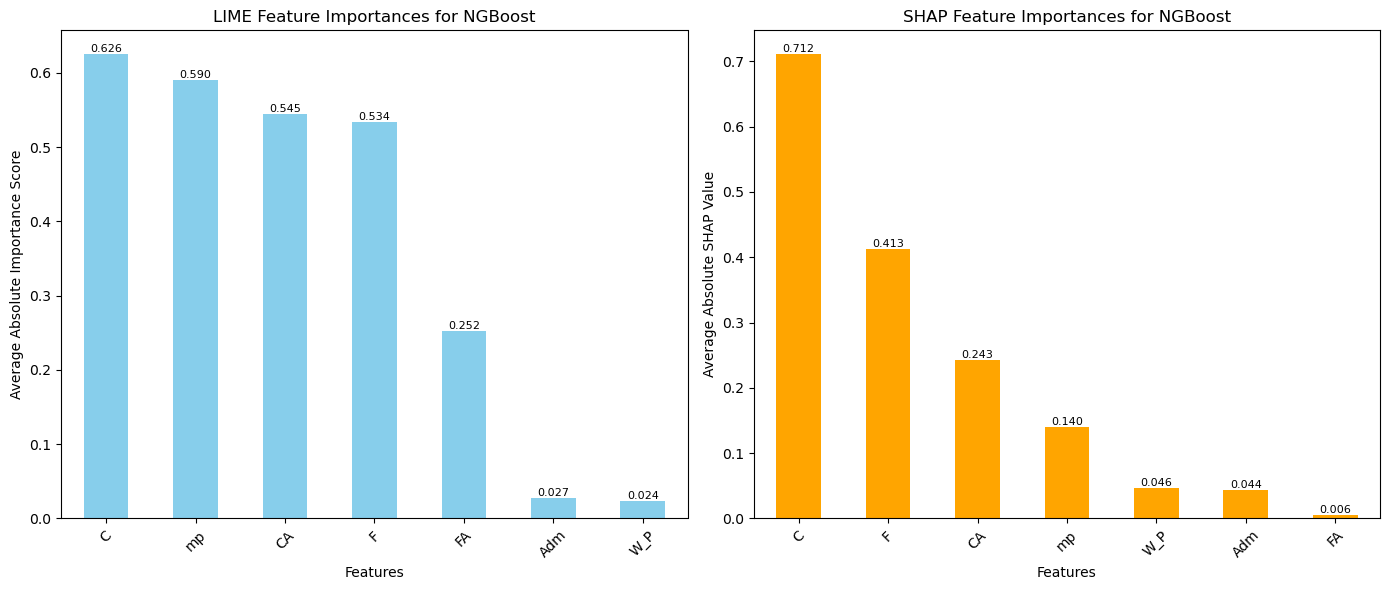

In [39]:
generate_interpretml_explanations_summary(best_scores_nsga_iii_sampler, X_train, y_train, x_test, feature_names)

# **QMCSampler using optuna**

In [40]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.ERROR)

def hyperparameter_tuning_qmc(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space):
        # Suggest hyperparameters
        params = {}
        for key, values in param_space.items():
            if isinstance(values, list):
                # Use suggest_categorical for categorical choices
                params[key] = trial.suggest_categorical(key, values)
            elif isinstance(values, tuple) and all(isinstance(v, int) for v in values):
                # Use suggest_int for integer ranges
                params[key] = trial.suggest_int(key, *values)
            else:
                # Use suggest_float for float ranges
                params[key] = trial.suggest_float(key, *values)

        # Create a new instance of the model
        model = model_class()
        model.set_params(**params)

        # Ensure the input arrays are writable
        X_train_copy = np.array(X_train, copy=True)
        y_train_copy = np.array(y_train, copy=True)
        X_test_copy = np.array(X_test, copy=True)
        y_test_copy = np.array(y_test, copy=True)

        # Train model
        start_time = time.time()
        model.fit(X_train_copy, y_train_copy)
        training_time = time.time() - start_time

        # Predict
        y_pred = model.predict(X_test_copy)

        # Calculate MSE
        mse = mean_squared_error(y_test_copy, y_pred)

        # Return both objectives: MSE and training time
        return mse, training_time

    models = {
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'verbose': [-1]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0],
            'verbose': [-1]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'iterations': [100, 200, 300, 400, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128],
            'verbose': [0]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7],
            'verbose': [0]
        })
    }
    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        print(f"Running Optuna for {model_name} with QMCSampler...")
        try:
            # Use the QMCSampler in the study creation
            sampler = QMCSampler()
            study = optuna.create_study(directions=['minimize', 'minimize'], sampler=sampler)
            study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)
            
            best_trial = study.best_trials[0]
            best_params = best_trial.params
            best_model = model_class().set_params(**best_params)
            best_model.fit(X_train, y_train)
            y_pred = best_model.predict(X_test)

            # Calculate MSE and RMSE
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)

            # Calculate Correlation Coefficient
            numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
            denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
            corr_coef = numerator / denominator if denominator != 0 else 0.0

            best_scores[model_name] = {
                'best_score': mse,
                'best_params': best_params,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {best_params}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run Optuna for {model_name}. Error: {e}")

    # Find the model with the best MSE on test data
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_qmc_sampler = hyperparameter_tuning_qmc(X_train, y_train, X_test, y_test)

Running Optuna for Random Forest with QMCSampler...
Best MSE for Random Forest: 13.686987994659583 with params: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 3}
Best RMSE for Random Forest: 3.6995929498607794
Correlation Coefficient for Random Forest: 0.9351892171336784
Running Optuna for Gradient Boosting with QMCSampler...
Best MSE for Gradient Boosting: 13.640946780171479 with params: {'n_estimators': 100, 'learning_rate': 0.15, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 1}
Best RMSE for Gradient Boosting: 3.6933652378517183
Correlation Coefficient for Gradient Boosting: 0.9298616581283056
Running Optuna for XGBoost with QMCSampler...
Best MSE for XGBoost: 9.875995289163464 with params: {'learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 100, 'min_child_weight': 3, 'gamma': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.9}
Best RMSE for XGBoost: 3.14260963041283
Correlation Coefficient for 

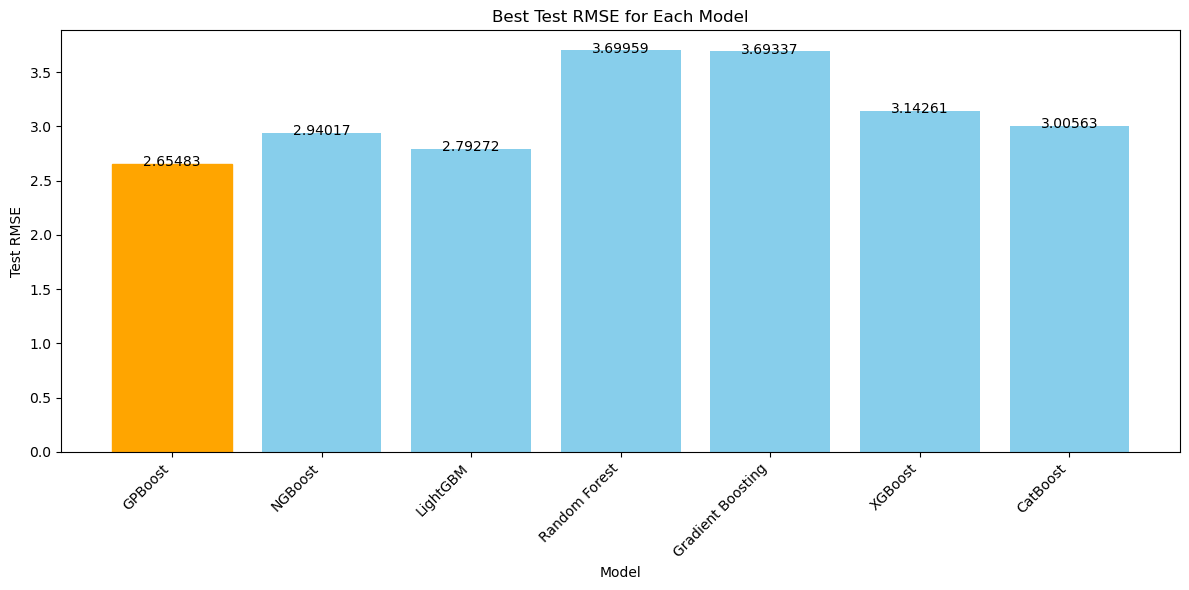

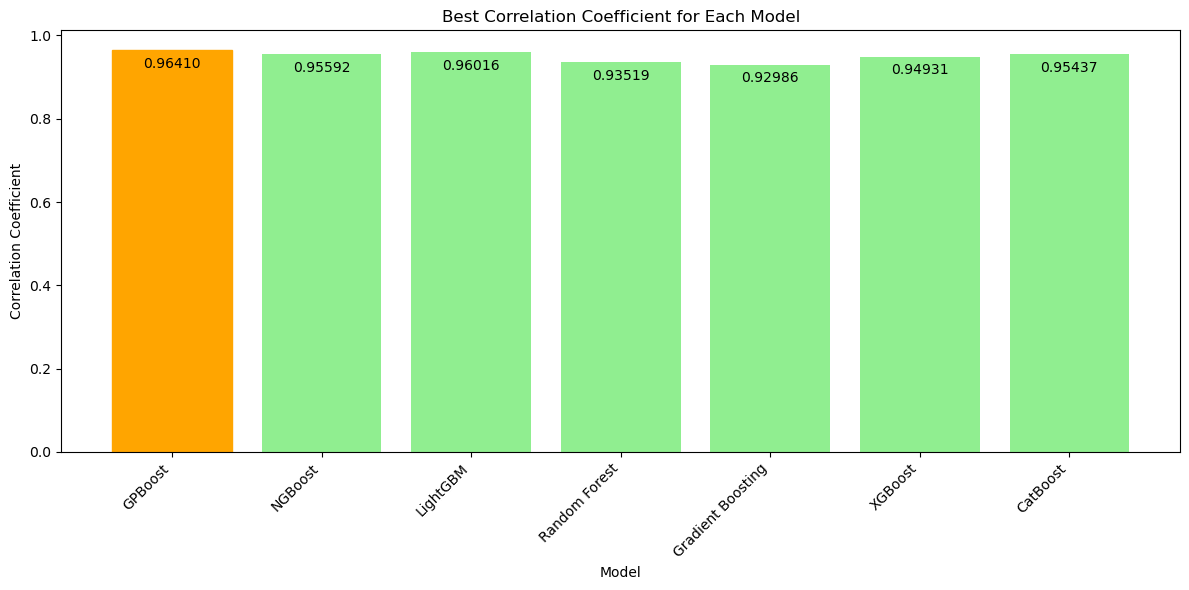

In [41]:
plot_best_scores_without_pruners(best_scores_qmc_sampler)

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

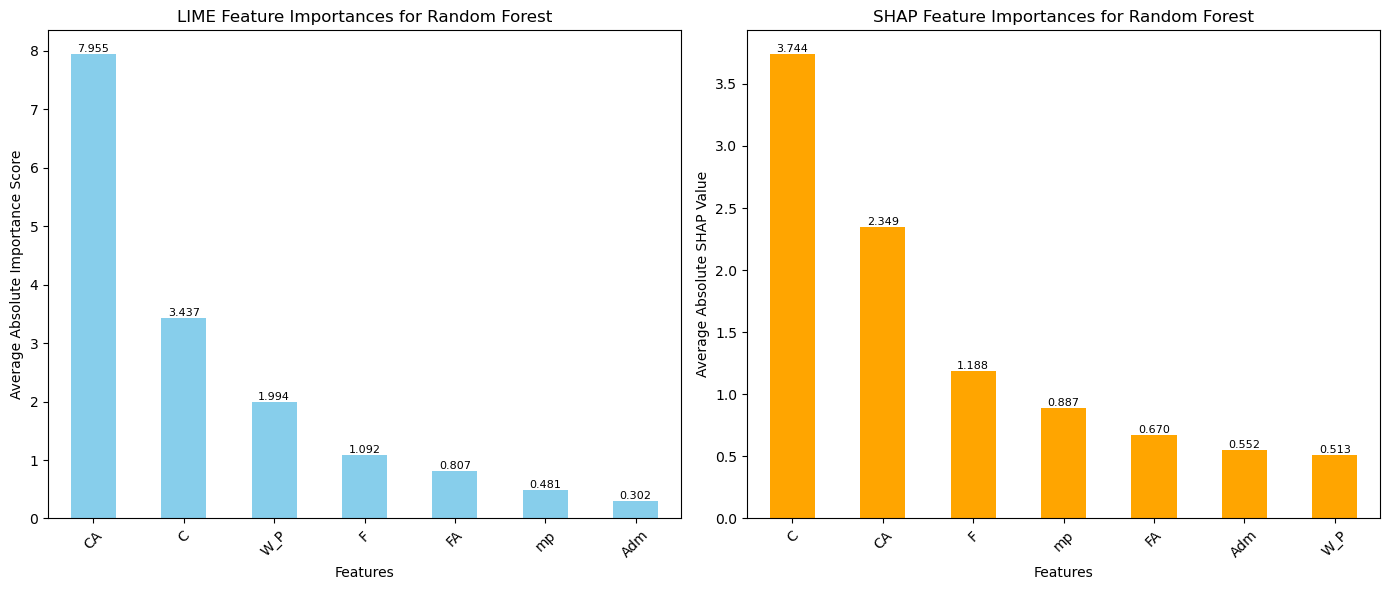

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

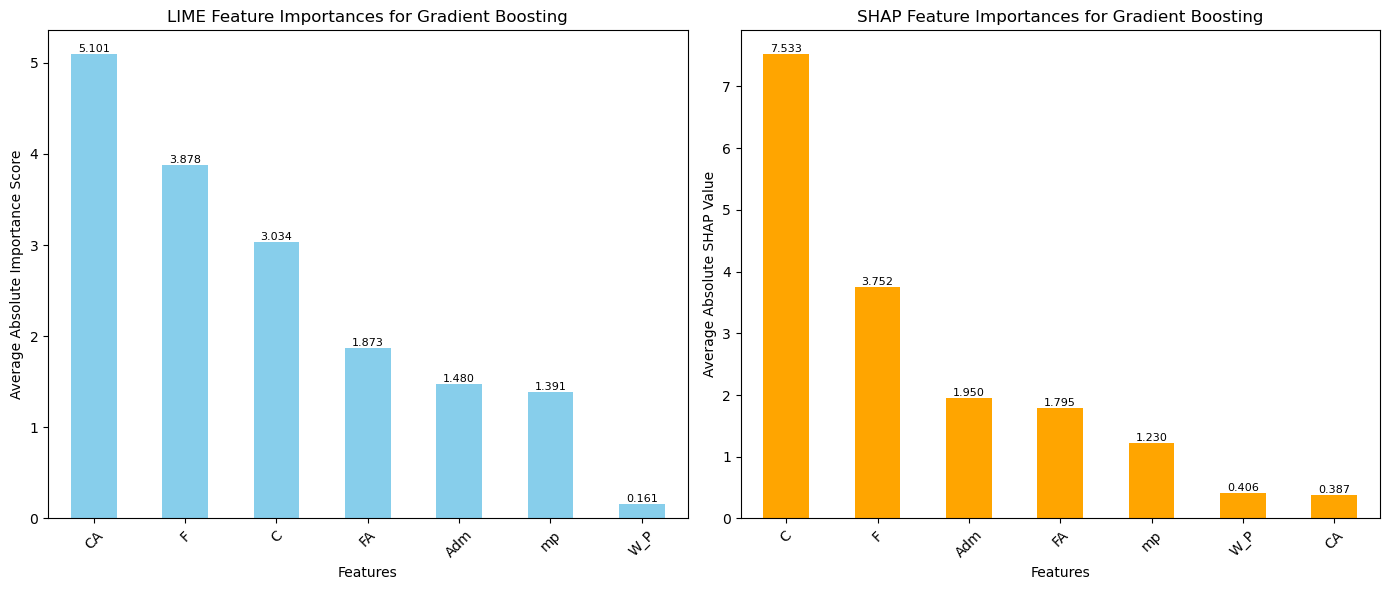

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

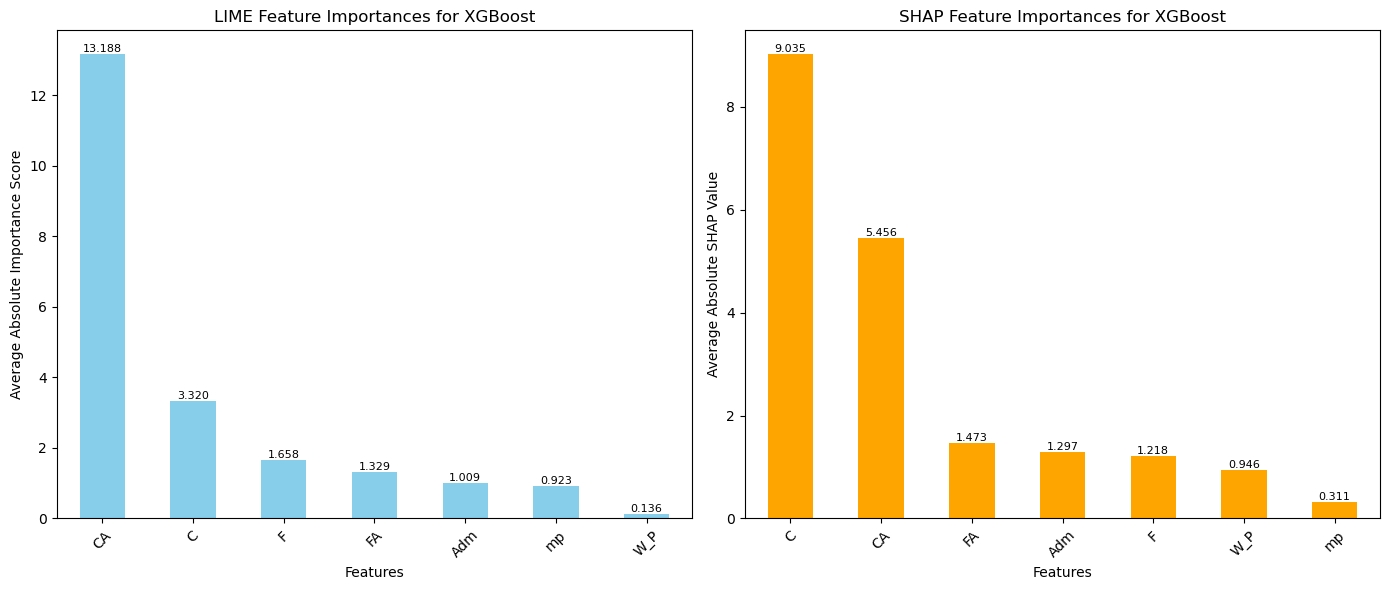

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

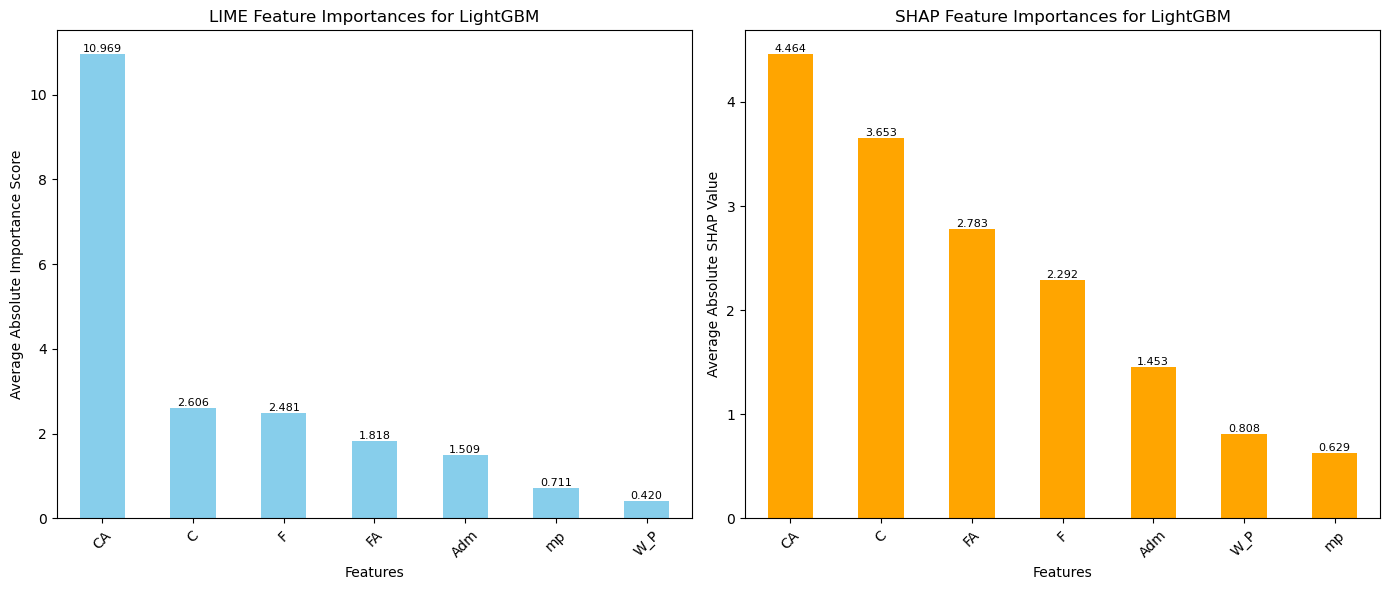

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.5. Current value: lambda_l2=0.5


Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

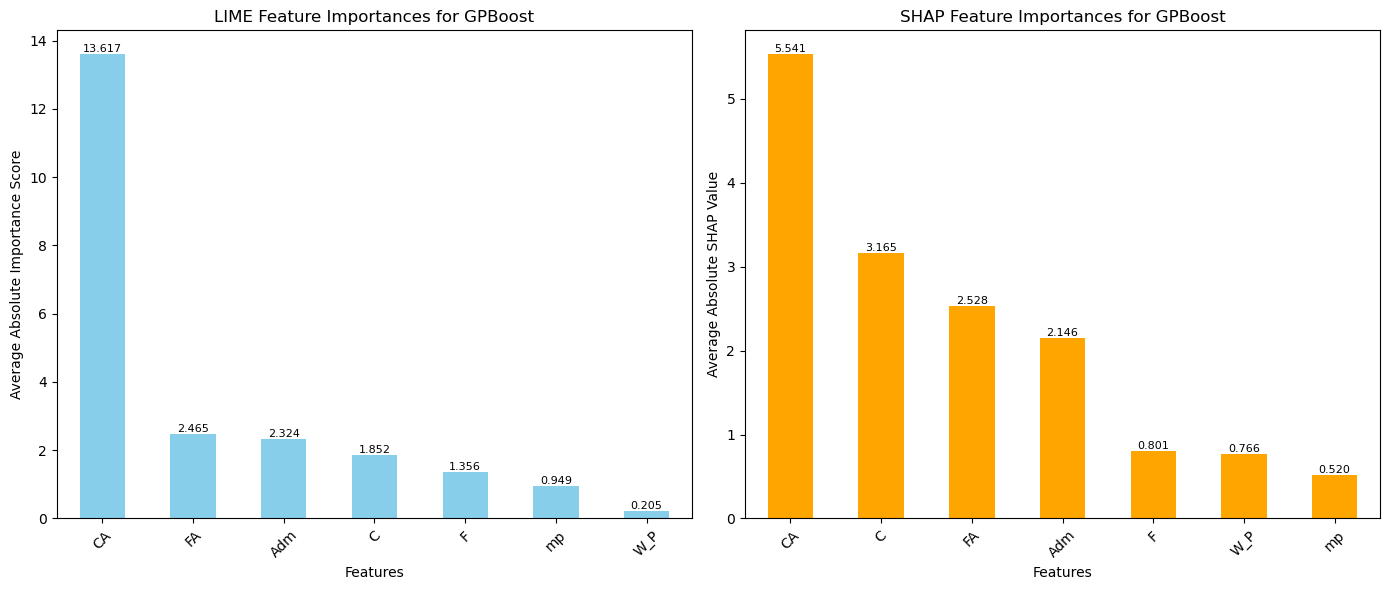

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

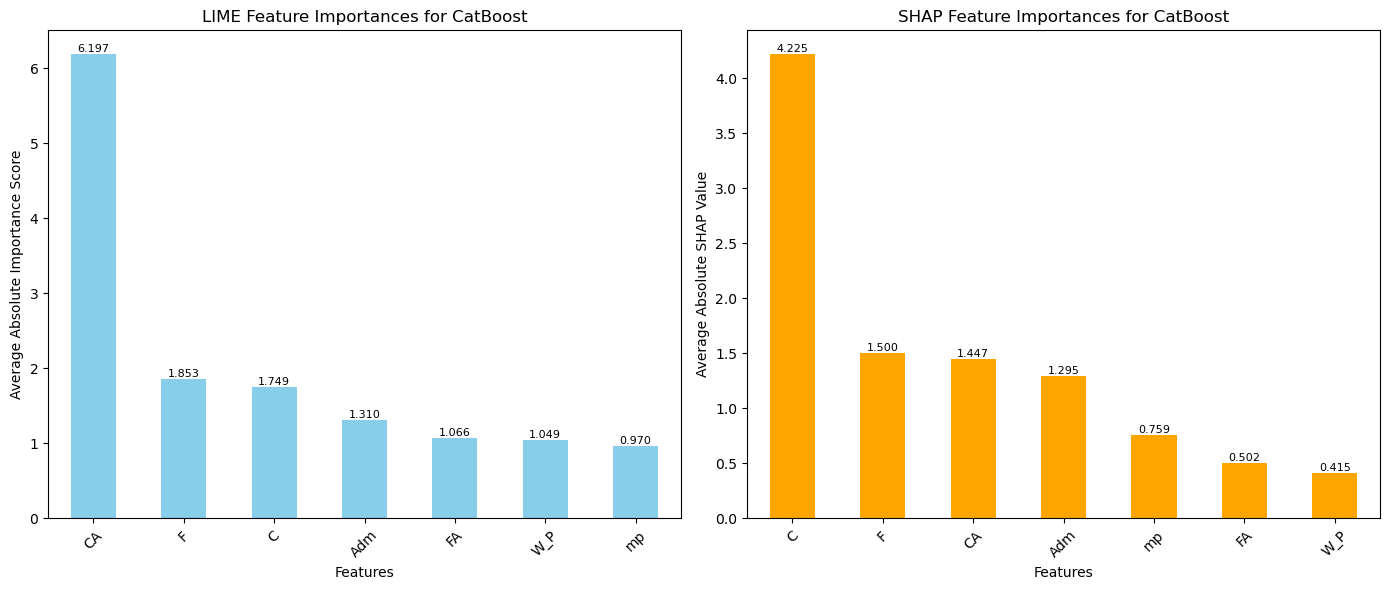

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

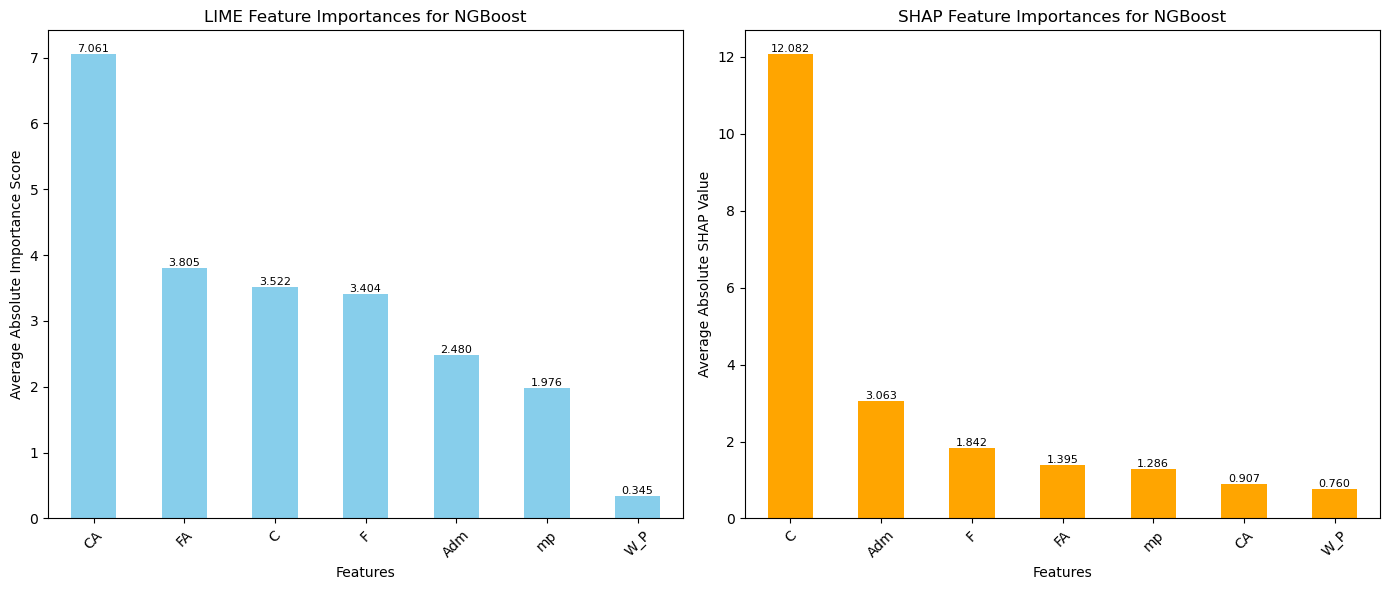

In [42]:
generate_interpretml_explanations_summary(best_scores_qmc_sampler, X_train, y_train, x_test, feature_names)

# **BruteForceSampler using optuna**

In [43]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def hyperparameter_tuning_brute_force(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space):
        # Suggest hyperparameters with finite search space
        params = {}
        for key, values in param_space.items():
            if isinstance(values, list):
                params[key] = trial.suggest_categorical(key, values)
            else:
                # Ensure a finite search space by specifying a step
                params[key] = trial.suggest_float(key, *values, step=0.1)

        # Create a new instance of the model
        model = model_class()
        model.set_params(**params)

        # Train model
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Calculate MSE
        mse = mean_squared_error(y_test, y_pred)

        return mse

    models = {
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'verbose': [-1]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0],
            'verbose': [-1]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'iterations': [100, 200, 300, 400, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128],
            'verbose': [0]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7],
            'verbose': [0]
        })
    }

    pruners = [
        optuna.pruners.MedianPruner(),
        optuna.pruners.NopPruner(),
        optuna.pruners.PatientPruner(optuna.pruners.MedianPruner(), patience=3),
        optuna.pruners.PercentilePruner(25.0),
        optuna.pruners.SuccessiveHalvingPruner(),
        optuna.pruners.HyperbandPruner(),
        optuna.pruners.ThresholdPruner(lower=0.1),
        optuna.pruners.WilcoxonPruner()
    ]

    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        for pruner in pruners:
            pruner_name = pruner.__class__.__name__
            print(f"Running Optuna for {model_name} with {pruner_name} and BruteForceSampler...")
            try:
                # Use the BruteForceSampler and pruner in the study creation
                sampler = BruteForceSampler()
                study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
                study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)
                
                best_trial = study.best_trial
                best_params = best_trial.params
                best_model = model_class().set_params(**best_params)
                best_model.fit(X_train, y_train)
                y_pred = best_model.predict(X_test)

                # Calculate MSE and RMSE
                mse = mean_squared_error(y_test, y_pred)
                rmse = np.sqrt(mse)

                # Calculate Correlation Coefficient
                numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
                denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
                corr_coef = numerator / denominator if denominator != 0 else 0.0

                best_scores[(model_name, pruner_name)] = {
                    'best_score': mse,
                    'best_params': best_params,
                    'test_mse': mse,
                    'test_rmse': rmse,
                    'test_corr_coef': corr_coef,
                    'pruner': pruner_name
                }
                print(f"Best MSE for {model_name} with {pruner_name}: {mse} with params: {best_params}")
                print(f"Best RMSE for {model_name} with {pruner_name}: {rmse}")
                print(f"Correlation Coefficient for {model_name} with {pruner_name}: {corr_coef}")
            except Exception as e:
                print(f"Failed to run Optuna for {model_name} with {pruner_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name, best_pruner_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[(best_model_name, best_pruner_name)]
        print(f"\nBest model on test data: {best_model_name} with {best_pruner_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
        print(f"Pruner Used: {best_model_info['pruner']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_brute_force = hyperparameter_tuning_brute_force(X_train, y_train, X_test, y_test)

Running Optuna for Random Forest with MedianPruner and BruteForceSampler...
Best MSE for Random Forest with MedianPruner: 11.47766638144502 with params: {'n_estimators': 500, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}
Best RMSE for Random Forest with MedianPruner: 3.387870478847298
Correlation Coefficient for Random Forest with MedianPruner: 0.9416798237923089
Running Optuna for Random Forest with NopPruner and BruteForceSampler...
Best MSE for Random Forest with NopPruner: 10.944944385143838 with params: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 3}
Best RMSE for Random Forest with NopPruner: 3.3083144326293774
Correlation Coefficient for Random Forest with NopPruner: 0.9459905337228781
Running Optuna for Random Forest with PatientPruner and BruteForceSampler...
Best MSE for Random Forest with PatientPruner: 11.336670259758849 with params: {'n_estimators': 200, 'max_depth': 15, 'min_samp

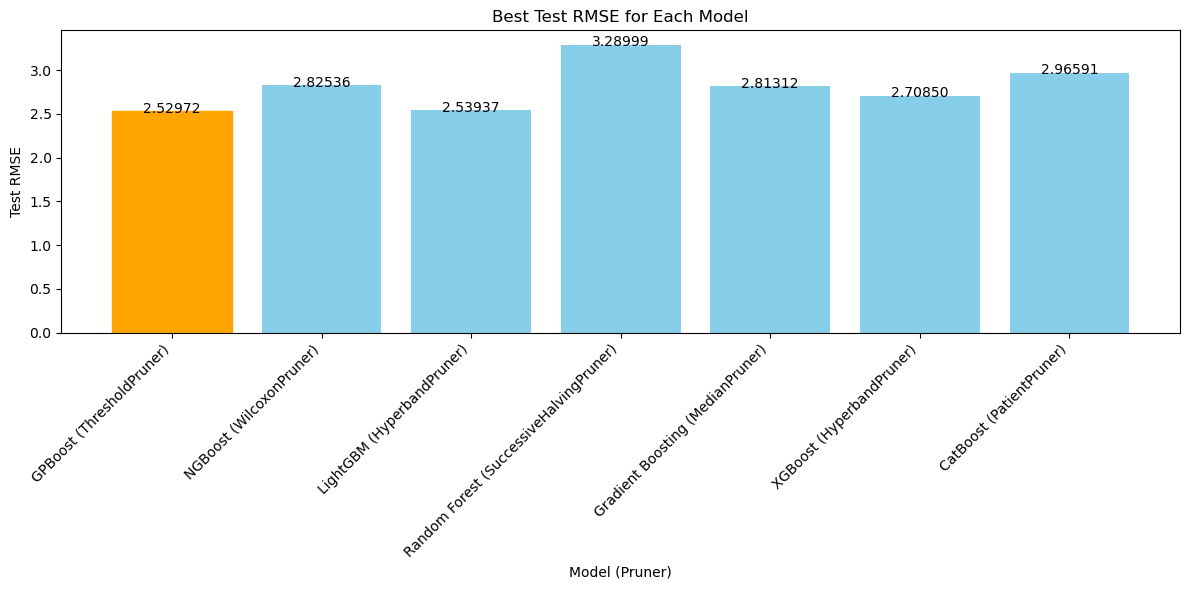

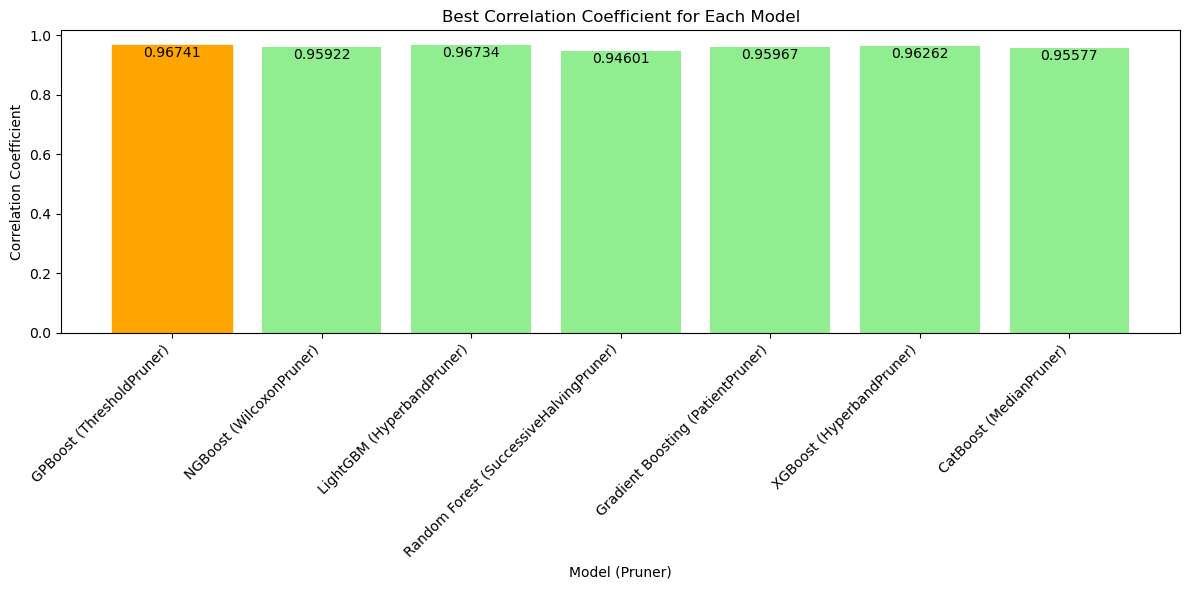

In [44]:
plot_best_scores(best_scores_brute_force)

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

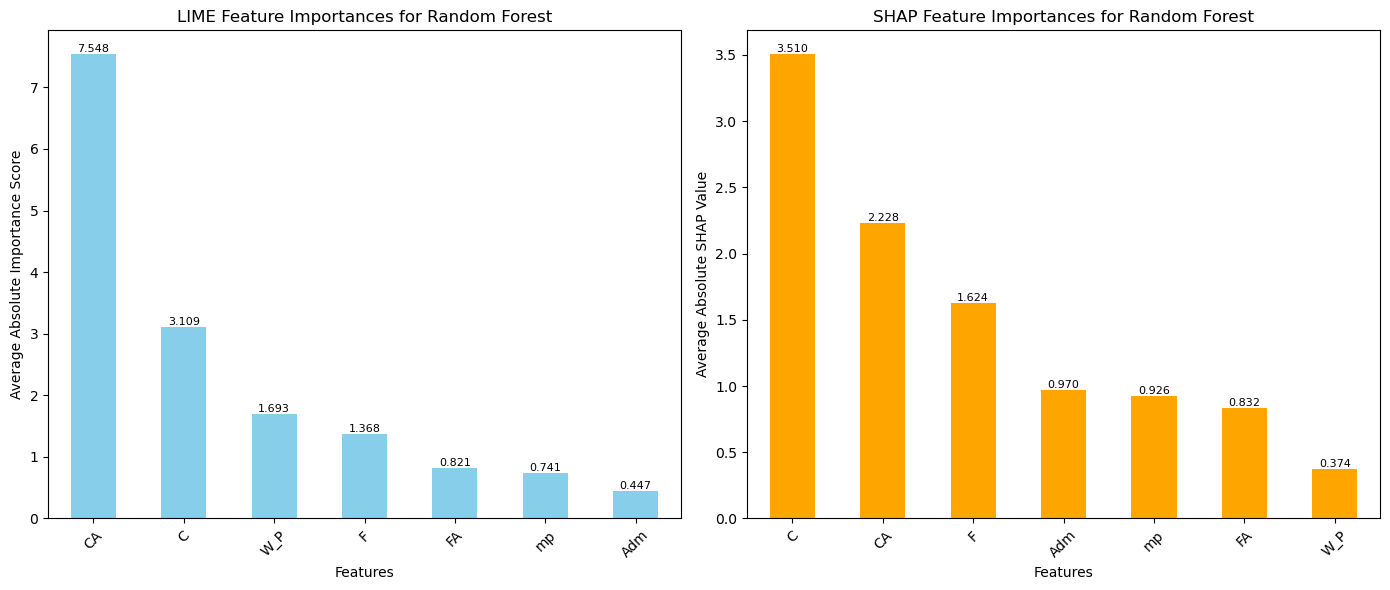

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

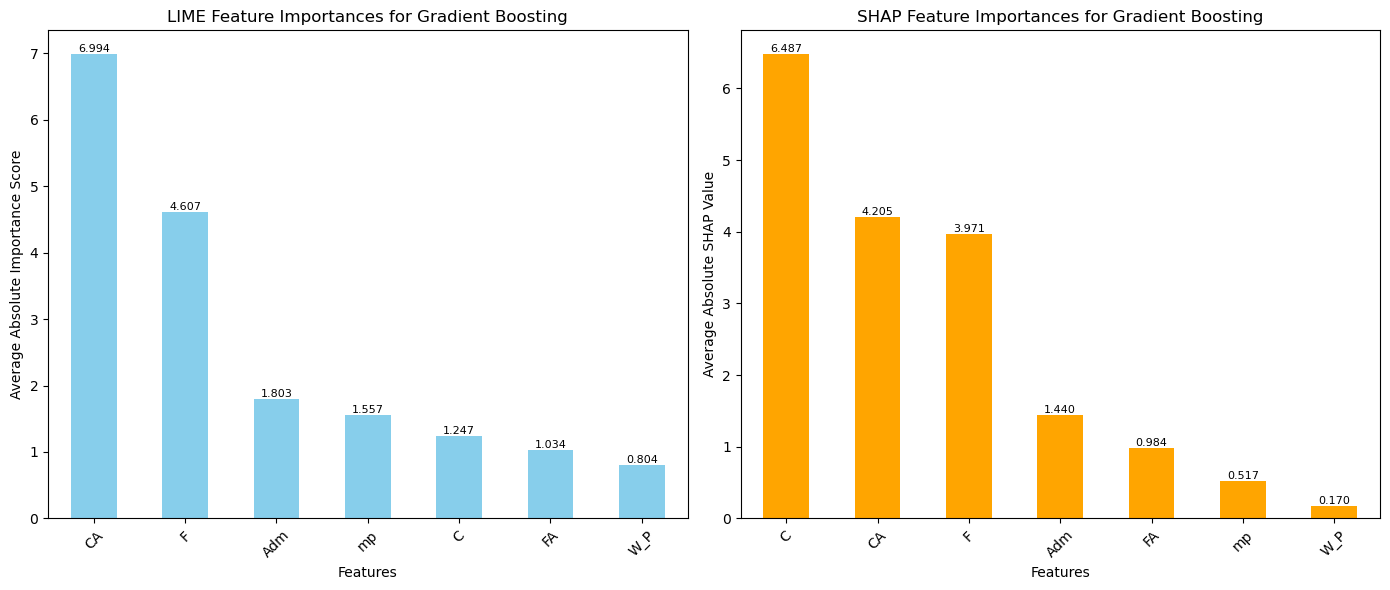

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

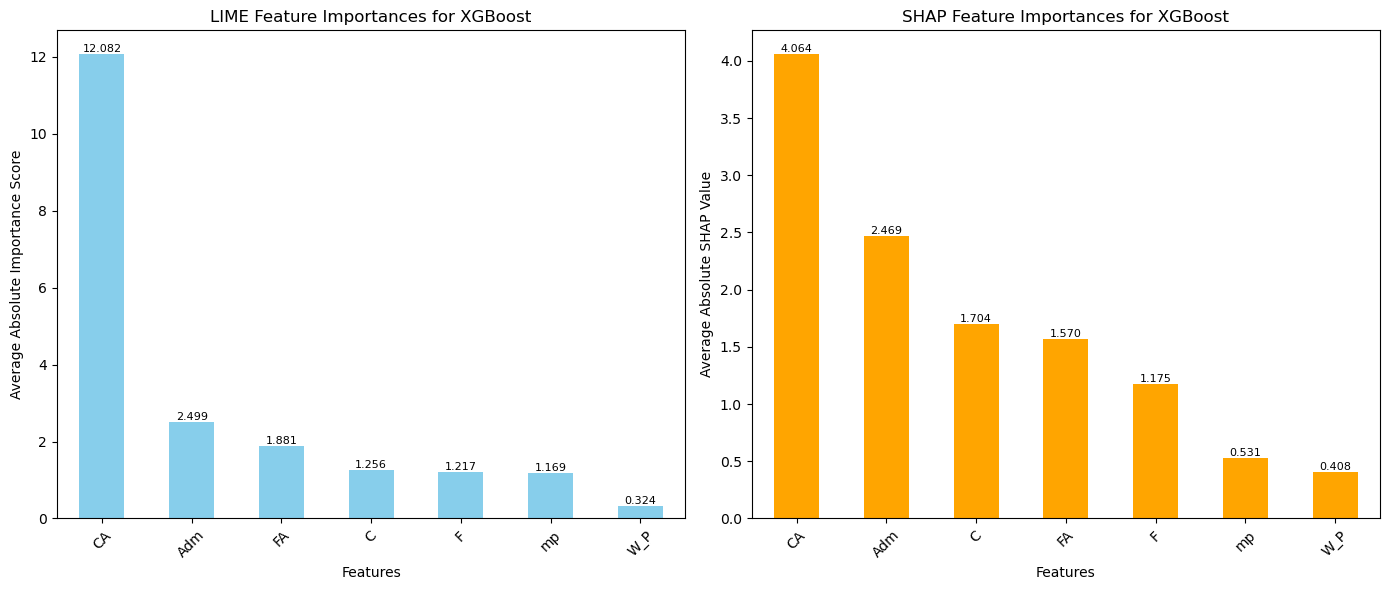

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

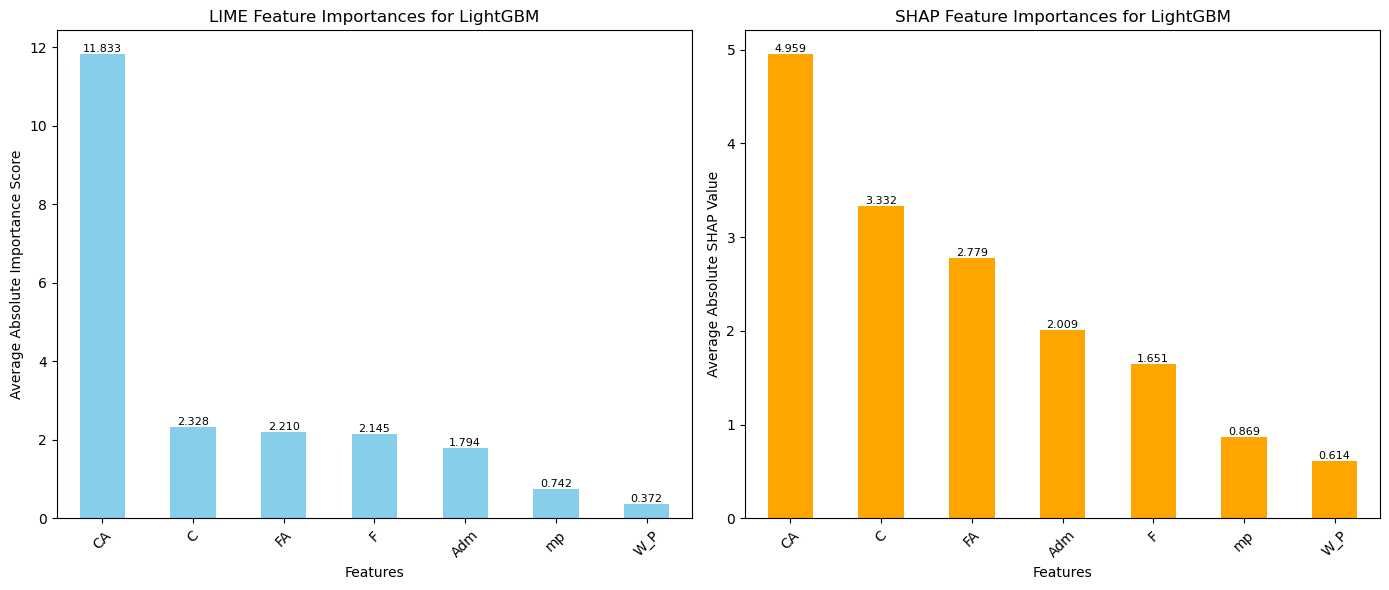

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.1. Current value: lambda_l2=0.1


Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

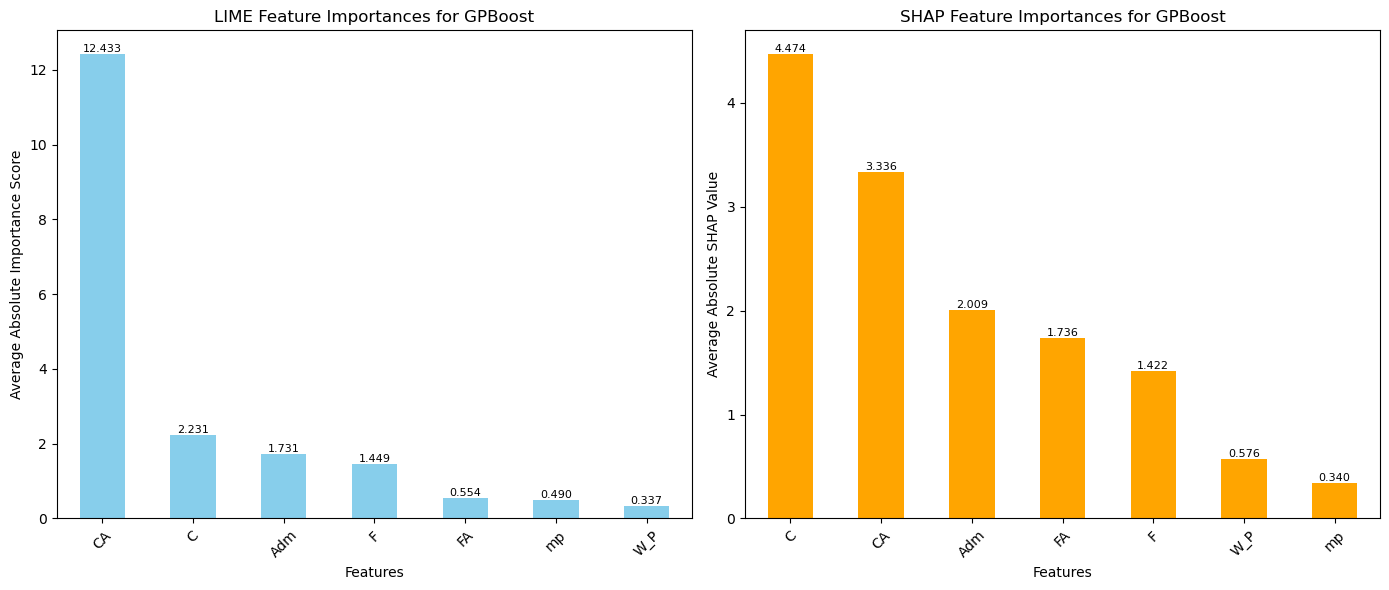

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

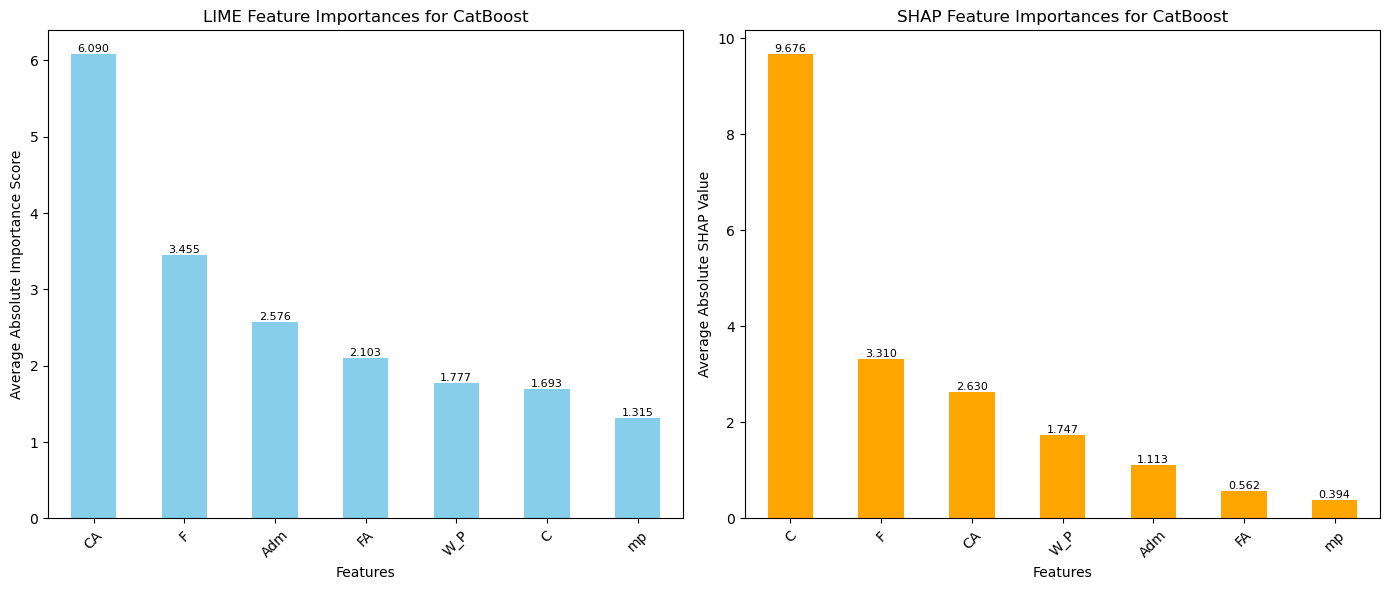

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

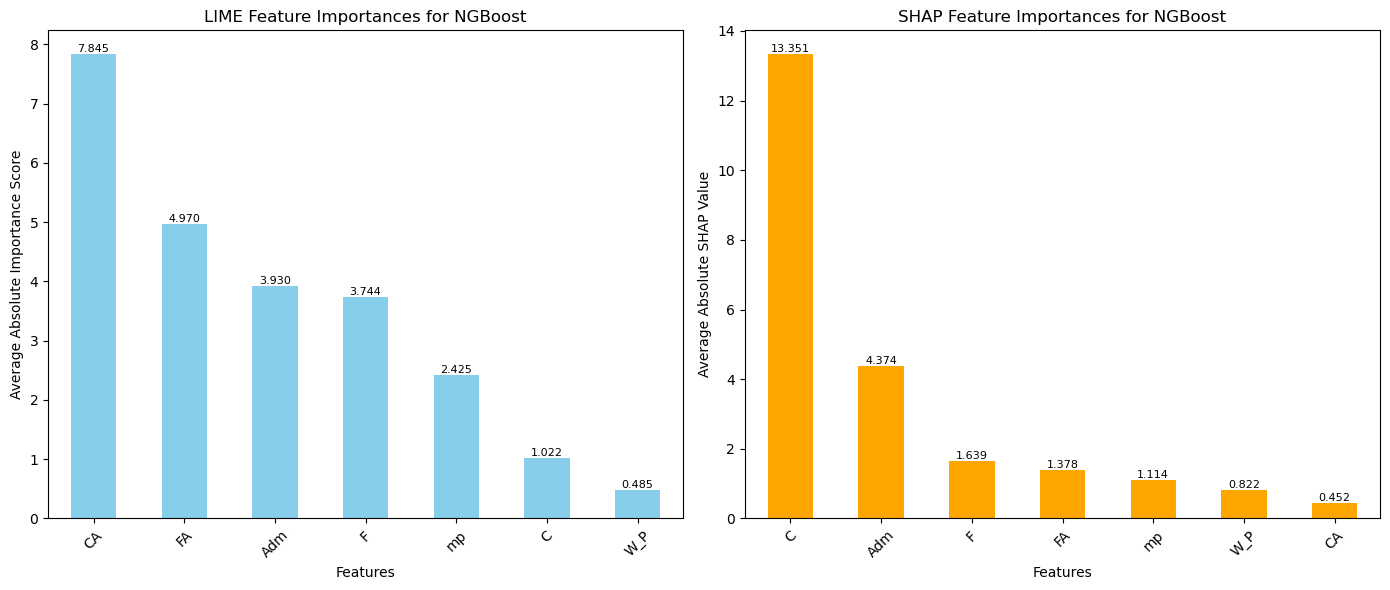

In [45]:
generate_interpretml_explanations_summary_pruners(best_scores_brute_force, X_train, y_train, x_test, feature_names)

# **Halving GridSearchCV**

In [46]:
def hyperparameter_tuning_halving_grid(X_train, y_train, X_test, y_test):
    models = {
        'Random Forest': (RandomForestRegressor(), {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'Gradient Boosting': (GradientBoostingRegressor(), {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1, 2, 3, 4, 5]
        }),
        'XGBoost': (XGBRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'verbose': [-1]
        }),
        'GPBoost': (GPBoostRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 400, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0],
            'verbose': [-1]
        }),
        'CatBoost': (CatBoostRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'iterations': [100, 200, 300, 400, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128],
            'verbose': [0]
        }),
        'NGBoost': (NGBRegressor(), {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7],
            'verbose': [0]
        })
    }

    best_scores = {}
    for model_name, (model, param_grid) in models.items():
        print(f"Running HalvingGridSearchCV for {model_name}...")
        try:
            search = HalvingGridSearchCV(
                estimator=model,
                param_grid=param_grid,
                cv=3,
                factor=2,  # Reduction factor at each iteration
                scoring='neg_mean_squared_error',
                n_jobs=-1,
                verbose=0
            )

            search.fit(X_train, y_train)
            best_model = search.best_estimator_
            y_pred = best_model.predict(X_test)

            # Calculate MSE
            mse = mean_squared_error(y_test, y_pred)

            # Calculate RMSE
            rmse = np.sqrt(mse)

            # Calculate correlation coefficient
            corr_coef = np.corrcoef(y_test, y_pred)[0, 1]

            best_scores[model_name] = {
                'best_score': -search.best_score_,
                'best_params': search.best_params_,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {search.best_params_}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run HalvingGridSearchCV for {model_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

# Example usage
best_scores_halving_grid = hyperparameter_tuning_halving_grid(X_train, y_train, X_test, y_test)

# Removing Warnings
warnings.filterwarnings('ignore', message='.*lambda_l2 is set with lambda.*')
warnings.filterwarnings('ignore', message='.*min_data_in_leaf is set.*')

Running HalvingGridSearchCV for Random Forest...
Best MSE for Random Forest: 11.467100856972456 with params: {'max_depth': None, 'max_features': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RMSE for Random Forest: 3.3863108033629246
Correlation Coefficient for Random Forest: 0.9444240049622534
Running HalvingGridSearchCV for Gradient Boosting...
Best MSE for Gradient Boosting: 10.067804002645994 with params: {'learning_rate': 0.15, 'max_depth': 3, 'max_features': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best RMSE for Gradient Boosting: 3.172980302908607
Correlation Coefficient for Gradient Boosting: 0.9483987995507727
Running HalvingGridSearchCV for XGBoost...
Best MSE for XGBoost: 8.642352754396299 with params: {'colsample_bytree': 0.5, 'gamma': 1, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.5}
Best RMSE for XGBoost: 2.9397878757482316
Correlation Coefficient for XGBoost:

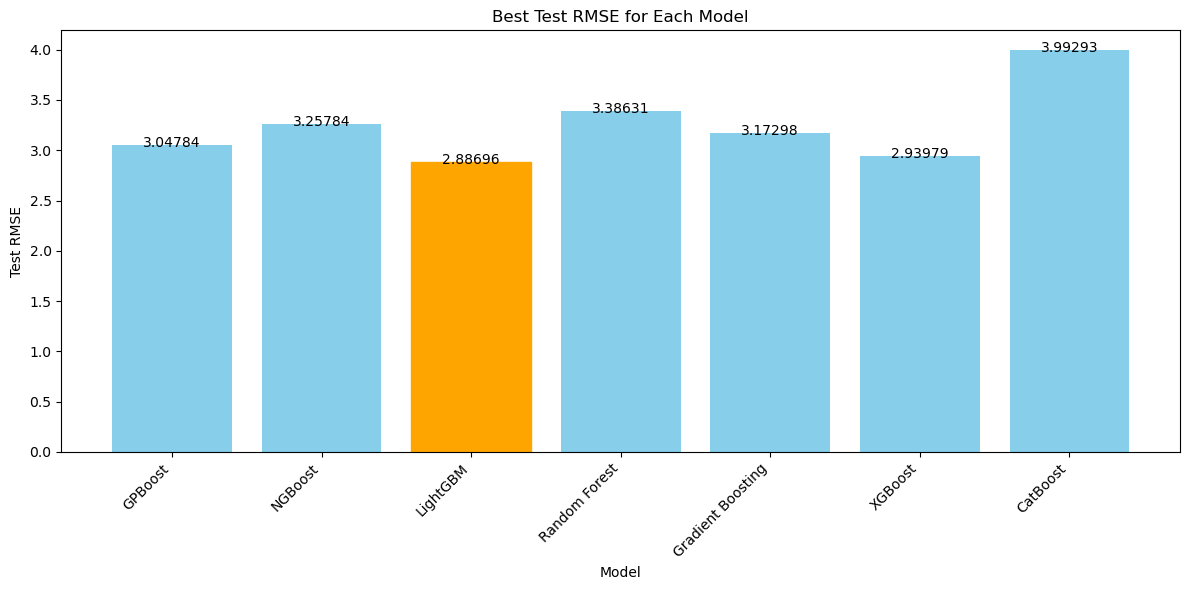

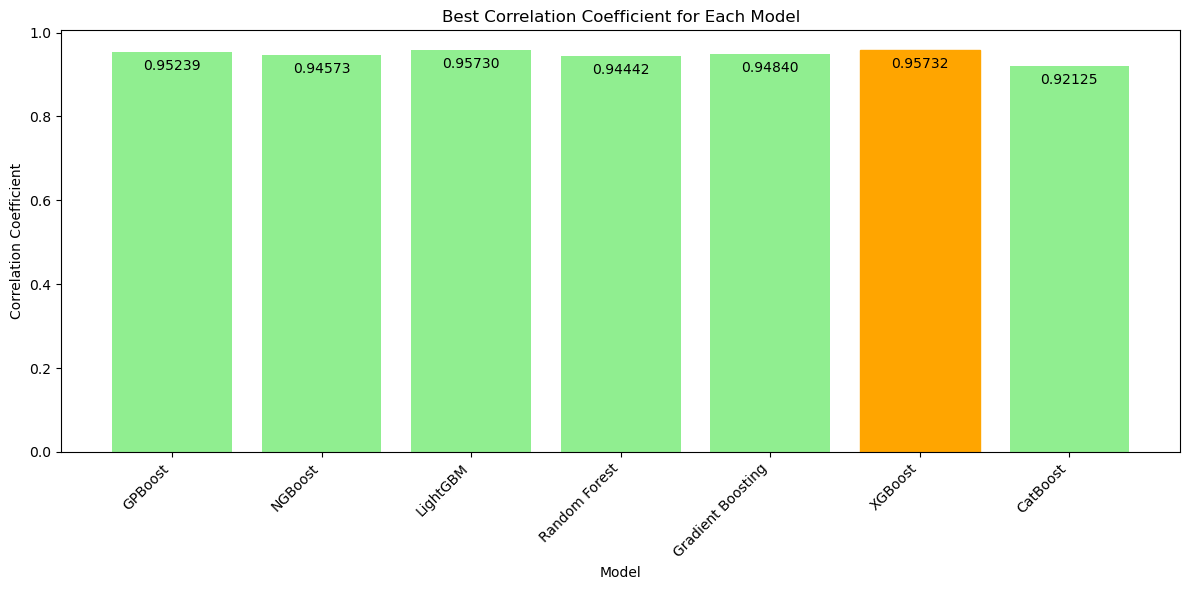

In [47]:
plot_best_scores_without_pruners(best_scores_halving_grid)

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

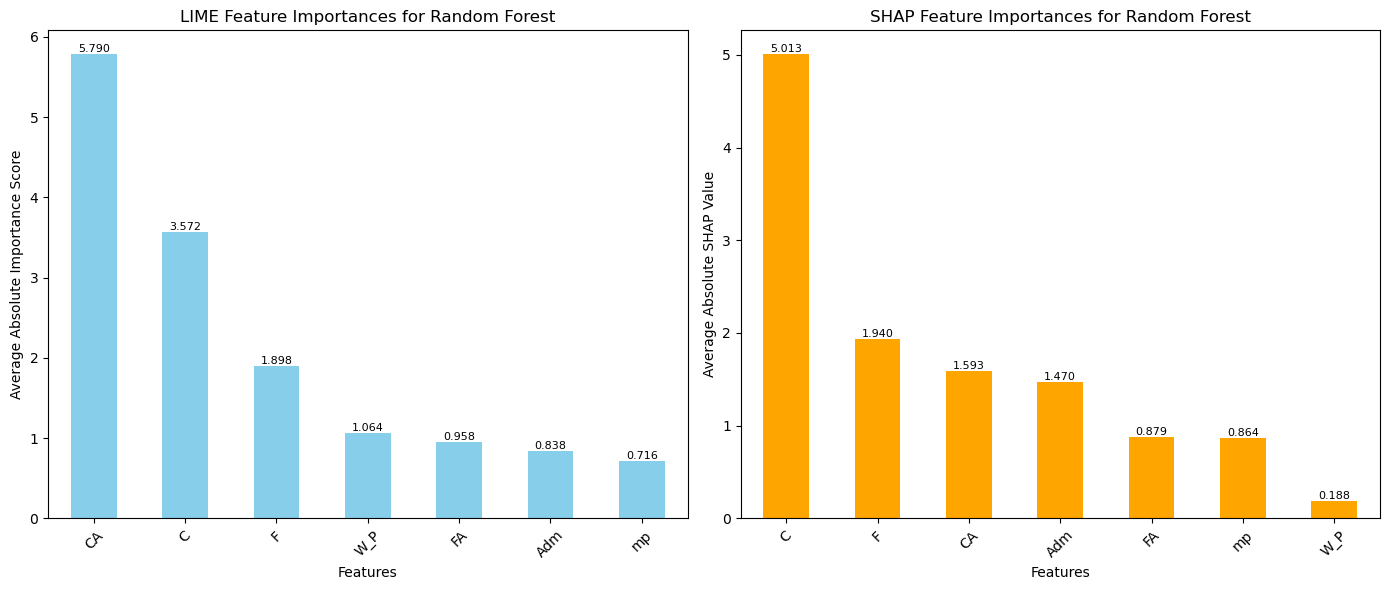

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

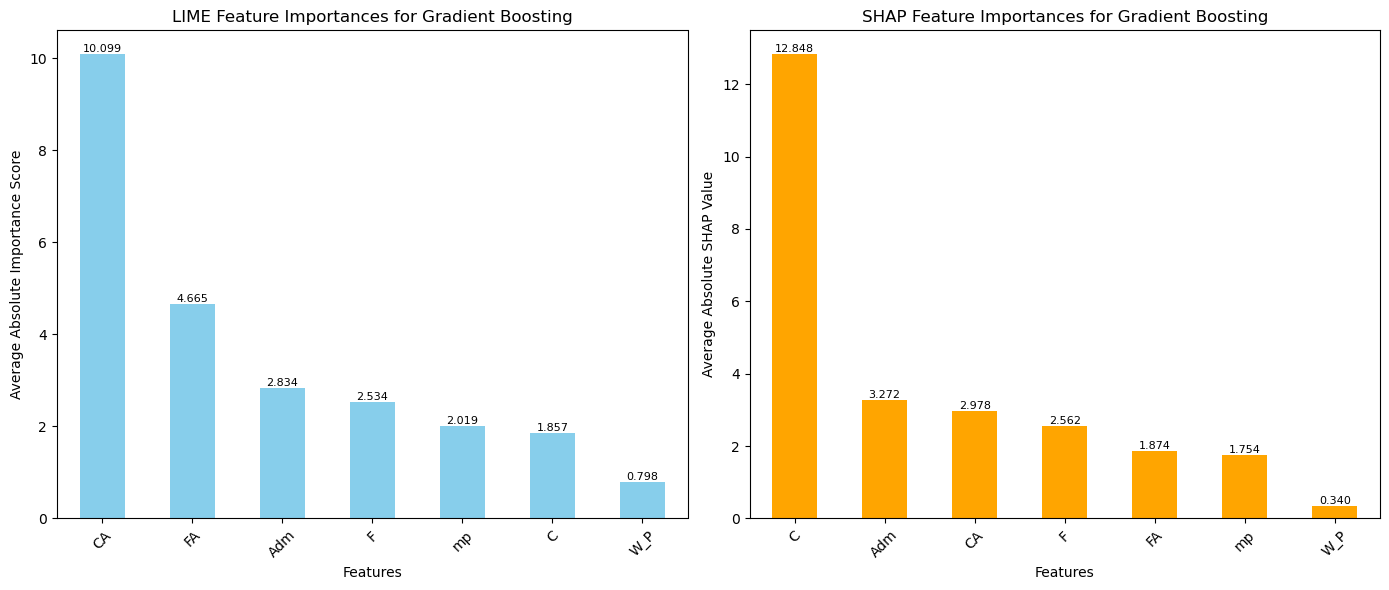

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

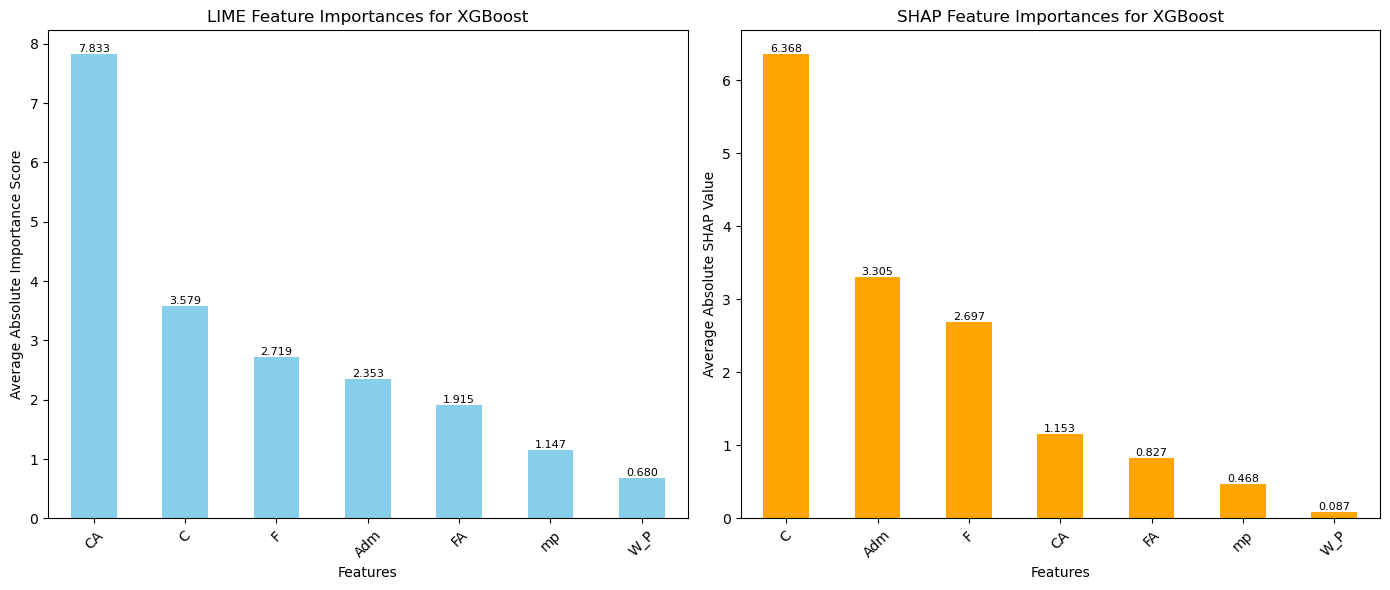

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

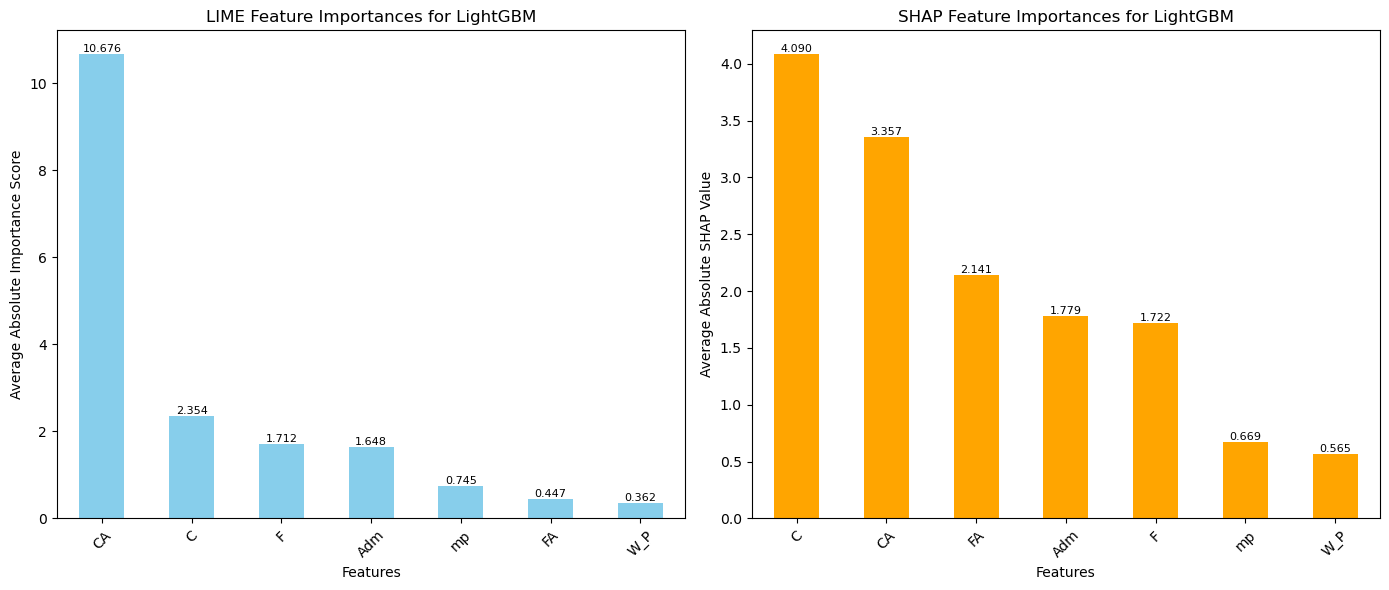

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.5. Current value: lambda_l2=0.5


Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

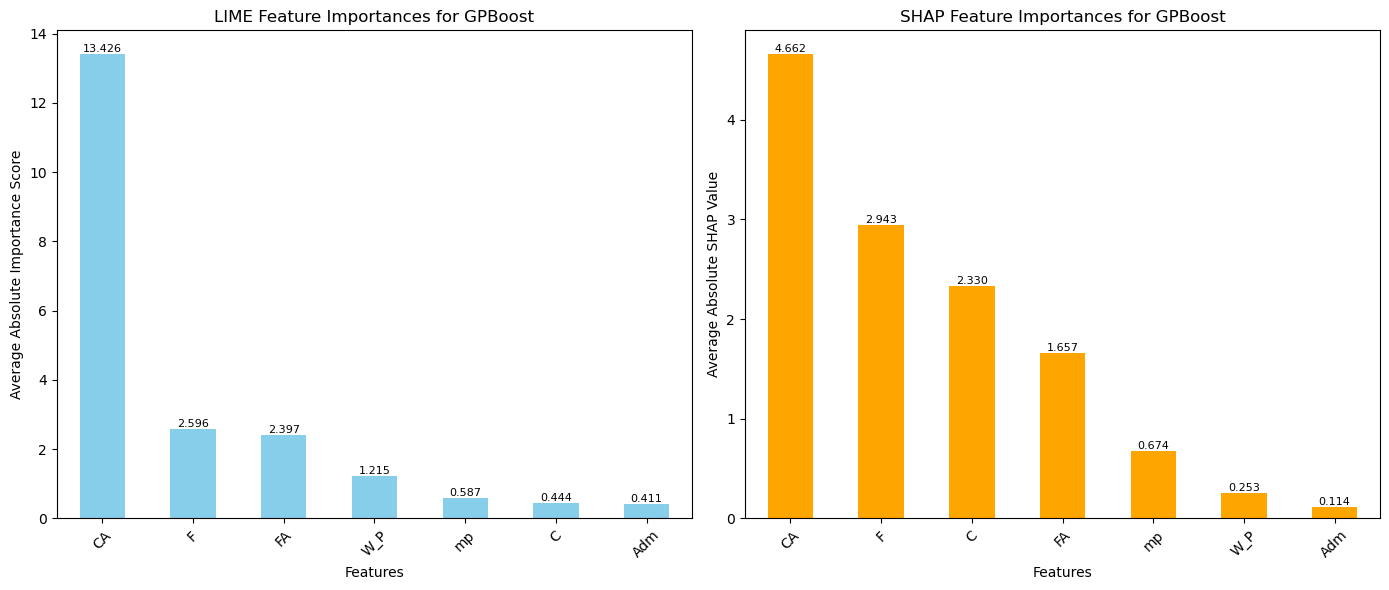

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

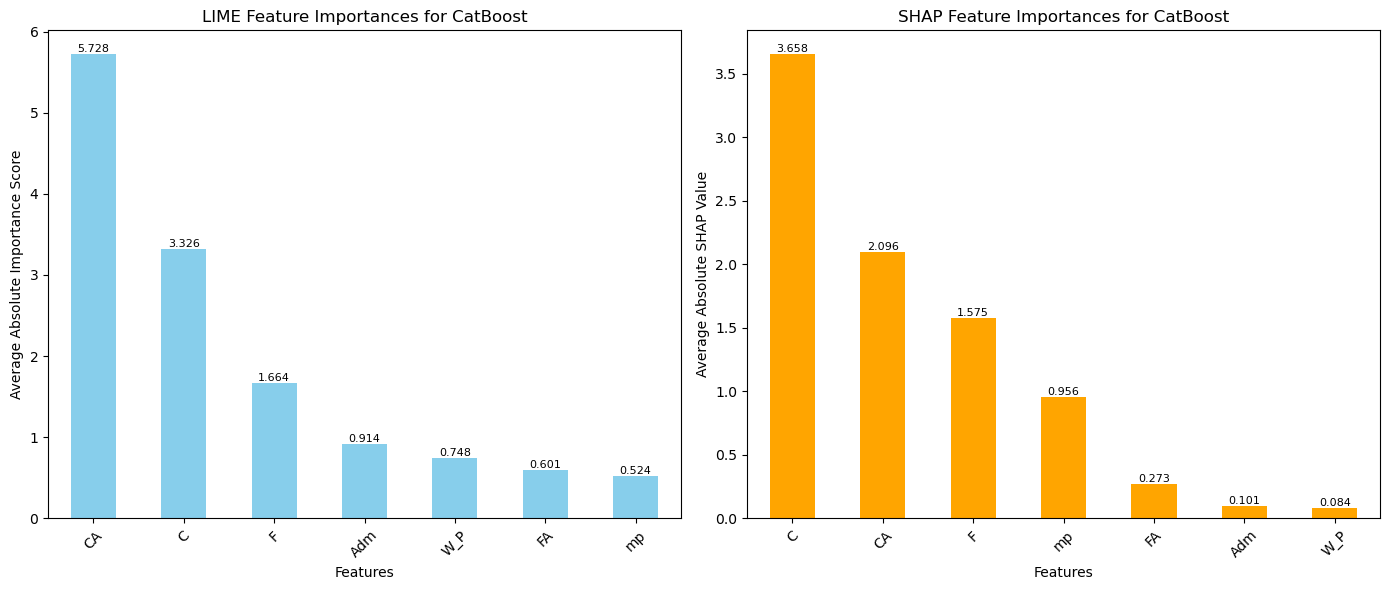

Using 189 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/95 [00:00<?, ?it/s]

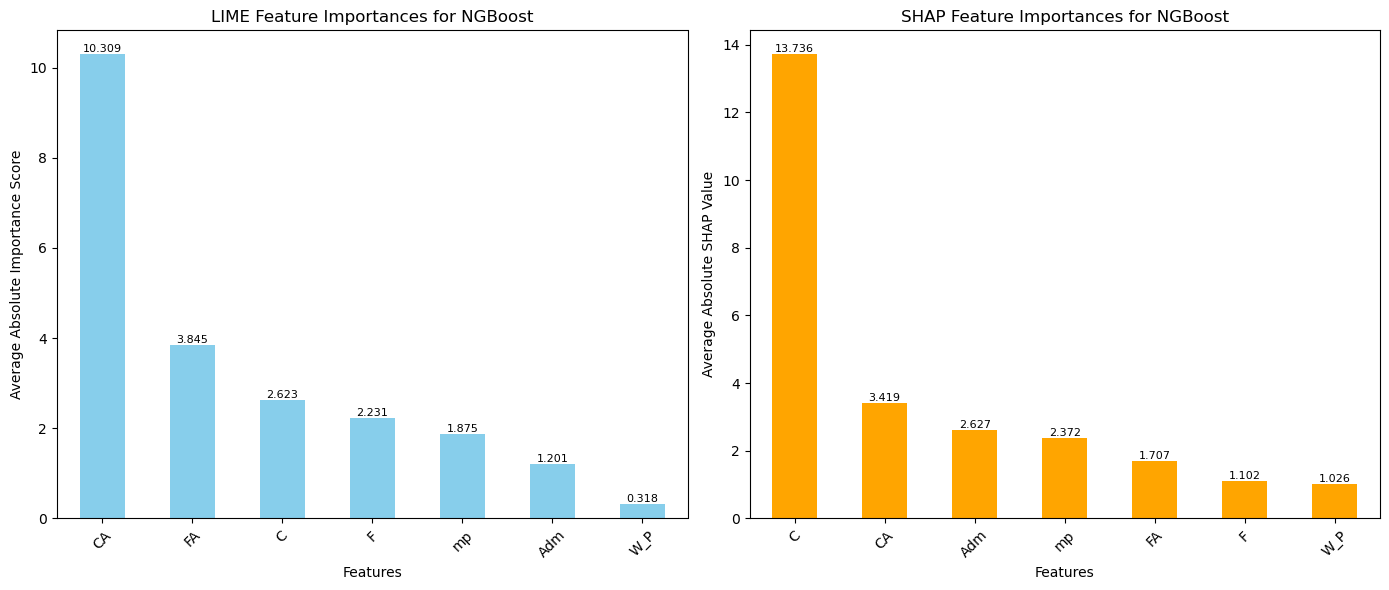

In [48]:
generate_interpretml_explanations_summary(best_scores_halving_grid, X_train, y_train, x_test, feature_names)

# **Best model analysis**

Best Model: LightGBM
Sampler Used: RandomSampler
Best Test MSE: 6.2444
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 400, 'num_leaves': 63, 'min_child_samples': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'verbose': -1}
RMSE: 2.4989
Correlation Coefficient: 0.9682


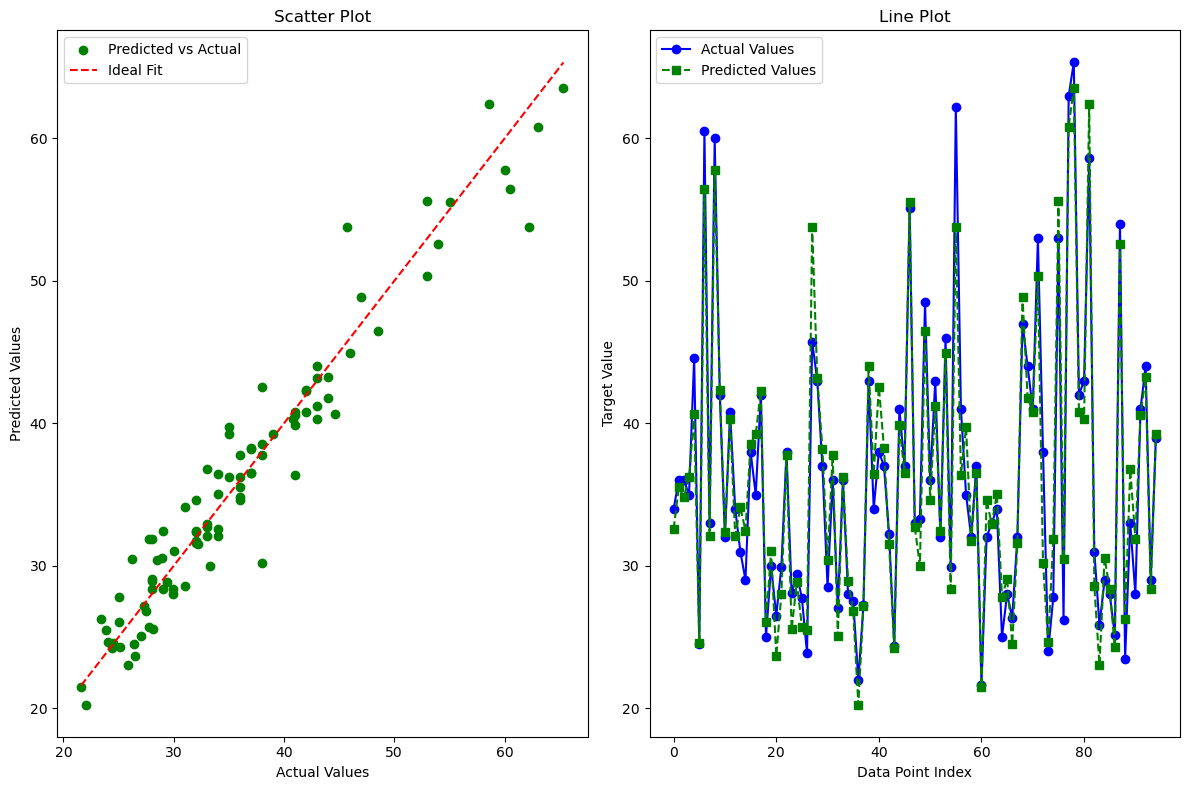

In [49]:
def evaluate_best_model(
    best_scores_basesampler,
    best_scores_grid_sampler,
    best_scores_random_sampler,
    best_scores_tpe_sampler,
    best_scores_cmaes_sampler,
    best_scores_gp_sampler,
    best_scores_partial_fixed_sampler,
    best_scores_brute_force,
    best_scores_nsga_ii_sampler,
    best_scores_nsga_iii_sampler,
    best_scores_qmc_sampler,
    best_scores_halving_grid,
    model_classes,
    X_train,
    y_train,
    X_test,
    y_test,
    csv_file_path):
    """
    Evaluates the best model among the given models with and without pruner,
    fits it on the training data, predicts on test data, and plots actual vs. predicted values.
    Also appends the predicted values to a CSV file as a new column.

    Parameters:
    - best_scores_*: Dictionaries containing performance metrics and best_params.
                     Some may include pruner information in the keys.
    - model_classes: Dictionary mapping model names to model classes.
    - X_train, y_train: Training data.
    - X_test, y_test: Test data.
    - csv_file_path: Path to the CSV file where predictions will be appended.

    Returns:
    - None
    """

    # Combine dictionaries into lists
    best_scores_with_pruner_list = [
        best_scores_basesampler,
        best_scores_grid_sampler,
        best_scores_random_sampler,
        best_scores_tpe_sampler,
        best_scores_cmaes_sampler,
        best_scores_gp_sampler,
        best_scores_partial_fixed_sampler,
        best_scores_brute_force,
    ]
    best_scores_without_pruner_list = [
        best_scores_nsga_ii_sampler,
        best_scores_nsga_iii_sampler,
        best_scores_qmc_sampler,
        best_scores_halving_grid
    ]

    # Combine all entries into a list
    combined_scores = []

    # Extract entries from dictionaries with pruner information
    for sampler_name, best_scores_dict in zip(
        ['BaseSampler', 'GridSampler', 'RandomSampler', 'TPESampler', 'CMAESSampler', 'GPSampler', 'PartialFixedSampler', 'BruteForce'],
        best_scores_with_pruner_list):
        for key, value in best_scores_dict.items():
            model_name = key[0] if isinstance(key, tuple) else key
            mse = value['test_mse']
            combined_scores.append({
                'model_name': model_name,
                'sampler_name': sampler_name,
                'test_mse': mse,
                'best_params': value['best_params']
            })

    # Extract entries from dictionaries without pruner information
    for sampler_name, best_scores_dict in zip(
        ['NSGAIISampler', 'NSGAIIISampler', 'QMCSampler', 'HalvingGrid'],
        best_scores_without_pruner_list):
        for key, value in best_scores_dict.items():
            model_name = key[0] if isinstance(key, tuple) else key
            mse = value['test_mse']
            combined_scores.append({
                'model_name': model_name,
                'sampler_name': sampler_name,
                'test_mse': mse,
                'best_params': value['best_params']
            })

    # Find the entry with the lowest test MSE
    best_entry = min(combined_scores, key=lambda x: x['test_mse'])

    best_model_name = best_entry['model_name']
    best_sampler_name = best_entry['sampler_name']
    best_params = best_entry['best_params']

    print(f"Best Model: {best_model_name}")
    print(f"Sampler Used: {best_sampler_name}")
    print(f"Best Test MSE: {best_entry['test_mse']:.4f}")
    print(f"Best Parameters: {best_params}")

    # Get the model class
    model_class = model_classes.get(best_model_name)

    if model_class is None:
        print(f"Model class for {best_model_name} not found in model_classes dictionary.")
        return

    # Instantiate and fit the model with best parameters
    model = model_class(**best_params)
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Round the predicted values to 2 decimal places
    y_pred_rounded = np.round(y_pred, 2)

    # Calculate RMSE and correlation coefficient
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    correlation_coefficient = np.corrcoef(y_test, y_pred)[0, 1]

    print(f"RMSE: {rmse:.4f}")
    print(f"Correlation Coefficient: {correlation_coefficient:.4f}")

    # Plot actual vs. predicted values
    plt.figure(figsize=(12, 8))

    # Scatter plot of actual vs. predicted values
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred_rounded, color='green', label='Predicted vs Actual')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Scatter Plot')
    plt.legend()

    # Line plot of actual and predicted values
    plt.subplot(1, 2, 2)
    plt.plot(range(len(y_test)), y_test, marker='o', linestyle='-', color='blue', label='Actual Values')
    plt.plot(range(len(y_pred_rounded)), y_pred_rounded, marker='s', linestyle='--', color='green', label='Predicted Values')
    plt.xlabel('Data Point Index')
    plt.ylabel('Target Value')
    plt.title('Line Plot')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Load the existing CSV file
    df = pd.read_csv(csv_file_path)

    # Add the rounded predicted values as a new column
    df['Predicted_Values'] = y_pred_rounded

    # Save the updated DataFrame back to the CSV file
    df.to_csv(csv_file_path, index=False)



file = r"C:\Users\Danesh\Desktop\Concrete\test_best.csv"
# Call the function with your dictionaries and data
evaluate_best_model(
    best_scores_basesampler,
    best_scores_grid_sampler,
    best_scores_random_sampler,
    best_scores_tpe_sampler,
    best_scores_cmaes_sampler,
    best_scores_gp_sampler,
    best_scores_partial_fixed_sampler,
    best_scores_brute_force,
    best_scores_nsga_ii_sampler,
    best_scores_nsga_iii_sampler,
    best_scores_qmc_sampler,
    best_scores_halving_grid,
    model_classes,
    X_train,
    y_train,
    X_test,
    y_test,
    file  
)

In [50]:
file_paths_dict = {
    'Random Forest': r"C:\Users\Danesh\Desktop\Concrete\test_randomforest.csv",
    'Gradient Boosting': r"C:\Users\Danesh\Desktop\Concrete\test_gradientboosting.csv",
    'XGBoost': r"C:\Users\Danesh\Desktop\Concrete\test_xgboost.csv",
    'LightGBM': r"C:\Users\Danesh\Desktop\Concrete\test_lightgbm.csv",
    'GPBoost': r"C:\Users\Danesh\Desktop\Concrete\test_gpboost.csv",
    'CatBoost': r"C:\Users\Danesh\Desktop\Concrete\test_catboost.csv",
    'NGBoost': r"C:\Users\Danesh\Desktop\Concrete\test_ngboost.csv"
}

In [51]:
def evaluate_all_models(
    best_scores_basesampler,
    best_scores_grid_sampler,
    best_scores_random_sampler,
    best_scores_tpe_sampler,
    best_scores_cmaes_sampler,
    best_scores_gp_sampler,
    best_scores_partial_fixed_sampler,
    best_scores_brute_force,
    best_scores_nsga_ii_sampler,
    best_scores_nsga_iii_sampler,
    best_scores_qmc_sampler,
    best_scores_halving_grid,
    model_classes,
    X_train,
    y_train,
    X_test,
    y_test,
    file_paths_dict):
    """
    Evaluates all models across different hyperparameter tuning methods,
    fits them on the training data, predicts on test data, and saves the predicted values
    into separate files for each algorithm.

    Parameters:
    - best_scores_*: Dictionaries containing performance metrics and best_params.
    - model_classes: Dictionary mapping model names to model classes.
    - X_train, y_train: Training data.
    - X_test, y_test: Test data.
    - file_paths_dict: Dictionary mapping algorithm names to their respective CSV file paths.

    Returns:
    - None
    """
    import numpy as np
    import pandas as pd
    from sklearn.metrics import mean_squared_error
    from sklearn.exceptions import NotFittedError

    # Combines all best_scores dictionaries into a list
    best_scores_list = [
        ('BaseSampler', best_scores_basesampler),
        ('GridSampler', best_scores_grid_sampler),
        ('RandomSampler', best_scores_random_sampler),
        ('TPESampler', best_scores_tpe_sampler),
        ('CMAESSampler', best_scores_cmaes_sampler),
        ('GPSampler', best_scores_gp_sampler),
        ('PartialFixedSampler', best_scores_partial_fixed_sampler),
        ('BruteForce', best_scores_brute_force),
        ('NSGAIISampler', best_scores_nsga_ii_sampler),
        ('NSGAIIISampler', best_scores_nsga_iii_sampler),
        ('QMCSampler', best_scores_qmc_sampler),
        ('HalvingGrid', best_scores_halving_grid)
    ]

    # Get the list of all algorithms
    algorithms = list(model_classes.keys())

    # Initialize a dictionary to store predictions for each algorithm
    predictions_dict = {algo: {} for algo in algorithms}

    # Iterate over each tuning method and its best_scores dictionary
    for sampler_name, best_scores in best_scores_list:
        # Iterate over each algorithm in the best_scores dictionary
        for key in best_scores.keys():
            model_name = key[0] if isinstance(key, tuple) else key

            # Skip if the model class is not available
            if model_name not in model_classes:
                continue

            # Get the best parameters for the current model and tuning method
            best_params = best_scores[key]['best_params']

            # Instantiate the model with best parameters
            model_class = model_classes[model_name]
            try:
                model = model_class(**best_params)
            except TypeError as e:
                print(f"Error instantiating {model_name} with params {best_params}: {e}")
                continue

            # Fit the model
            try:
                model.fit(X_train, y_train)
            except Exception as e:
                print(f"Error fitting {model_name}: {e}")
                continue

            # Predict on test data
            try:
                y_pred = model.predict(X_test)
            except NotFittedError as e:
                print(f"Model {model_name} is not fitted: {e}")
                continue
            except Exception as e:
                print(f"Error predicting with {model_name}: {e}")
                continue

            # Round the predicted values to 2 decimal places
            y_pred_rounded = np.round(y_pred, 2)

            # Store the predictions
            predictions_dict[model_name][sampler_name] = y_pred_rounded

    # For each algorithm, create or update the corresponding CSV file
    for algo_name in algorithms:
        # Get the file path for the algorithm
        csv_file_path = file_paths_dict.get(algo_name)
        if not csv_file_path:
            print(f"No file path provided for algorithm {algo_name}. Skipping.")
            continue

        # Initialize a DataFrame with actual y_test values if the file doesn't exist
        try:
            df = pd.read_csv(csv_file_path)
            if 'Actual_Values' not in df.columns:
                df['Actual_Values'] = y_test
        except FileNotFoundError:
            # File doesn't exist, create a new DataFrame
            df = pd.DataFrame({'Actual_Values': y_test})

        # Add the predictions to the DataFrame
        if algo_name in predictions_dict:
            for sampler_name, y_pred in predictions_dict[algo_name].items():
                column_name = f"{sampler_name}_Predictions"
                df[column_name] = y_pred
        else:
            print(f"No predictions available for algorithm {algo_name}.")
            continue

        # Save the DataFrame back to the CSV file
        df.to_csv(csv_file_path, index=False)
        print(f"Predictions for {algo_name} saved to {csv_file_path}.")


In [52]:
evaluate_all_models(
    best_scores_basesampler,
    best_scores_grid_sampler,
    best_scores_random_sampler,
    best_scores_tpe_sampler,
    best_scores_cmaes_sampler,
    best_scores_gp_sampler,
    best_scores_partial_fixed_sampler,
    best_scores_brute_force,
    best_scores_nsga_ii_sampler,
    best_scores_nsga_iii_sampler,
    best_scores_qmc_sampler,
    best_scores_halving_grid,
    model_classes,
    X_train,
    y_train,
    X_test,
    y_test,
    file_paths_dict
)

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=1.0. Current value: lambda_l2=1.0
[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.1. Current value: lambda_l2=0.1
[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=1.0. Current value: lambda_l2=1.0
[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.5. Current value: lambda_l2=0.5
[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.1. Current value: lambda_l2=0.1
[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.1. Current value: lambda_l2=0.1
[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.1. Current value: lambda_l2=0.1
[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.5. Current value: lambda_l2=0.5
[GPBoost] [Warning] lambda_l2 is